# Анализ пользовательского поведения на e-commerce платформе

## Цель проекта

На основе событий пользователей интернет-магазина провести исследовательский анализ данных, а также анализ ключевых продуктовых метрик с целью выявления точек роста продукта.

## Задачи проекта

* Провести аудит качества данных и предобработку датасета
* Исследовать структуру пользовательских событий
* Рассчитать ключевые продуктовые метрики
* Построить воронку пользовательского пути
* Выполнить когортный анализ и анализ удержания пользователей
* Создать дашборд для визуализации результатов
* Подготовка бизнес-рекомендаций

## Описание данных

Датасет содержит события пользователей интернет-магазина за период с сентября 2020 по февраль 2021 года.

Каждая строка представляет отдельное действие пользователя на платформе.

Описание столбцов датасета:
* `event_time` - дата и время события
* `event_type` - тип события (просмотр товара, добавление в корзину, покупка)
* `product_id` - идентификатор товара
* `category_id` - идентификатор категории
* `category_code` - название категории
* `brand` - бренд товара
* `price` - цена товара
* `user_id` - идентификатор пользователя
* `user_session` - идентификатор пользовательской сессии

## Содержание проекта

### 1. Знакомство с данными и предобработка *(Python)*

- Загрузка данных
- Анализ структуры датасета
- Поиск пропусков и дубликатов
- Обработка аномалий и выбросов
- Подготовка данных к анализу <br><br>


### 2. Исследовательский анализ данных *(Python)*

#### 2.1 Анализ событий пользователей
#### 2.2 Анализ товаров и категорий
#### 2.3 Анализ пользовательской активности <br><br>


### 3. Анализ ключевых продуктовых метрик *(SQL + Python)*

#### 3.1 Анализ активности аудитории
- DAU / WAU / MAU
- Stickiness

#### 3.2 Анализ продуктовой воронки
- Общий анализ воронки
- Анализ потерь пользователей

#### 3.3 Анализ монетизации продукта и когортный анализ
- Revenue
- ARPU / ARPPU
- AOV
- LTV
- Retention Rate <br><br>


### 4. Итоговые выводы и бизнес-рекомендации

#### 4.1 Ключевые закономерности
#### 4.2 Продуктовые гипотезы
#### 4.3 Рекомендации для бизнеса
#### 4.4 Ограничения исследования <br><br>

## 1. Знакомство с данными и предобработка

In [1]:
# Импортируем библиотеки для анализа данных
import pandas as pd
import numpy as np
import missingno as msno

# Импортируем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Импортируем функции для поиска часто встречающихся комбинаций объектов
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
# Выгружаем датасет, создаем объект датафрейма
df = pd.read_csv('data/raw/events.csv')

In [3]:
# Проверим результат, выведем первые 5 строк
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [4]:
# Выведем основную техническую информациию по датафрейму
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  str    
 1   event_type     885129 non-null  str    
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  str    
 5   brand          672765 non-null  str    
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 60.8 MB


Изменим тип данных для следующих столбцов: 
* `event_time` - характеризует дату и время события, наиболее корректный тип данных будет `datetime64`
* `product_id`, `category_id`, `user_id` - это идентификаторы объектов, поэтому числовой тип не отражает их природу, изменим на `str`

In [5]:
# Преобразуем столбец event_time
df['event_time'] = pd.to_datetime(df['event_time'])

df['event_time'] = df['event_time'].dt.tz_localize(None)

# Проверим результат
df['event_time'].dtypes

dtype('<M8[us]')

In [6]:
# Преобразуем столбцы product_id, category_id и user_id
for x in ['product_id', 'category_id', 'user_id']:
    df[x] = df[x].astype('str')

# Проверим результат
df[['product_id', 'category_id', 'user_id']].dtypes

product_id     str
category_id    str
user_id        str
dtype: object

In [7]:
# Создадим датафрейм для анлиза ценового сегмента товаров
products = df[['product_id', 'price', 'category_code', 'brand']].drop_duplicates().reset_index(drop=True)

In [8]:
# Выведем краткую статистическую сводку по столбцу price
products[['price']].describe(percentiles=[0.5, 0.95, 0.99, 0.995, 0.999])

,price
count,53453.000000
mean,105.346161
std,516.781715
min,0.220000
50%,29.680000
95%,382.228000
99%,1139.131600
99.5%,1780.774800
99.9%,4211.280840
max,64771.060000


In [9]:
# Сохраним порог 99.9 перцентиля
p999 = products['price'].quantile(0.999)
print(f'99.9-й перцентиль: {p999:.2f}')

99.9-й перцентиль: 4211.28


In [10]:
# Посмотрим на кол-во товаров
print(f'Количество товаров выше 99.9-го перцентиля: {len(products[products['price'] > p999])}')

Количество товаров выше 99.9-го перцентиля: 54


In [11]:
# Выведем их характеристики
products[products['price'] > p999].sort_values('price', ascending=False)[['product_id', 'category_code', 'brand', 'price']]

,product_id,category_code,brand,price
14691,4170916,computers.peripherals.monitor,lg,64771.06
37274,4078837,electronics.video.tv,samsung,42590.13
5836,4078834,electronics.video.tv,samsung,27775.87
35384,3830190,NaN,dell,26985.35
16752,4101181,computers.peripherals.printer,NaN,26909.62
46974,3830191,NaN,dell,23242.11
41233,3790935,NaN,dell,14233.22
37280,4078835,electronics.video.tv,lg,13627.02
35881,1633600,computers.peripherals.monitor,philips,12601.57
5531,875455,electronics.video.tv,lg,12559.95


In [12]:
# Выведем самую дорогую покупку
big = df[df['event_type'] == 'purchase'].nlargest(1, 'price')['price'].iloc[0]
print(f'Самая дорогая покупка {big}')

# Выведем самую дешевую покупку
small = df[df['event_type'] == 'purchase'].nsmallest(1, 'price')['price'].iloc[0]
print(f'Самая дешевая покупка {small}')

Самая дорогая покупка 3717.65
Самая дешевая покупка 0.22


**Анализ распределения цен уникальных товаров показал наличие выраженной правосторонней асимметрии**: большая часть ассортимента сосредоточена в низком и среднем ценовом диапазоне, при этом небольшая группа товаров имеет существенно более высокую стоимость. Максимальная цена товара составляет 64 771.06, тогда как 99.9-й перцентиль равен 4 211.28, а выше данного порога находится всего 54 уникальных товара.

**Однозначно оценить корректность экстремально высоких цен невозможно, поскольку в описании датасета отсутствует информация об используемой валюте.** Косвенно можно предположить, что цены представлены в долларах США или условных денежных единицах, близких к доллару, поскольку в данных присутствуют товары стоимостью 0.22, по которым были зафиксированы реальные покупки.

Дополнительный анализ показал, что наиболее дорогие товары относятся к категориям мониторов, телевизоров, принтеров и другой электроники известных брендов. При этом товары стоимостью выше ~ 3 700 не участвуют в покупательском пути: для них отсутствуют покупки. Самая дорогая совершённая покупка в датасете имеет стоимость 3 717.65, то есть значительно ниже рассматриваемых экстремальных значений.

**На текущем этапе данные значения классифицированы как выбросы (`outliers`), а не как аномалии (`data errors`).** Несмотря на существенное отличие от основной массы товаров, прямые доказательства ошибочности этих наблюдений отсутствуют. Кроме того, отсутствие покупок по наиболее дорогим товарам означает, что их сохранение не окажет существенного влияния на дальнейший расчёт продуктовых метрик, основанных на покупках (например, выручки, AOV, ARPU и ARPPU).

**В связи с этим принято решение не удалять данные товары из датасета, а учитывать наличие длинного правого хвоста распределения цен при дальнейшем анализе.**

In [13]:
# Выведем краткую статистическую сводку для строковых столбцов
df.describe(include='str')

,event_type,product_id,category_id,category_code,brand,user_id,user_session
count,885129,885129,885129,648910,672765,885129,884964
unique,3,53453,718,107,999,407283,490398
top,view,1821813,2144415922427789416,computers.components.videocards,asus,1515915625554995474,nFlhu5QzOd
freq,793748,14563,116717,116717,27706,572,572


In [14]:
# Выведем краткую статистическую сводку для столбца event_time
print(f'Самая ранняя дата {df['event_time'].min()}')
print(f'Самая поздняя дата {df['event_time'].max()}')

Самая ранняя дата 2020-09-24 11:57:06
Самая поздняя дата 2021-02-28 23:59:09


In [15]:
# Уберем данные за 2020-09-24, так как первый день представлен не полностью,
# что может исказить результаты анализа динамики
kick = df[df['event_time'].dt.date == pd.Timestamp('2020-09-24').date()]

print(f'Количество строк, которые мы теряем при фильтрации {len(kick)}')

df = df[df['event_time'] >= '2020-09-25']

Количество строк, которые мы теряем при фильтрации 2265


In [16]:
# Проверим датасет на наличие явных дубликатов
print(f'В датасете присутствует {df.duplicated().sum()} явных дубликата')

В датасете присутствует 653 явных дубликата


In [17]:
# Удалим явные дубликаты
df = df.drop_duplicates().reset_index(drop=True)

# Проверим результат
print(f'В датасете присутствует {df.duplicated().sum()} явных дубликатов')

В датасете присутствует 0 явных дубликатов


Воспользуемся матрицой из библиотеки `missingno` для визуализации распределения пропусков внутри датафрейма.

<Axes: >

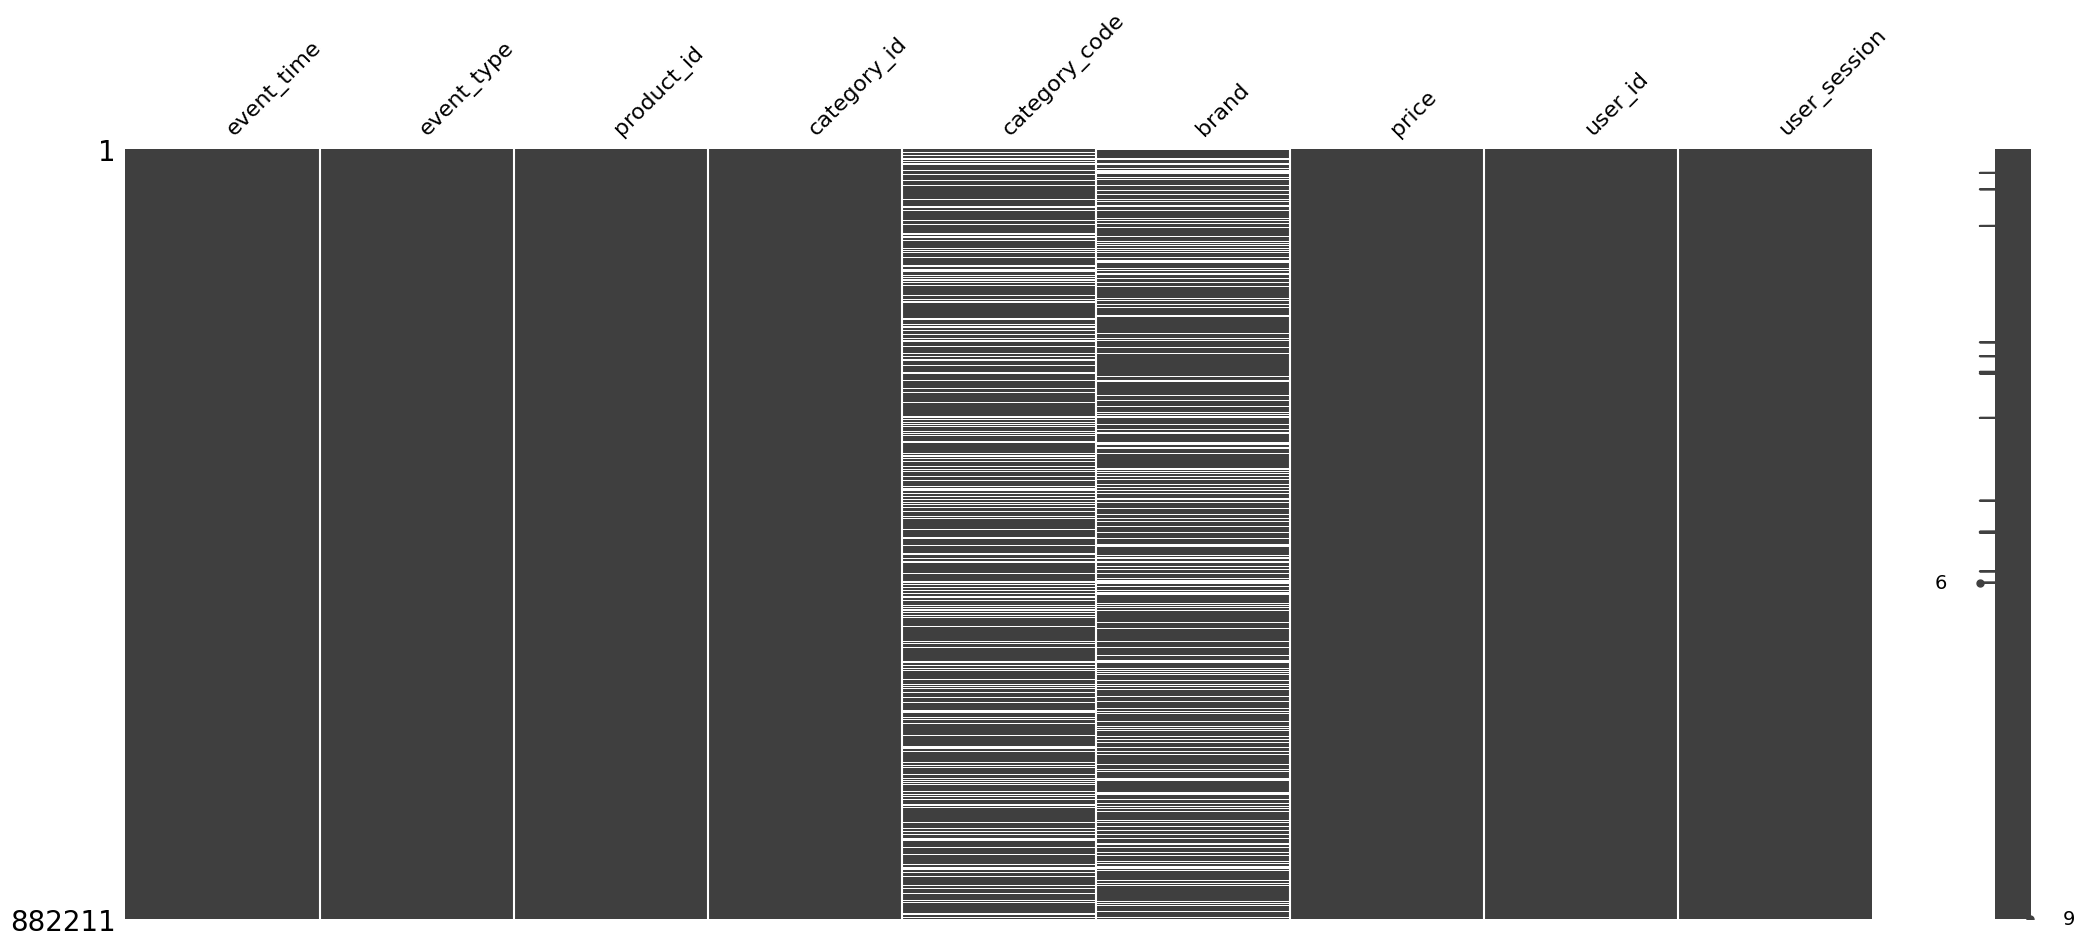

In [18]:
# Проверим как распределены пропуски внутри датафрейма
msno.matrix(df)

Разберем пропуски в столбце `user_session`.

In [19]:
# Посмотрим на строки, где пропущены значения в столбце user_session
df[df['user_session'].isna()].head(30)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
4605,2020-09-26 05:14:39,view,3791351,2144415926966026460,computers.components.cpu,amd,204.29,1515915625519884058,NaN
5631,2020-09-26 10:58:24,view,1785245,2144415925011480748,stationery.cartrige,canon,43.11,1515915625495954428,NaN
9513,2020-09-27 11:59:41,view,1153724,2144415921169498184,NaN,zte,6.29,1515915625520228004,NaN
22186,2020-09-30 07:31:01,view,1559260,2144415928845074703,computers.notebook,NaN,16.83,1515915625397674009,NaN
26153,2020-10-01 04:39:58,view,1423208,2144415922285183076,electronics.camera.video,panasonic,540.14,1515915625471620229,NaN
27408,2020-10-01 09:41:32,view,790766,2144415927158964449,NaN,NaN,11.52,1515915625521402590,NaN
30380,2020-10-01 22:17:58,view,261923,2144415922939494519,NaN,panasonic,37.75,1515915625521601509,NaN
34000,2020-10-02 17:44:26,view,933650,2144415922092245087,computers.peripherals.joystick,logitech,283.44,1515915625499550350,NaN
46164,2020-10-05 13:45:35,view,790766,2144415927158964449,NaN,NaN,11.52,1515915625521402590,NaN
51626,2020-10-06 16:20:20,view,4183797,2144415939364389423,electronics.clocks,amazfit,150.41,1515915625522968202,NaN


Пропуски распределены единично, не образуют закономерностей и наиболее вероятно связаны с техническими особенностями сбора данных.

In [20]:
# Посчитаем процент пропусков в столбце user_session
print(f'{df['user_session'].isna().sum() / len(df) * 100:.2f} % составляют пропуски в столбце user_session относительного общего объема данных.')

0.02 % составляют пропуски в столбце user_session относительного общего объема данных.


Поскольку их количество пренебрежимо мало, а также тип пропусков наиболее похож на MCAR (Missing Completely At Random) удалим эти строки.

In [21]:
# Удаляем пропуски
df = df.dropna(subset=['user_session']).reset_index(drop=True)

# Проверяем результат
print(f'{df['user_session'].isna().sum()} пропущенных значений в столбце user_session')

0 пропущенных значений в столбце user_session


Разберем пропуски в столбцах `category_code` и `brand`.

In [22]:
# Проверим уникальность для каждого идентификатор товара
df.groupby('product_id').agg({
    'brand': 'nunique',
    'category_code': 'nunique',
    'category_id': 'nunique',
    'price': 'nunique'
}).sort_values(['brand', 'category_code', 'category_id', 'price'], ascending=False)

,brand,category_code,category_id,price
product_id,,,,
1000108,1,1,1,1
1000111,1,1,1,1
1000112,1,1,1,1
1000113,1,1,1,1
1000116,1,1,1,1
...,...,...,...,...
955713,0,0,1,1
955714,0,0,1,1
955715,0,0,1,1


Проверка показала, что каждому `product_id` соответствует только одно значение бренда, категории и цены. Это означает, что столбец `product_id` действительно является уникальным идентификатором товара, а его характеристики остаются неизменными во всех событиях датасета.

In [23]:
# Проверим распределение пропусков в столбце category_code по типу события
(df.assign(category_code_missing = df['category_code'].isna())
      .groupby('event_type')['category_code_missing']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={
          'sum': 'missing',
          'count': 'total',
          'mean': 'share_missing'
      }))

,missing,total,share_missing
event_type,,,
cart,10387,53927,0.192612
purchase,7550,37259,0.202636
view,217360,790864,0.274839


In [24]:
# Проверим распределение пропусков в столбце brand по типу события
(df.assign(brand_missing = df['brand'].isna())
      .groupby('event_type')['brand_missing']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={
          'sum': 'missing',
          'count': 'total',
          'mean': 'share_missing'
      }))

,missing,total,share_missing
event_type,,,
cart,12503,53927,0.231850
purchase,9483,37259,0.254516
view,189674,790864,0.239831


Доля пропусков в столбцах `category_code` и `brand` сопоставима для всех типов событий. Существенного смещения в сторону просмотров, добавлений в корзину или покупок не наблюдается, что свидетельствует об отсутствии явной зависимости пропусков от типа события.

In [25]:
# Создадим новый столбец event_date с датой события
df['event_date'] = df['event_time'].dt.date

<Axes: title={'center': 'Доля пропусков category_code по дням'}, xlabel='event_date'>

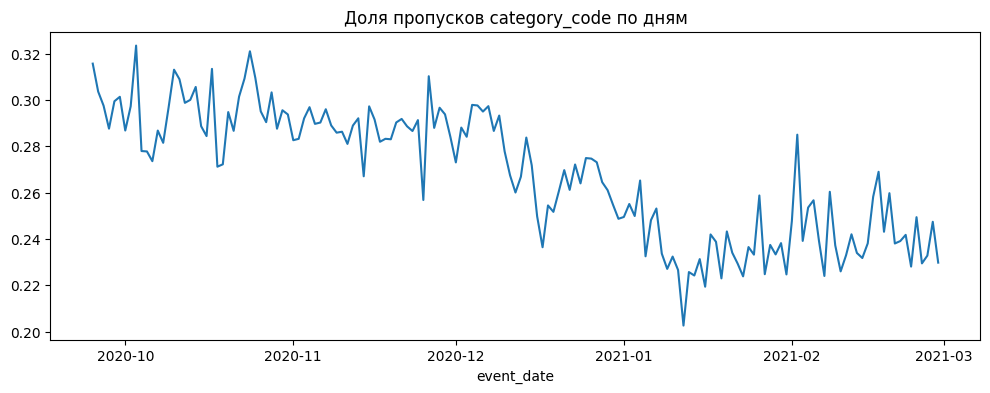

In [26]:
# Проверим распределение пропусков в столбце category_code во времени
(df.assign(category_code_missing = df['category_code'].isna())
      .groupby('event_date')['category_code_missing']
      .mean()
      .plot(figsize=(12,4), title='Доля пропусков category_code по дням'))

<Axes: title={'center': 'Доля пропусков brand по дням'}, xlabel='event_date'>

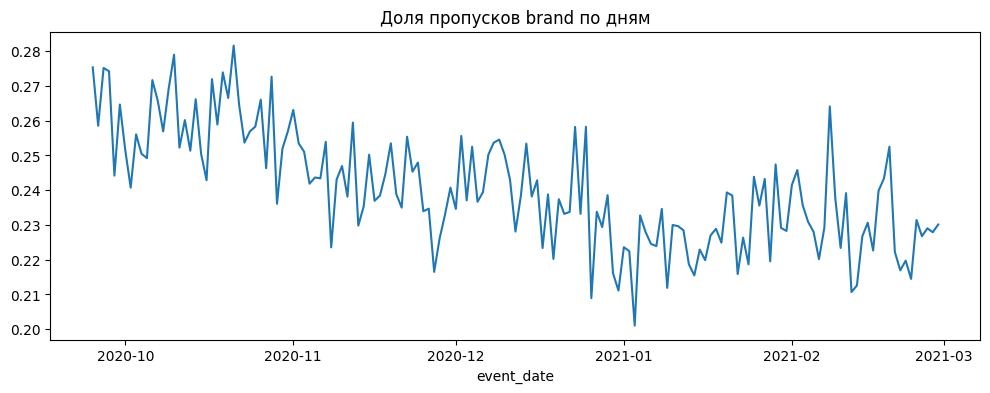

In [27]:
# Проверим распределение пропусков в столбце brand во времени
(df.assign(brand_missing = df['brand'].isna())
      .groupby('event_date')['brand_missing']
      .mean()
      .plot(figsize=(12,4), title='Доля пропусков brand по дням'))

In [28]:
# Удалим столбец с датой
df = df.drop(columns=['event_date'])

Доля пропусков в столбцах `brand` и `category_code` остается относительно стабильной на протяжении всего периода наблюдений. Выраженной зависимости от конкретных дат не наблюдается.

Проверим отдельно для `brand` и `category_code`, встречаются ли товары, у которых в одних событиях значение признака заполнено, а в других отсутствует.

In [29]:
# Проверяем brand
df.groupby('product_id')['brand'].agg(['size', 'count']).query('count > 0 and count < size')

,size,count
product_id,,


In [30]:
# Проверяем category_code
df.groupby('product_id')['category_code'].agg(['size', 'count']).query('count > 0 and count < size')

,size,count
product_id,,


Пропуски были выявлены в трех столбцах: `user_session`, `brand` и `category_code`.

* `user_session`

**Доля пропусков составляет около 0.02% от общего числа наблюдений.** Пропуски распределены единично, не образуют закономерностей и наиболее вероятно связаны с техническими особенностями сбора данных. Такие пропуски **можно отнести к типу MCAR**. Поскольку их количество пренебрежимо мало, было принято решение удалить соответствующие строки.

* `brand` и `category_code`

Для определения природы пропусков была проведена серия проверок.

Проверено распределение пропусков по типу события (`event_type`) — существенных различий не обнаружено.  
Проверено распределение пропусков во времени — всплесков или периодов концентрации пропусков не выявлено.  
Проверено, что для каждого товара (`product_id`) значения `brand` и `category_code` либо заполнены во всех событиях, либо отсутствуют во всех сразу. Товаров с частично заполненными значениями обнаружено не было.

**Таким образом, пропуски являются систематическим свойством конкретных товаров, а не отдельных событий.**

По имеющимся данным невозможно однозначно определить, относятся ли они к типу MAR или MNAR. Для этого потребовалась бы дополнительная информация о процессе формирования каталога товаров. Однако можно уверенно утверждать, что эти **пропуски не являются случайными (MCAR)**.

**Поскольку пропуски отражают особенности самих товаров и не могут быть корректно восстановлены по имеющимся данным, было принято решение сохранить их без заполнения, учитывая их наличие при дальнейшей интерпретации результатов анализа.**

In [31]:
# Сохраним предобработанный датасет в новый файл events_clean.csv
df.to_csv('data/processed/events_clean.csv', index=False, date_format='%Y-%m-%d %H:%M:%S')

## Выводы по разделу «Знакомство с данными и предобработка»

* На первом этапе работы был загружен и изучен датасет `events.csv`, содержащий 885 129 записей о действиях пользователей интернет-магазина.

* В ходе предобработки были приведены к корректным типам данных временные признаки и идентификаторы объектов, что обеспечило их корректную дальнейшую обработку и анализ.

* Анализ распределения цен уникальных товаров выявил выраженную правостороннюю асимметрию. Несмотря на наличие небольшого числа товаров с экстремально высокой стоимостью (максимальная цена — 64 771.06), оснований считать их ошибками обнаружено не было. Поскольку такие товары практически не участвуют в покупках, было принято решение сохранить их в датасете, рассматривая как выбросы, а не как аномалии.

* После удаления неполного первого дня наблюдений - 2265 записей (0.25%), временной диапазон данных охватывает период с 25 сентября 2020 года по 28 февраля 2021 года.

* В процессе очистки данных было удалено 653 явных дубликатов (0.07%). Анализ возможных неявных дубликатов не выявил записей, которые можно было бы однозначно признать ошибочными, поэтому дополнительное удаление данных не производилось.

* Исследование пропусков показало, что:

1) пропуски в `user_session` имеют признаки MCAR, поэтому 162 записи (0.02%) были удалены;
2) пропуски в `brand` и `category_code` являются свойством отдельных товаров, а не отдельных событий. Они не могут быть достоверно восстановлены по имеющимся данным и были сохранены без заполнения.


**В результате предобработки объём датасета сократился с 885 129 до 882 047 строк (–0.34%), что свидетельствует о высоком качестве исходных данных. Подготовленный датасет был сохранён в файл `events_clean.csv` и будет использоваться на последующих этапах анализа.** <br><br>

## 2. Исследовательский анализ данных

### 2.1 Анализ событий пользователей

**Распределение типов событий**

In [32]:
# Построим таблицу распределения типов событий
event_counts = df['event_type'].value_counts().reset_index(name='count')

event_counts['share_%'] = (event_counts['count'] / event_counts['count'].sum() * 100).round(2)

event_counts

,event_type,count,share_%
0,view,790864,89.66
1,cart,53927,6.11
2,purchase,37259,4.22


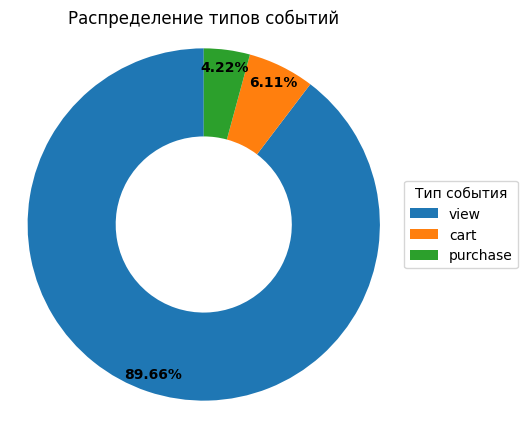

In [33]:
# Визуализируем результат
plt.figure(figsize=(5, 5))

wedges, _, autotexts = plt.pie(
    event_counts['count'],
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.9,
    wedgeprops={'width': 0.5}
)

for text in autotexts:
    text.set_fontweight('bold')
    text.set_fontsize(10)

plt.legend(
    wedges,
    event_counts['event_type'],
    title='Тип события',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.title('Распределение типов событий')
plt.axis('equal')

plt.show()

Основную часть событий в датасете составляют просмотры товаров **(89,66%)**, тогда как добавления в корзину **(6,11%)** и покупки **(4,22%)** встречаются значительно реже. Такое распределение соответствует типичному поведению пользователей в e-commerce, где лишь небольшая часть просмотров приводит к дальнейшим этапам взаимодействия с товаром.

**Общая динамика событий по времени**

In [34]:
# Считаем кол-во событий по дням
daily_events = df.groupby(df['event_time'].dt.floor('D')).size()

In [35]:
# Выведем краткую статистическую информацию
daily_events.describe().round(2)

count     157.00
mean     5618.15
std       956.74
min      2610.00
25%      4928.00
50%      5656.00
75%      6303.00
max      8023.00
dtype: float64

In [36]:
# Выведем топ-5 дней с наибольшим количеством событий
top_days = daily_events.sort_values(ascending=False).reset_index(name='count')

top_days = top_days.head()

top_days

,event_time,count
0,2020-11-18,8023
1,2020-11-11,7794
2,2020-11-17,7570
3,2020-11-16,7492
4,2020-11-09,7249


In [37]:
# Выведем топ-5 дней с наименьшим количеством событий
bottom_days = daily_events.sort_values().reset_index(name='count')

bottom_days = bottom_days.head()

bottom_days

,event_time,count
0,2020-12-31,2610
1,2020-12-06,3187
2,2020-09-26,3462
3,2021-01-01,3596
4,2020-10-10,3610


In [38]:
# Построим таблицу событий по дням
daily_events = df.groupby(df['event_time'].dt.floor('D')).size().reset_index(name='count')

daily_events.columns = ['date', 'count']

daily_events.head()

,date,count
0,2020-09-25,4239
1,2020-09-26,3462
2,2020-09-27,3849
3,2020-09-28,4712
4,2020-09-29,4980


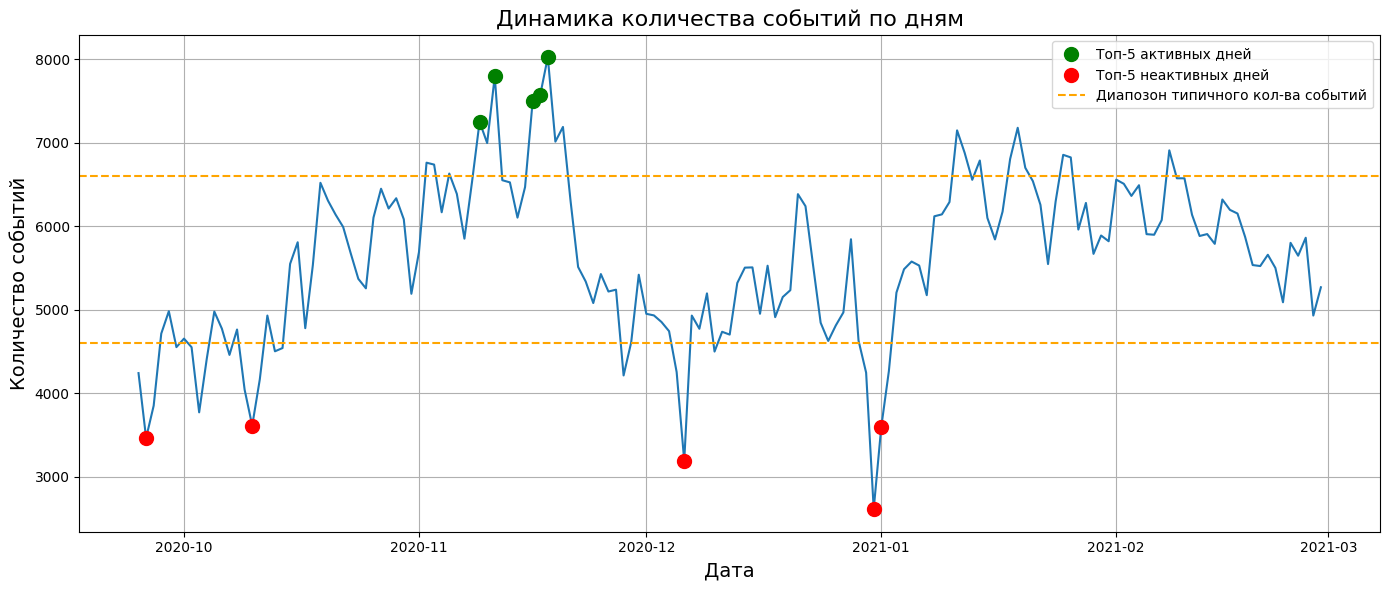

In [39]:
# Визуализируем результат
plt.figure(figsize=(14,6))

plt.plot(daily_events['date'], daily_events['count'])

plt.title('Динамика количества событий по дням', fontsize=16)
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Количество событий', fontsize=14)

plt.scatter(top_days['event_time'], top_days['count'], color='green', s=100, zorder=5, label='Топ-5 активных дней')
plt.scatter(bottom_days['event_time'], bottom_days['count'], color='red', s=100, zorder=5, label='Топ-5 неактивных дней')

plt.axhline(y=4600, color='orange', linestyle='--', linewidth=1.5, label='Диапозон типичного кол-ва событий')
plt.axhline(y=6600, color='orange', linestyle='--', linewidth=1.5)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

* Для исследуемого периода типичный уровень ежедневной активности составляет около 4,6–6,6 тыс. событий. Дни, выходящие за пределы этого диапазона, можно рассматривать как периоды аномально высокой или низкой активности, требующие дополнительного анализа.

* С середины октября до середины ноября наблюдается устойчивый рост общего числа событий. При этом с середины октября до начала ноября происходит восстановление активности до типичного уровня после периода аномально низких значений, а в первой половине ноября рост продолжается и достигает максимальных значений за весь исследуемый период. Определить причины такой динамики по имеющимся данным невозможно, поскольку датасет не содержит информации о маркетинговых кампаниях, сезонных акциях и других внешних факторах, способных повлиять на поведение пользователей.

* Минимальное количество событий наблюдается 31 декабря и 1 января, что, вероятно, связано с новогодними праздниками и временным снижением интенсивности взаимодействия пользователей с интернет-магазином.

**Соотношение событий по времени**

In [40]:
# Построим таблицу соотношения событий по времени
events_by_day = df.groupby([df['event_time'].dt.date, 'event_type']).size().unstack(fill_value=0)

events_by_day.head()

event_type,cart,purchase,view
event_time,,,
2020-09-25,240,149,3850
2020-09-26,177,119,3166
2020-09-27,172,110,3567
2020-09-28,259,200,4253
2020-09-29,263,194,4523


In [41]:
# Преобразуем абсолютные значения в доли
events_share = events_by_day.div(events_by_day.sum(axis=1), axis=0) * 100

events_share.head()

event_type,cart,purchase,view
event_time,,,
2020-09-25,5.661713,3.514980,90.823307
2020-09-26,5.112652,3.437319,91.450029
2020-09-27,4.468693,2.857885,92.673422
2020-09-28,5.496604,4.244482,90.258913
2020-09-29,5.281124,3.895582,90.823293


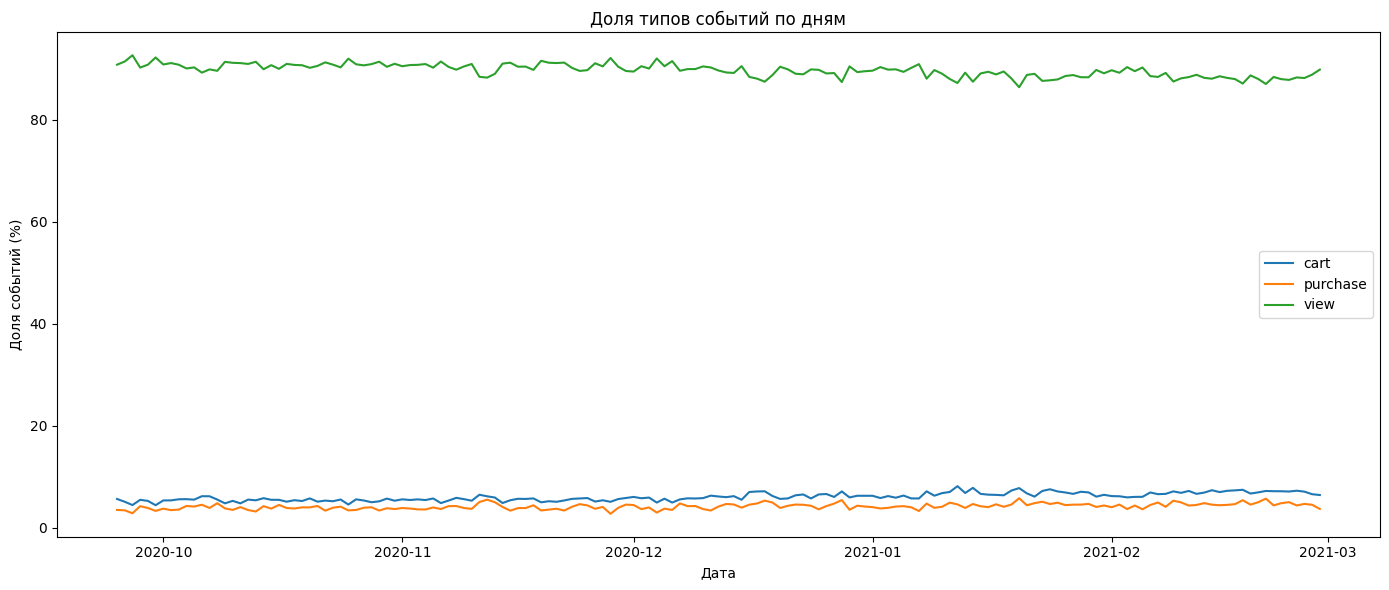

In [42]:
# Визуализируем результат
plt.figure(figsize=(14,6))

for event in events_share.columns:
    plt.plot(events_share.index, events_share[event], label=event)

plt.title('Доля типов событий по дням')
plt.xlabel('Дата')
plt.ylabel('Доля событий (%)')

plt.legend()

plt.tight_layout()
plt.show()

Несмотря на заметные колебания общего количества событий, доли просмотров, добавлений в корзину и покупок на протяжении всего исследуемого периода остаются практически неизменными. Следовательно, изменения общей активности сопровождались пропорциональным изменением количества событий каждого типа, без существенного изменения их соотношения.

### Основные результаты анализа событий пользователей

* За исследуемый период основную часть событий составляют просмотры товаров (89,66%), тогда как добавления в корзину (6,11%) и покупки (4,22%) встречаются значительно реже. При этом, несмотря на колебания общего количества событий в разные периоды, соотношение между типами событий остается практически неизменным, что указывает на стабильное распределение событий между этапами взаимодействия с товарами.

* В течение исследуемого периода наблюдаются как краткосрочные аномалии, так и выраженная временная сезонность. Наиболее заметный рост количества событий приходится на период с середины октября до середины ноября, однако определить его причины по имеющимся данным невозможно из-за отсутствия информации о маркетинговой активности и других внешних факторах. Минимальное количество событий зафиксировано 31 декабря и 1 января, что, вероятно, связано с новогодними праздниками. <br><br>

### 2.2 Анализ товаров и категорий

**Общая характеристика ассортимента**

In [43]:
print(f'Количество уникальных товаров: {df['product_id'].nunique()}')
print(f'Количество уникальных названий категорий: {df['category_code'].nunique()}')
print(f'Количество уникальных брендов: {df['brand'].nunique()}')

Количество уникальных товаров: 53365
Количество уникальных названий категорий: 107
Количество уникальных брендов: 999


**Топ и анти-топ категорий по числу просмотров карточек товара**

In [44]:
# Рассчитаем топ и анти-топ категорий
category_popularity = df.groupby(['category_code', 'event_type']).size().unstack(fill_value=0)

top_category = category_popularity.sort_values(by='view', ascending=False).head(10)
bottom_category = category_popularity.sort_values(by='view').head(10)

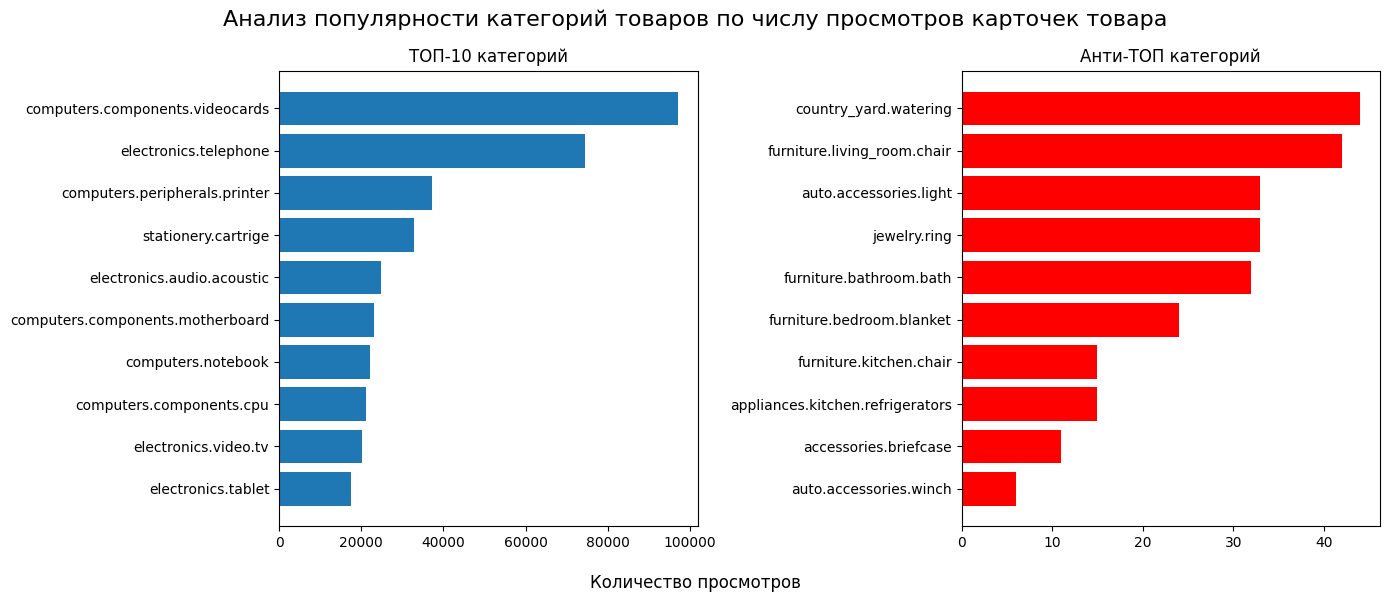

In [45]:
# Визуализируем результат
fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].barh(top_category.index, top_category['view'])
ax[0].invert_yaxis()
ax[0].set_title('ТОП-10 категорий')


ax[1].barh(bottom_category.index, bottom_category['view'], color='red')
ax[1].set_title('Анти-ТОП категорий')

fig.suptitle('Анализ популярности категорий товаров по числу просмотров карточек товара', fontsize=16)
fig.supxlabel('Количество просмотров')

plt.tight_layout()

plt.show()

* Наибольшее количество просмотров приходится на категории `computers.components.videocards` и `electronics.telephone`, которые заметно опережают остальные категории по числу просмотров карточек товаров. После двух лидирующих категорий наблюдается существенное снижение количества просмотров, при этом среди остальных наиболее просматриваемых категорий преобладают товары, связанные с принтерами и расходными материалами.
* Категории с наименьшим количеством просмотров набирают менее 50 событий `view` за весь исследуемый период.

**Категории, не учавствовавшие в покупке**

In [46]:
# Выведем список категорий, которые ниразу не учавстововали в покупке
category_events_all = df.groupby(['category_code', 'event_type']).size().unstack(fill_value=0)

no_purchase_categories = category_events_all.query('purchase == 0')

print(f'Количество категорий без единой покупки: {len(no_purchase_categories)}')

no_purchase_categories

Количество категорий без единой покупки: 15


event_type,cart,purchase,view
category_code,,,
accessories.briefcase,2,0,11
apparel.glove,1,0,116
appliances.environment.fan,1,0,78
appliances.kitchen.refrigerators,0,0,15
appliances.kitchen.steam_cooker,2,0,95
appliances.kitchen.washer,1,0,58
auto.accessories.winch,0,0,6
country_yard.watering,1,0,44
electronics.fax,1,0,503


За исследуемый период для 15 категорий не зафиксировано ни одной покупки. При этом большинство из них характеризуются крайне низким количеством просмотров.

**Топ брендов по числу просмотров карточек товара**

In [47]:
# Рассчитаем топ брендов
brand_popularity = df.groupby(['brand', 'event_type']).size().unstack(fill_value=0)

top_brand = brand_popularity.sort_values(by='view', ascending=False).head(10)

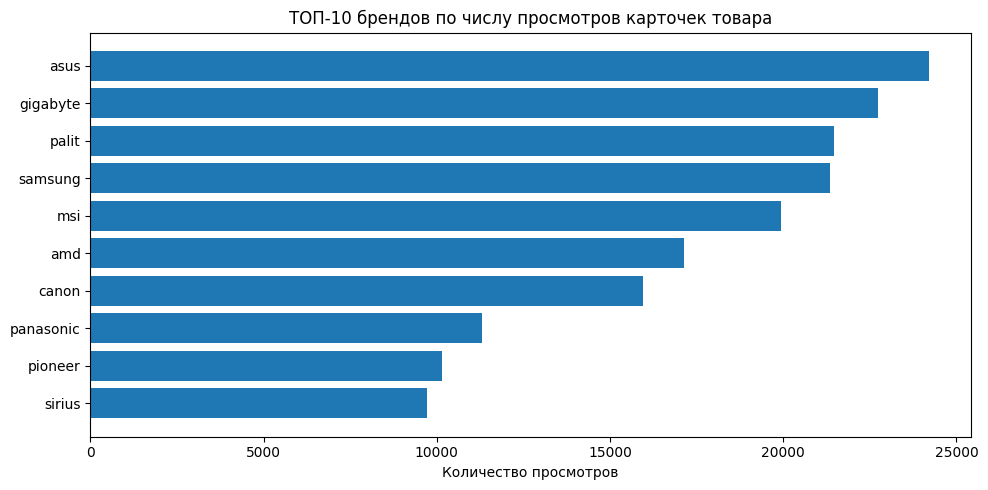

In [48]:
# Визуализируем результат
plt.figure(figsize=(10,5))

plt.barh(top_brand.index, top_brand['view'])

plt.gca().invert_yaxis()

plt.title('ТОП-10 брендов по числу просмотров карточек товара')
plt.xlabel('Количество просмотров')

plt.tight_layout()

plt.show()

По количеству просмотров карточек товаров лидируют бренды `asus`, `gigabyte` и `palit`. При этом распределение просмотров среди брендов-лидеров остается достаточно равномерным: резких разрывов между соседними позициями не наблюдается.

**Бренды не учавствовавшие в покупке**

In [49]:
# Выведем список брендов, которые ниразу не учавстововали в покупке
brand_events_all = df.groupby(['brand', 'event_type']).size().unstack(fill_value=0)

no_purchase_brand = brand_events_all.query('purchase == 0')

print(f'Из 999 брендов, представленных в датасете, {len(no_purchase_brand)} \
({len(no_purchase_brand) / df['brand'].nunique() * 100:.2f}%) не зафиксировали ни одной покупки за исследуемый период.')

Из 999 брендов, представленных в датасете, 528 (52.85%) не зафиксировали ни одной покупки за исследуемый период.


**Распределение товаров по категориям**

In [50]:
# Выведем топ-10 категорий по кол-ву уникальных товаров
products_by_category = df.groupby('category_code')['product_id'].nunique().sort_values(ascending=False).reset_index(name='products')

products_by_category.head(10)

,category_code,products
0,electronics.telephone,6716
1,stationery.cartrige,3087
2,computers.notebook,2347
3,computers.peripherals.printer,2289
4,electronics.audio.acoustic,1557
5,electronics.tablet,1299
6,electronics.audio.headphone,882
7,computers.components.hdd,842
8,computers.desktop,708
9,computers.peripherals.monitor,706


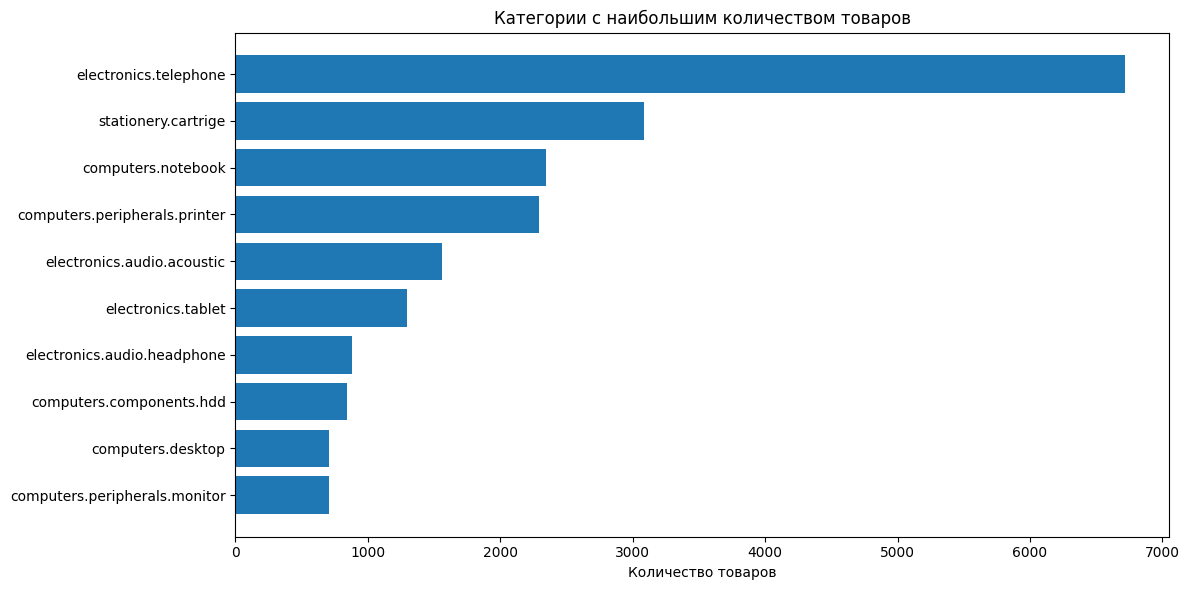

In [51]:
# Визуализируем результат
top_categories_products = products_by_category.head(10)

plt.figure(figsize=(12,6))

plt.barh(top_categories_products['category_code'],top_categories_products['products'])

plt.title('Категории с наибольшим количеством товаров')
plt.xlabel('Количество товаров')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Категория `electronics.telephone` обладает самым широким ассортиментом товаров в магазине и одновременно входит в число лидеров по количеству просмотров. Аналогичная особенность наблюдается для категорий принтеров и картриджей, которые также характеризуются большим количеством товаров и входят в число наиболее просматриваемых категорий.

**Распределение товаров по брендам**

In [52]:
# Выведем топ-10 брендов по кол-ву уникальных товаров
products_by_brand = df.groupby('brand')['product_id'].nunique().sort_values(ascending=False).reset_index(name='products')

products_by_brand.head(10)

,brand,products
0,samsung,971
1,sirius,959
2,smartbuy,795
3,hp,754
4,pitatel,745
5,bosch,694
6,cactus,652
7,cameronsino,592
8,asus,571
9,topon,461


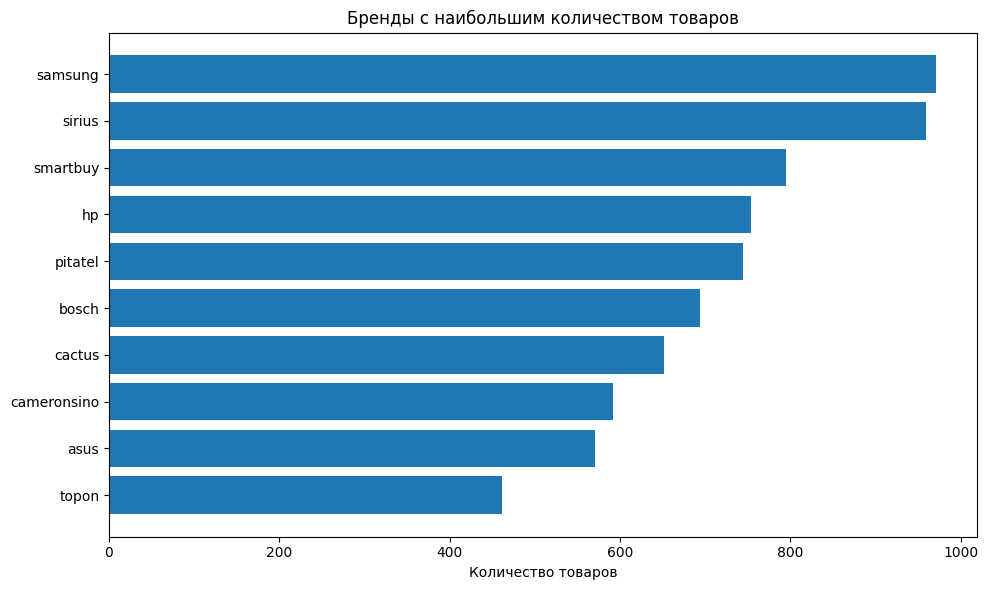

In [53]:
# Визуализируем результат
top_brands_products = products_by_brand.head(10)

plt.figure(figsize=(10,6))

plt.barh(top_brands_products['brand'], top_brands_products['products'])

plt.title('Бренды с наибольшим количеством товаров')
plt.xlabel('Количество товаров')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

* Бренд `asus`, лидировавший по количеству просмотров карточек товаров, занимает лишь 9-е место по размеру ассортимента.
* Наибольшим ассортиментом обладают бренды `samsung` и `sirius`. При этом `samsung` также входит в число наиболее просматриваемых брендов, тогда как `sirius`, несмотря на второй по величине ассортимент, лишь замыкает первую десятку по количеству просмотров.

**Топ категорий 1 уровня по числу просмотров карточек товара**

In [54]:
# Создаем столбец с категорией первого уровня
df['category_lvl_1'] = df['category_code'].str.split('.').str[0]

# Количество событий по категориям
category_event = df.groupby(['category_lvl_1', 'event_type']).size().unstack(fill_value=0)

# Доли событий внутри каждой категории
category_share = category_event.div(category_event.sum(axis=1), axis=0) * 100

# Порядок столбцов
category_share = category_share[['view', 'cart', 'purchase']]

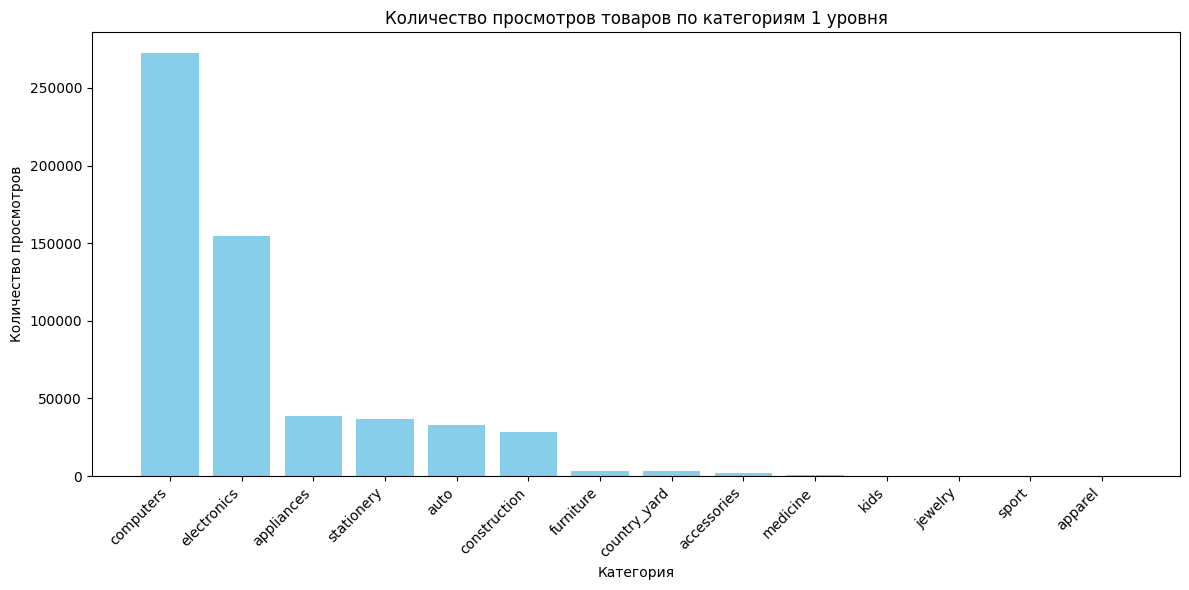

In [55]:
# Построим график для View
view_count = category_event.sort_values('view', ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(view_count.index, view_count['view'], color='skyblue')

plt.title('Количество просмотров товаров по категориям 1 уровня')
plt.xlabel('Категория')
plt.ylabel('Количество просмотров')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

Категория `computers` является безусловным лидером по количеству просмотров, существенно опережая остальные категории первого уровня. Второе место занимает категория `electronics`, тогда как категории `appliances`, `stationery`, `auto` и `construction` формируют вторую группу со схожим количеством просмотров.

In [56]:
# Посмотрим на цифровые значения
view_count = category_event.sort_values('view', ascending=False)

view_count

event_type,cart,purchase,view
category_lvl_1,,,
computers,26939,16837,272202
electronics,9032,6741,154732
appliances,1201,903,38795
stationery,3229,2913,36695
auto,1456,1091,32778
construction,1361,998,28611
furniture,156,115,3087
country_yard,42,23,3063
accessories,66,56,1946


В датасете представлено 14 категорий первого уровня, часть из них имеет крайне низкое количество просмотров (менее 3 тыс.). Из-за небольшого объема накопленных событий такие категории являются малоинформативными для дальнейшего анализа, поэтому в дальнейшем рассматриваются только наиболее просматриваемые категории первого уровня.

Наиболее выраженным аутсайдером является категория `apparel`: за весь исследуемый период для нее зафиксировано всего 116 просмотров, 1 добавление в корзину и ни одной покупки.

In [57]:
# Выделем 6 самых популярных категорий 1 уровня
top_categories = category_event.sort_values('view', ascending=False).head(6).index

**Распределение товаров по категориям 1 уровня**

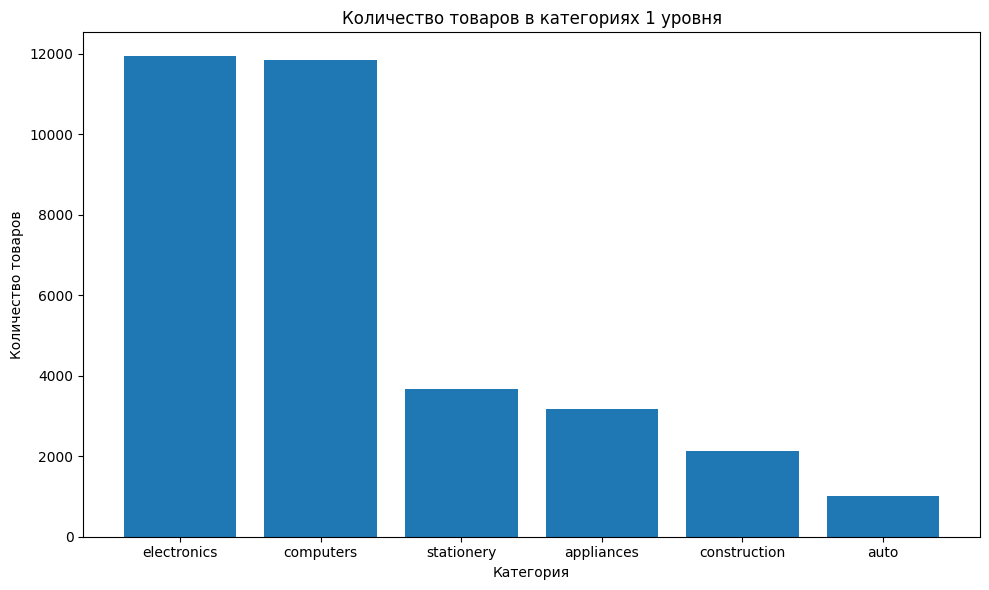

In [58]:
# Создадим новый датафрейм с уникальными товарами
unique_products = df[['product_id', 'category_lvl_1']].drop_duplicates()

# Посчитаем количество уникальных товаров в категориях
category_product_count = unique_products.groupby('category_lvl_1')['product_id'].count().loc[top_categories].sort_values(ascending=False)

# Построим график
plt.figure(figsize=(10, 6))

plt.bar(category_product_count.index, category_product_count.values, color='tab:blue')

plt.title('Количество товаров в категориях 1 уровня')
plt.xlabel('Категория')
plt.ylabel('Количество товаров')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

По размеру ассортимента с большим отрывом лидируют категории `electronics` и `computers` — каждая включает около 12 тыс. уникальных товаров. Остальные категории значительно уступают: их ассортимент варьируется примерно от 1 до 4 тыс. товаров, что в 3–12 раз меньше по сравнению с двумя лидерами.

Для дальнейшего анализа товары были разделены на три ценовых сегмента: **дешевые**, **средние** и **дорогие**.

При выборе границ сегментов учитывалась форма распределения цен. Ранее было установлено, что распределение имеет **сильную правостороннюю асимметрию**: основная масса товаров сосредоточена в низком и среднем ценовом диапазоне, а небольшая доля очень дорогих товаров формирует длинный правый хвост.

В качестве границ были выбраны следующие перцентили:

* **P25** — граница между дешевыми и средними товарами;
* **P90** — граница между средними и дорогими товарами.

Такой подход выбран осознанно:

* **нижняя четверть распределения (25%)** содержит наиболее доступные товары ассортимента и позволяет выделить действительно дешевые позиции;
* **верхние 10% товаров** формируют правый хвост распределения и представляют собой товары с существенно более высокой стоимостью относительно основной массы ассортимента;
* центральный интервал **P25 - P90** объединяет большую часть товаров магазина и рассматривается как сегмент **среднего ценового диапазона**.

В результате размеры сегментов получаются **асимметричными** (25% / 65% / 10%). Это сделано намеренно: цель сегментации заключается не в получении равных групп, а в выделении **устойчивых и хорошо различимых ценовых сегментов**. Благодаря этому последующий анализ просмотров, добавлений в корзину и покупок будет менее чувствителен к случайным колебаниям и позволит выявлять более надежные закономерности.

In [59]:
# Распределим товары по ценовым сегментам и создадим новый столбец price_segment

products = df[['product_id', 'price']].drop_duplicates()

# Границы сегментов
q25 = products['price'].quantile(0.25)
q90 = products['price'].quantile(0.90)

print(f'P25 - граница между дешевыми и средними товарами: {q25:.2f}')
print(f'P90 - граница между средними и дорогими товарами: {q90:.2f}')

# Функция сегментации
def price_segment(price):
    if price <= q25:
        return 'cheap'
    elif price >= q90:
        return 'expensive'
    else:
        return 'medium'

# Создаем столбец в таблице товаров
df['price_segment'] = df['price'].apply(price_segment)

P25 - граница между дешевыми и средними товарами: 14.86
P90 - граница между средними и дорогими товарами: 210.90


**Гистограмма цен уникальных товаров**

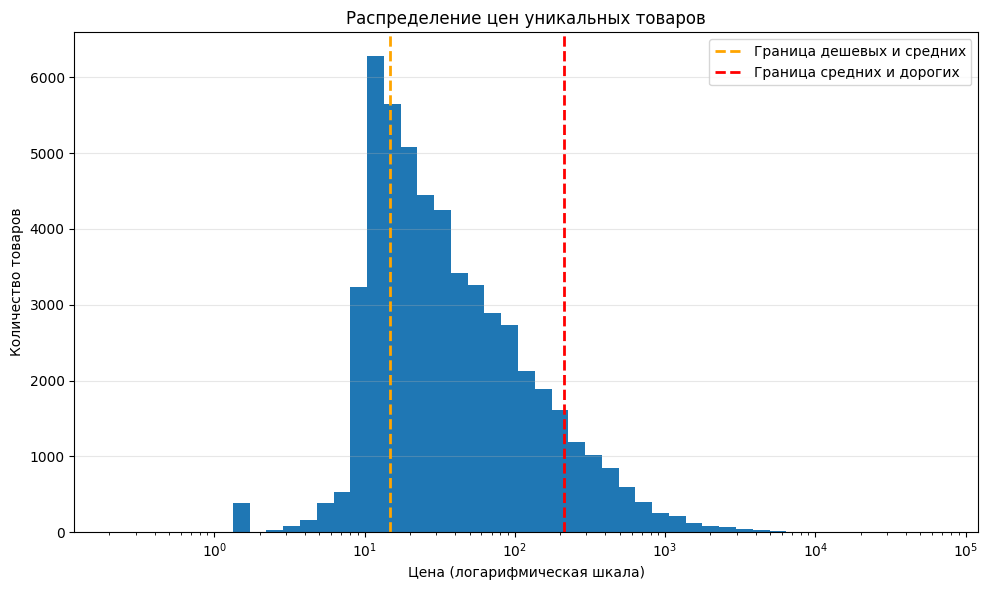

In [60]:
# Получаем уникальные товары
unique_products = df[['product_id', 'price']].drop_duplicates()

plt.figure(figsize=(10, 6))

bins = np.logspace(np.log10(unique_products['price'].min()), np.log10(unique_products['price'].max()))

plt.hist(unique_products['price'], bins=bins)

plt.xscale('log')

plt.axvline(x=14.86, color='orange', linestyle='--', linewidth=2, label='Граница дешевых и средних')

plt.axvline(x=210.90, color='red', linestyle='--', linewidth=2, label='Граница средних и дорогих')

plt.title('Распределение цен уникальных товаров')
plt.xlabel('Цена (логарифмическая шкала)')
plt.ylabel('Количество товаров')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Основные результаты анализа товаров и категорий

* В исследуемом датасете представлено более 53 тыс. уникальных товаров, относящихся к 107 категориям и 999 брендам, что позволяет проводить анализ ассортимента на нескольких уровнях детализации. При этом существенная часть категорий и брендов характеризуется крайне небольшим количеством событий, поэтому дальнейший анализ целесообразно сосредоточить на наиболее представительных группах.

* Наибольшее количество просмотров приходится на категории компьютерной техники и электроники, которые также обладают самым широким ассортиментом товаров. Вместе с тем анализ показывает, что размер ассортимента сам по себе не определяет количество просмотров: для отдельных брендов и категорий наблюдаются заметные различия между позицией по ассортименту и позицией по числу просмотров.

* Товары были разделены на ценовые сегменты: дешевые, средние и дорогие. <br><br>

### 2.3 Анализ пользовательской активности

**Уникальное количество пользователей и сессий**

In [61]:
print(f'Количество уникальных пользователей: {df['user_id'].nunique()}')
print(f'Количество уникальных сессий: {df['user_session'].nunique()}')

Количество уникальных пользователей: 406050
Количество уникальных сессий: 489029


**Распределение количества событий на пользователя**

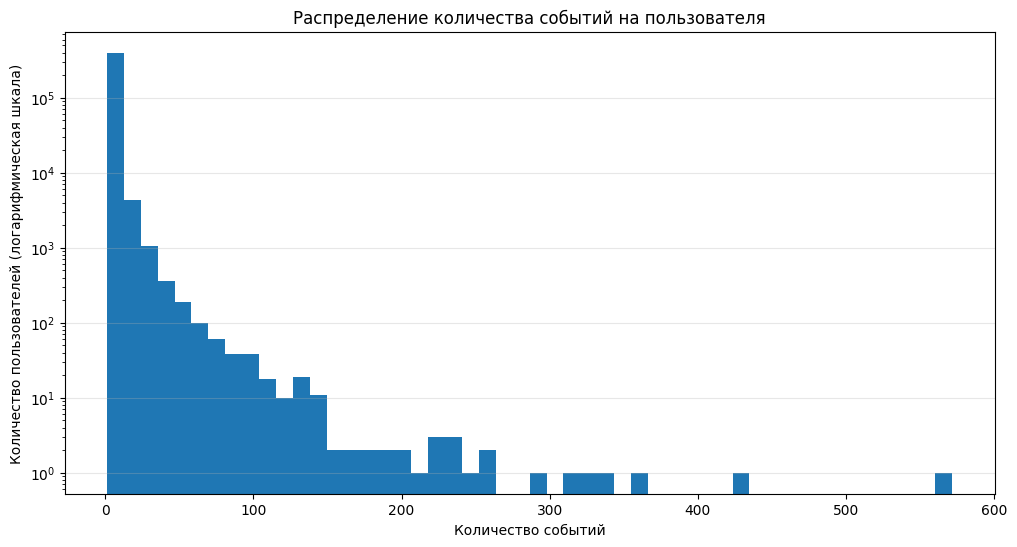

In [62]:
# Построим гистрограмму
events_per_user = df.groupby('user_id').size()

plt.figure(figsize=(12, 6))

plt.hist(events_per_user, bins=50)

plt.yscale('log')

plt.title('Распределение количества событий на пользователя')
plt.xlabel('Количество событий')
plt.ylabel('Количество пользователей (логарифмическая шкала)')

plt.grid(axis='y', alpha=0.3)

plt.show()

In [63]:
for x in [1, 2, 5, 10]:
    share = (events_per_user <= x).mean() * 100
    print(f'{share:.2f}% пользователей совершили не более {x} событий')

65.43% пользователей совершили не более 1 событий
81.07% пользователей совершили не более 2 событий
93.98% пользователей совершили не более 5 событий
97.93% пользователей совершили не более 10 событий


Распределение количества событий на пользователя имеет выраженную правостороннюю асимметрию с длинным правым хвостом. Большинство пользователей взаимодействуют с магазином лишь несколько раз: 
* **65.43%** пользователей совершили только **одно событие**
* **81%** — **не более двух событий**
* почти **94%** — **не более пяти событий**

Пользователи с высокой активностью встречаются значительно реже и составляют лишь небольшую часть выборки.

**Распределение количества сессий на пользователя**

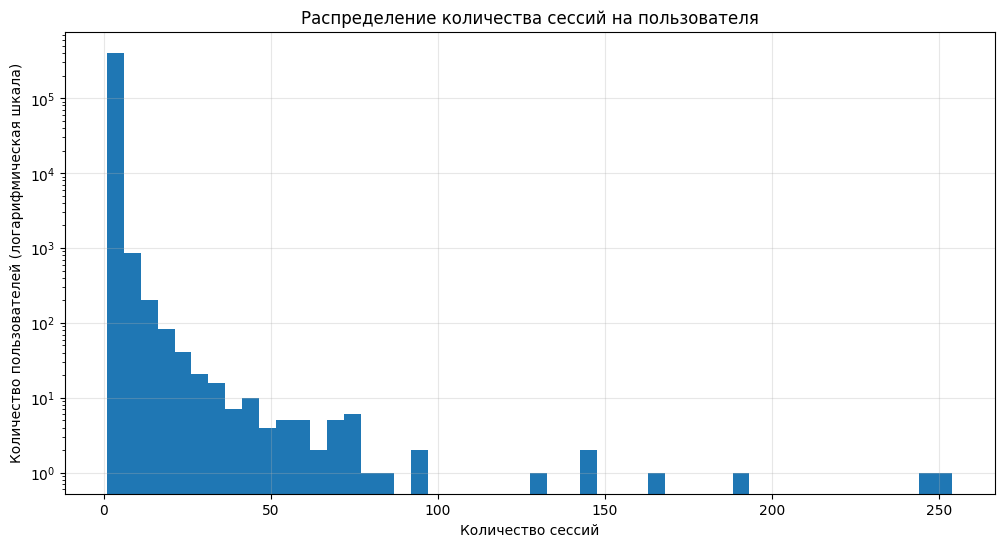

In [64]:
# Построим гистрограмму
sessions_per_user = df.groupby('user_id')['user_session'].nunique()

plt.figure(figsize=(12, 6))

plt.hist(sessions_per_user, bins=50)

plt.yscale('log')

plt.title('Распределение количества сессий на пользователя')
plt.xlabel('Количество сессий')
plt.ylabel('Количество пользователей (логарифмическая шкала)')

plt.grid(alpha=0.3)

plt.show()

In [65]:
for x in [1, 2]:
    share = (sessions_per_user <= x).mean() * 100
    print(f'{share:.2f}% пользователей имеют не более {x} сессий')

87.14% пользователей имеют не более 1 сессий
97.19% пользователей имеют не более 2 сессий


Распределение количества сессий на пользователя характеризуется выраженной правосторонней асимметрией с длинным правым хвостом. Большинство пользователей ограничиваются одной-двумя сессиями: **87.14%** пользователей имеют только **одну сессию**, а **97%** — **не более двух сессий**.   
Пользователи с высокой сессионной активностью составляют лишь небольшую часть выборки.

**Распределение количества событий в покупательных сессиях**

In [66]:
# Выведем покупательные сессии
purchase_sessions = df[df['event_type'] == 'purchase']['user_session'].unique()

events_per_purchase_session = df[df['user_session'].isin(purchase_sessions)].groupby('user_session').size()

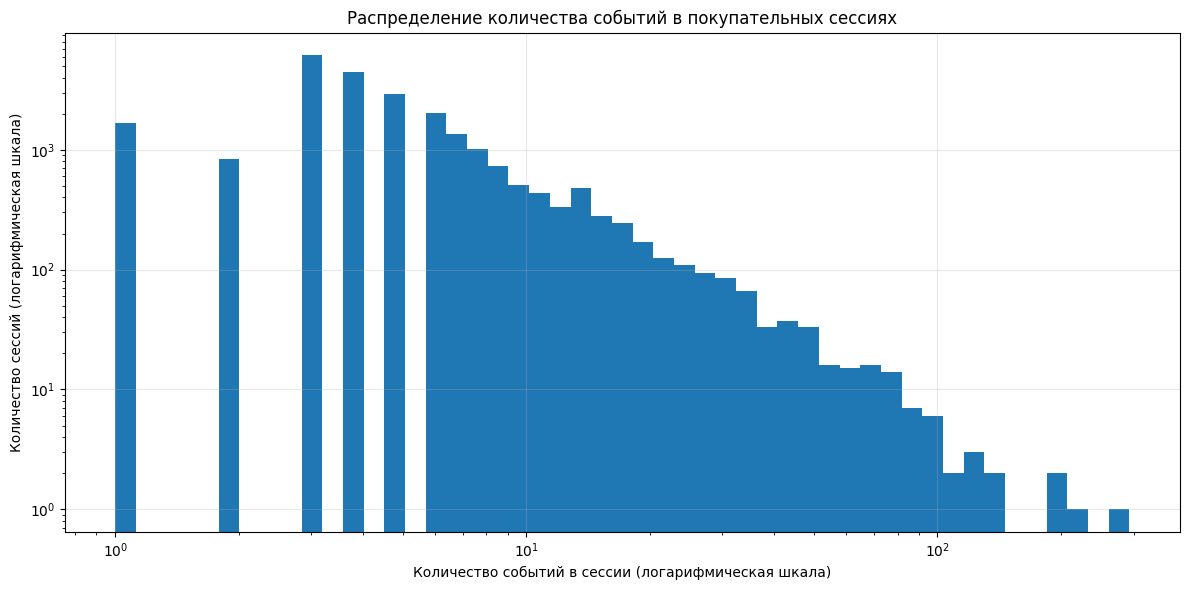

In [67]:
# Визуализируем результат
plt.figure(figsize=(12, 6))

bins = np.logspace(np.log10(events_per_purchase_session.min()), np.log10(events_per_purchase_session.max()))

plt.hist(events_per_purchase_session, bins=bins)

plt.xscale('log')
plt.yscale('log')

plt.title('Распределение количества событий в покупательных сессиях')
plt.xlabel('Количество событий в сессии (логарифмическая шкала)')
plt.ylabel('Количество сессий (логарифмическая шкала)')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
share = events_per_purchase_session.between(1, 2).mean() * 100

print(f'Доля покупательных сессий с 1 – 2 событиями: {share:.2f}%')

Доля покупательных сессий с 1 – 2 событиями: 10.40%


In [69]:
share = events_per_purchase_session.between(3, 5).mean() * 100

print(f'Доля покупательных сессий с 3 – 5 событиями: {share:.2f}%')

Доля покупательных сессий с 3 – 5 событиями: 55.52%


* Среди покупательных сессий встречаются сессии, содержащие лишь 1–2 события **(10%)**, то есть без полного набора этапов продуктовой воронки **(просмотр → добавление в корзину → покупка)**. По имеющимся данным невозможно однозначно определить причину этого явления. Возможными объяснениями являются продолжение пути пользователя из предыдущей сессии, неполная регистрация событий в датасете или использование механик покупки без предварительного добавления товара в корзину.

* Больше половины **(55.5%)** покупательных сессий приходится на сессии с 3 - 5 событиями, после чего их количество постепенно снижается по мере увеличения количества событий внутри сессий.

**Пользовательская активность по дням недели**

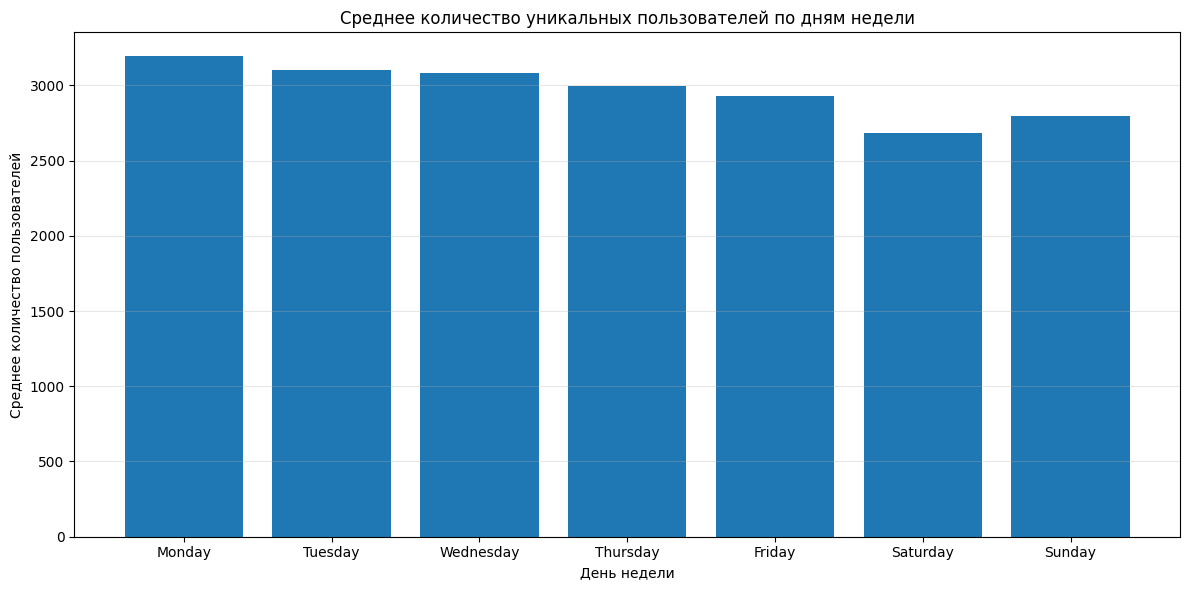

In [70]:
# Создадим новый столбец day_of_week
df['day_of_week'] = df['event_time'].dt.day_name()

users_by_day = (
    df.groupby(['day_of_week', df['event_time'].dt.date])['user_id']
    .nunique()
    .groupby('day_of_week')
    .mean()
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

plt.figure(figsize=(12, 6))

plt.bar(users_by_day.index, users_by_day.values)

plt.title('Среднее количество уникальных пользователей по дням недели')
plt.xlabel('День недели')
plt.ylabel('Среднее количество пользователей')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

В течение рабочей недели наблюдается постепенное снижение среднего количества уникальных пользователей: с максимума в понедельник до минимума в субботу. Это свидетельствует о наличии недельной сезонности пользовательской активности, где наибольшее число пользователей взаимодействует с платформой в будние дни, а наименьшее — в выходные.

**Суточная пользовательская активность**

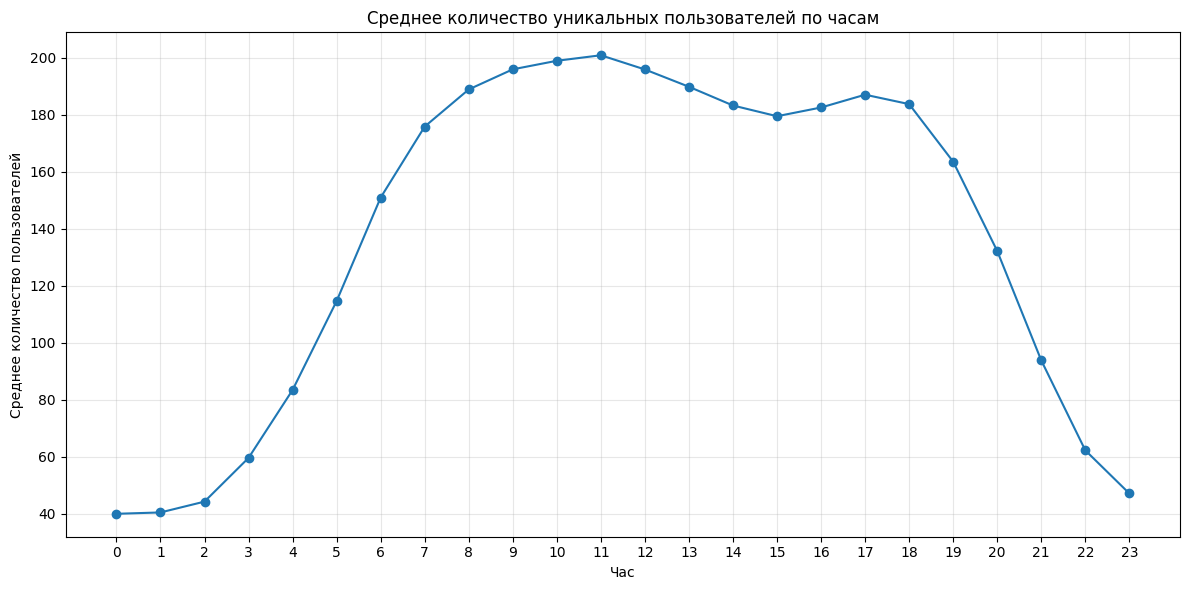

In [71]:
users_by_hour = (
    df.groupby([df['event_time'].dt.hour, df['event_time'].dt.date])['user_id']
    .nunique()
    .groupby('event_time')
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(users_by_hour.index, users_by_hour.values, marker='o')

plt.title('Среднее количество уникальных пользователей по часам')
plt.xlabel('Час')
plt.ylabel('Среднее количество пользователей')

plt.xticks(range(24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

* Пользовательская активность имеет ярко выраженную суточную сезонность. Наибольшее среднее количество уникальных пользователей наблюдается в дневные часы — примерно **с 10:00 до 18:00**, где активность остается на стабильно высоком уровне.
* Минимальная активность пользователей приходится на ночной период — **с 22:00 до 04:00**. В эти часы в сервис одновременно заходит наименьшее количество уникальных пользователей.
* Наиболее резкие изменения пользовательской активности наблюдаются в переходные периоды суток. **С 04:00 до 10:00** происходит быстрый рост числа уникальных пользователей (начало дневной активности), а **с 18:00 до 22:00** — наиболее интенсивное снижение, когда пользователи постепенно прекращают использование сервиса.

**Топ категорий по количеству просмотров карточек товара уникальными пользователями**

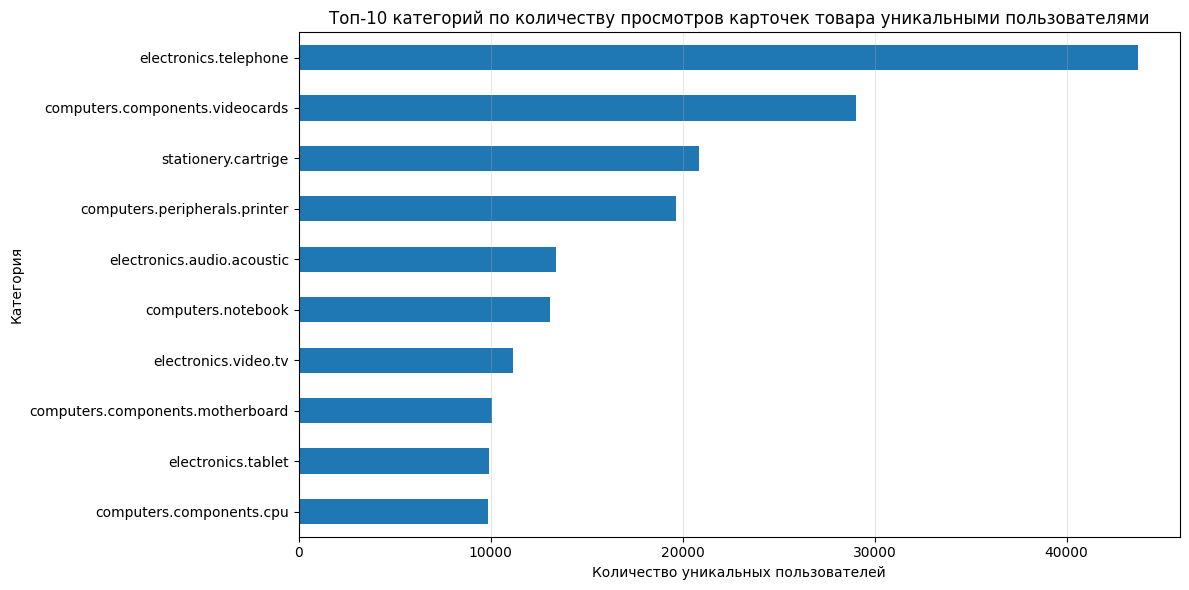

In [72]:
top_categories_users = (
    df[df['event_type'] == 'view']
    .groupby('category_code')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_categories_users.sort_values().plot(kind='barh')

plt.title('Топ-10 категорий по количеству просмотров карточек товара уникальными пользователями')
plt.xlabel('Количество уникальных пользователей')
plt.ylabel('Категория')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Категория `electronics.telephone` обладает самым широким ассортиментом товаров в магазине и одновременно лидирует по количеству уникальных пользователей. Напротив, `computers.components.videocards` не входит в число категорий с крупнейшим ассортиментом, однако занимает первое место по общему количеству просмотров карточек товаров.

Это свидетельствует о различиях в пользовательском поведении. **Категория телефонов** привлекает наиболее широкую аудиторию, что может быть частично обусловлено разнообразием представленных товаров. В то же время пользователи, **интересующиеся видеокартами**, в среднем просматривают значительно больше карточек товаров, несмотря на более ограниченный ассортимент категории. 

Вероятно, выбор видеокарт требует более длительного изучения характеристик и сравнения товаров, поэтому пользователи проводят больше времени в данной категории и совершают больше взаимодействий с карточками товаров.

**Топ брендов по количеству просмотров карточек товара уникальными пользователями**

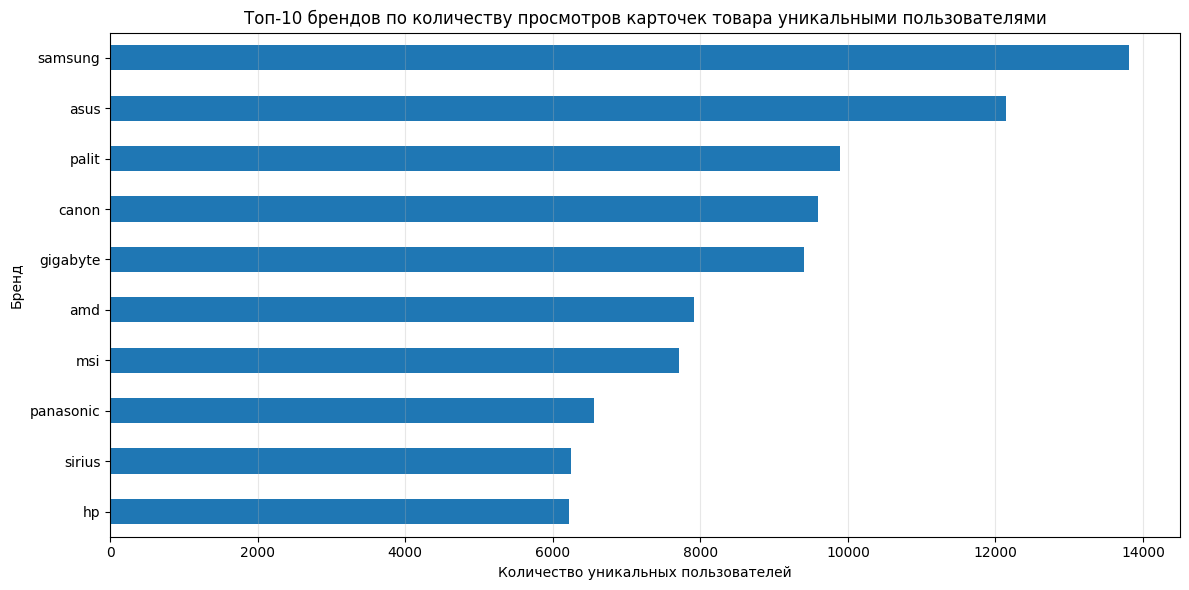

In [73]:
top_brands_users = (
    df[df['event_type'] == 'view']
    .groupby('brand')['user_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_brands_users.sort_values().plot(kind='barh')

plt.title('Топ-10 брендов по количеству просмотров карточек товара уникальными пользователями')
plt.xlabel('Количество уникальных пользователей')
plt.ylabel('Бренд')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

* **Samsung является ключевым брендом с точки зрения пользовательского интереса**   
Бренд одновременно лидирует по количеству уникальных пользователей и обладает самым широким ассортиментом товаров, что говорит о высокой узнаваемости и устойчивом спросе со стороны аудитории.

* **Asus демонстрирует наиболее эффективное использование ассортимента**   
Несмотря на то что ассортимент бренда почти в два раза меньше, чем у `Samsung`, `Asus` занимает второе место по числу уникальных пользователей и первое — по общему количеству просмотров карточек товаров. Это свидетельствует о высокой вовлеченности пользователей в товары бренда и может указывать на потенциал расширения линейки товаров или увеличения складских запасов наиболее востребованных позиций.

* **Широкий ассортимент сам по себе не гарантирует высокий пользовательский интерес**   
Например, `Sirius` входит в число брендов с самым большим количеством представленных товаров, однако значительно уступает лидерам по числу уникальных пользователей и просмотров. Это может свидетельствовать о менее востребованном ассортименте и указывает на необходимость оценки эффективности распределения ассортимента между брендами.


**Однако окончательные выводы о целесообразности перераспределения ресурсов можно делать только после анализа конверсии в покупку, поскольку на данном этапе рассматривается исключительно пользовательский интерес на уровне просмотров карточек товаров.**

**Сколько товаров в среднем покупает один пользователь**

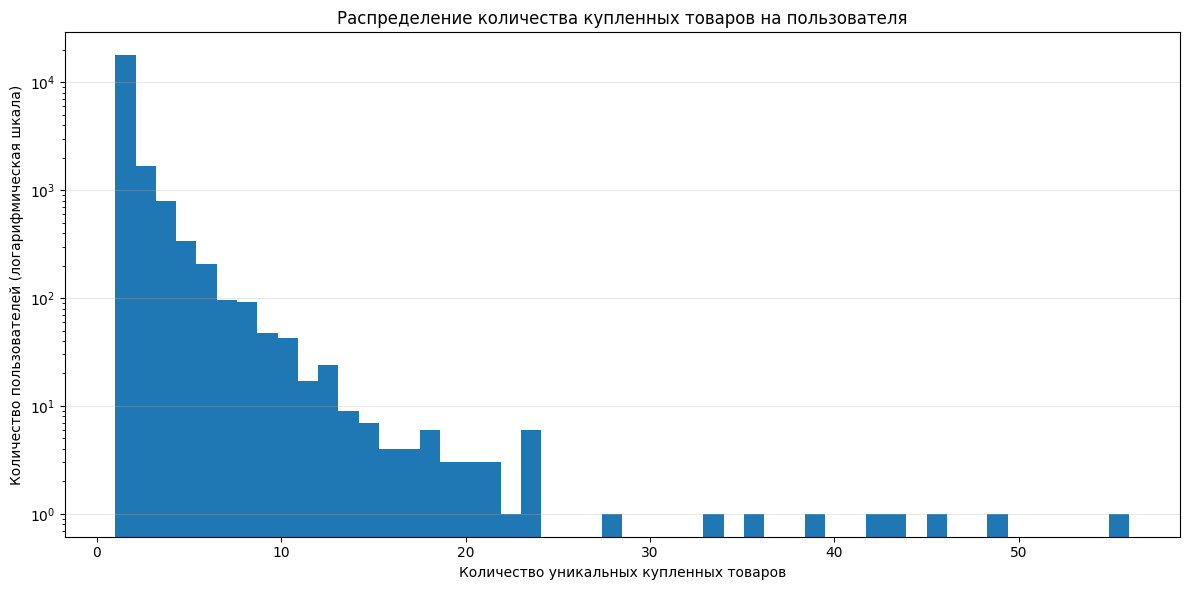

In [74]:
# Количество купленных товаров на пользователя
products_per_user = df[df['event_type'] == 'purchase'].groupby('user_id')['product_id'].count()

plt.figure(figsize=(12, 6))

plt.hist(products_per_user, bins=50)

plt.yscale('log')

plt.title('Распределение количества купленных товаров на пользователя')
plt.xlabel('Количество уникальных купленных товаров')
plt.ylabel('Количество пользователей (логарифмическая шкала)')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [75]:
for x in [1, 2, 5, 10]:
    share = (products_per_user <= x).mean() * 100
    print(f'{share:.2f}% пользователей купили не более {x} товаров')

63.82% пользователей купили не более 1 товаров
83.97% пользователей купили не более 2 товаров
97.26% пользователей купили не более 5 товаров
99.55% пользователей купили не более 10 товаров


Распределение имеет выраженный правосторонний характер. Большинство пользователей совершают разовые покупки: **63.82%** приобрели **только один товар**. Пользователи, покупающие большое количество товаров, встречаются крайне редко и формируют лишь небольшой хвост распределения.

**Насколько разнообразны покупки пользователей**

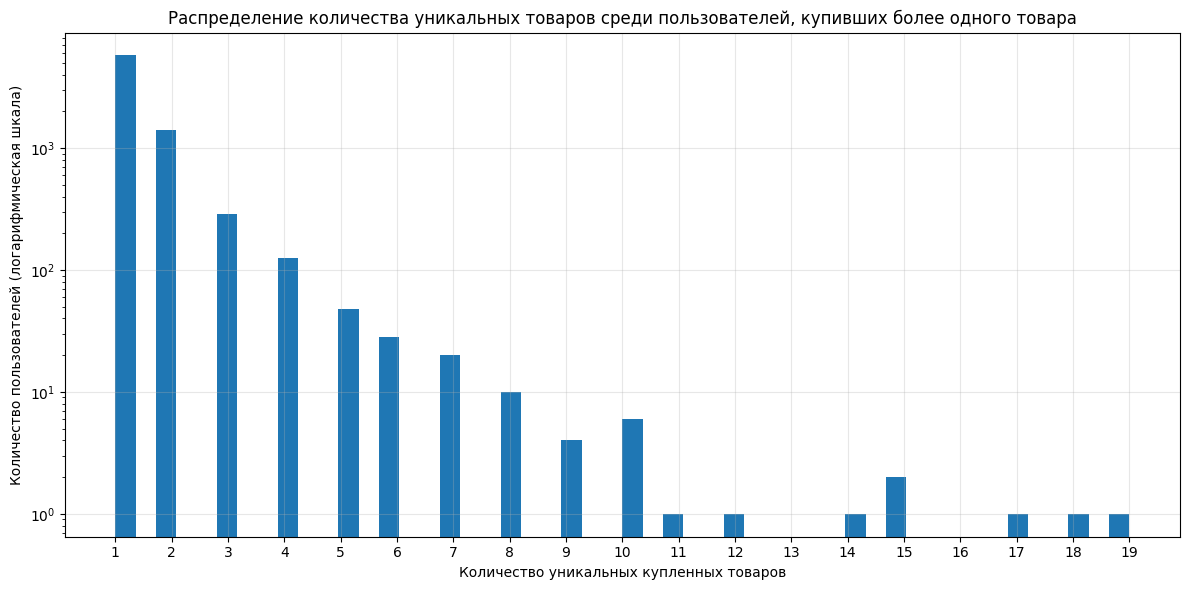

In [76]:
# Оставляем только покупки
purchases = df[df['event_type'] == 'purchase']

# Пользователи, купившие более одного товара
users_2plus = purchases.groupby('user_id').size()

users_2plus = users_2plus[users_2plus >= 2].index

# Считаем количество уникальных купленных товаров
unique_products_per_user = purchases[purchases['user_id'].isin(users_2plus)].groupby('user_id')['product_id'].nunique()

# Гистограмма
plt.figure(figsize=(12, 6))

plt.hist(unique_products_per_user, bins=50)

plt.yscale('log')

plt.xticks(range(unique_products_per_user.min(), unique_products_per_user.max() + 1))

plt.title('Распределение количества уникальных товаров среди пользователей, купивших более одного товара')
plt.xlabel('Количество уникальных купленных товаров')
plt.ylabel('Количество пользователей (логарифмическая шкала)')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Среди пользователей, купивших более одного товара, наиболее распространённым сценарием является повторная покупка одного и того же товара. Приобретение нескольких различных товаров встречается заметно реже, а с ростом разнообразия покупок количество таких пользователей постепенно снижается.

**Какие товары пользователи чаще всего покупают вместе**

In [77]:
# Оставляем только покупки
purchases = df[df['event_type'] == 'purchase']

# Удаляем покупки без категории
purchases = purchases.dropna(subset=['category_code'])

# Формируем корзины покупок по категориям
basket = purchases.groupby(['user_session', 'category_code'])['category_code'].count().unstack(fill_value=0)

# Преобразуем количества в бинарный формат (True/False)
basket = basket.astype(bool)

# Находим часто встречающиеся наборы категорий
frequent_itemsets = apriori(basket, min_support=0.01, use_colnames=True)

# Строим ассоциативные правила
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)

rules = rules.sort_values(by='lift', ascending=False)

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,frozenset({computers.components.cpu}),frozenset({computers.components.motherboard}),0.010161,0.235364,5.132744
1,frozenset({computers.components.motherboard}),frozenset({computers.components.cpu}),0.010161,0.221597,5.132744


In [78]:
share = rules['support'] * purchases['user_session'].nunique()
print(f'Товары покулись вместе в {share.loc[0]:.0f} сессиях.')

Товары покулись вместе в 197 сессиях.


**Алгоритм выявил устойчивую связь между категориями `computers.components.cpu` и `computers.components.motherboard`.**

* В 23.5% случаев после покупки процессора в рамках одной покупательской сессии также приобретается материнская плата.

* Совместная покупка этих категорий встречается почти в 200 покупательских сессиях за исследуемый период.

* Значение Lift = 5.13 показывает, что процессоры и материнские платы приобретаются вместе более чем в 5 раз чаще, чем это можно было бы ожидать при независимом выборе товаров.

**Данные категории являются естественными комплементарными товарами. Для увеличения среднего чека целесообразно использовать рекомендации сопутствующих товаров, готовые комплекты и совместные промо-предложения для покупателей процессоров и материнских плат.**

**"Время знакомства с товаром" и "Скорость принятия решения"**

In [79]:
# Сессии, завершившиеся покупкой
purchase_sessions = df[df['event_type'] == 'purchase']['user_session'].unique()

purchase_df = df[df['user_session'].isin(purchase_sessions)]


# Оставляем только товары, прошедшие всю воронку
products = purchase_df.groupby(['user_session', 'product_id'])['event_type'].unique().reset_index()


products = products[products['event_type'].apply(lambda x: 'view' in x and 'cart' in x and 'purchase' in x)]


purchase_df = purchase_df.merge(products[['user_session', 'product_id']], on=['user_session', 'product_id'])


# Первое событие каждого типа
events = purchase_df.groupby(['user_session', 'product_id', 'event_type'])['event_time'].min().unstack().reset_index()


# Добавляем ценовой сегмент
price_segment = purchase_df.groupby(['user_session', 'product_id'])['price_segment'].first().reset_index()


events = events.merge(price_segment, on=['user_session', 'product_id'])


# Оставляем только корректную последовательность событий
events = events[(events['view'] < events['cart']) & (events['cart'] < events['purchase'])]


# Время между просмотром и корзиной (минуты)
events['time_to_cart'] = (events['cart'] - events['view']).dt.total_seconds() / 60


# Время между корзиной и покупкой (минуты)
events['time_to_purchase'] = (events['purchase'] - events['cart']).dt.total_seconds() / 60


# Итоговая статистика
summary = (events.groupby('price_segment')
    .agg(median_time_to_cart=('time_to_cart', 'median'), median_time_to_purchase=('time_to_purchase', 'median')).round(2))

summary = summary.reindex(['cheap', 'medium', 'expensive'])

summary

,median_time_to_cart,median_time_to_purchase
price_segment,,
cheap,0.82,1.60
medium,1.07,1.72
expensive,0.70,1.28


Предполагалось, что более дорогие товары требуют большего времени для принятия решения, однако анализ этого не подтвердил. Во всех ценовых сегментах медианное время между первым просмотром товара и его добавлением в корзину составило около одной минуты, а между добавлением в корзину и покупкой — около двух минут. Это может свидетельствовать о том, что пользователи, приобретающие товары независимо от их стоимости, зачастую приходят на сайт уже с готовым решением о покупке, а основная часть процесса выбора происходит за пределами интернет-магазина.

In [80]:
# Сессии, завершившиеся покупкой
purchase_sessions = df[df['event_type'] == 'purchase']['user_session'].unique()

purchase_df = df[df['user_session'].isin(purchase_sessions)]


# Оставляем только товары, прошедшие всю воронку
products = purchase_df.groupby(['user_session', 'product_id'])['event_type'].unique().reset_index()


products = products[products['event_type'].apply(lambda x: 'view' in x and 'cart' in x and 'purchase' in x)]


purchase_df = purchase_df.merge(products[['user_session', 'product_id']], on=['user_session', 'product_id'])


# Первое событие каждого типа
events = purchase_df.groupby(['user_session', 'product_id', 'event_type'])['event_time'].min().unstack().reset_index()


# Добавляем категории 1 уровня
category_segment = purchase_df.groupby(['user_session', 'product_id'])['category_lvl_1'].first().reset_index()


events = events.merge(category_segment, on=['user_session', 'product_id'])


# Оставляем только корректную последовательность событий
events = events[(events['view'] < events['cart']) & (events['cart'] < events['purchase'])]


# Только топ-6 категорий
events = events[events['category_lvl_1'].isin(top_categories)]


# Время между просмотром и корзиной (минуты)
events['time_to_cart'] = (events['cart'] - events['view']).dt.total_seconds() / 60


# Время между корзиной и покупкой (минуты)
events['time_to_purchase'] = (events['purchase'] - events['cart']).dt.total_seconds() / 60


# Итоговая статистика
summary = (events.groupby('category_lvl_1')
    .agg(median_time_to_cart=('time_to_cart', 'median'),median_time_to_purchase=('time_to_purchase', 'median')).round(2))

summary

,median_time_to_cart,median_time_to_purchase
category_lvl_1,,
appliances,1.37,1.67
auto,1.25,1.72
computers,0.83,1.50
construction,1.42,1.70
electronics,1.03,1.67
stationery,0.70,1.78


Во всех исследуемых категориях и ценовых сегментах медианное время между добавлением товара в корзину и его покупкой оказалось несколько выше, чем между первым просмотром товара и добавлением в корзину. Вероятно, после добавления товара в корзину пользователи тратят дополнительное время на оформление заказа, проверку содержимого корзины или добавление других товаров перед завершением покупки.

### Основные результаты анализа пользовательской активности

* **Анализ пользовательской активности показал, что большинство пользователей взаимодействуют с интернет-магазином лишь эпизодически.** Более 65% пользователей совершают только одно событие, 81% — не более двух, а 87% ограничиваются одной сессией. Это свидетельствует о высокой доле пользователей с единичными взаимодействиями и относительно небольшой группе наиболее активной аудитории, формирующей основную часть событий в датасете.

* **Успешные покупки в большинстве случаев совершаются в рамках коротких пользовательских сценариев.** Более половины покупательских сессий содержат всего 3–5 событий, что свидетельствует о том, что для значительной части пользователей путь до покупки не требует большого количества взаимодействий с платформой. При этом около 10% покупательских сессий не содержат полного набора этапов продуктовой воронки, что может указывать как на особенности логики работы интернет-магазина, так и на ограничения исходных данных.

* **Пользовательская активность имеет выраженную временную сезонность.** Наибольшее количество уникальных пользователей наблюдается в будние дни, особенно в начале рабочей недели, а также в дневные часы (10:00–18:00). В выходные и ночное время активность существенно снижается, что отражает типичный сценарий использования интернет-магазина.

* **Анализ пользовательского интереса показал, что различные категории товаров характеризуются разными моделями поведения аудитории.** Телефоны привлекают наибольшее количество уникальных пользователей благодаря широкому ассортименту, тогда как видеокарты лидируют по количеству просмотров карточек товаров. Это позволяет предположить, что пользователи, выбирающие видеокарты, проводят больше времени за сравнением различных моделей и изучением характеристик.

* **Среди брендов наибольший пользовательский интерес демонстрируют `Samsung` и `Asus`.** При этом `Asus` показывает особенно высокую вовлечённость пользователей относительно размеров ассортимента, тогда как широкий ассортимент отдельных брендов сам по себе не гарантирует высокий интерес аудитории. Однако окончательные выводы об эффективности ассортимента требуют дальнейшего анализа конверсии в покупку.

* **Большинство покупателей приобретают только один товар, а среди пользователей, совершающих несколько покупок, наиболее распространён повторный выбор одного и того же товара.** При этом анализ совместных покупок выявил устойчивую связь между процессорами и материнскими платами, которые приобретаются вместе более чем в пять раз чаще, чем можно ожидать при независимом выборе товаров. Это указывает на потенциал использования рекомендаций сопутствующих товаров, готовых комплектов и совместных промо-предложений для увеличения среднего чека.

* **Предполагалось, что более дорогие товары требуют большего времени для принятия решения, однако анализ этой гипотезы не подтвердил.** Во всех ценовых сегментах медианное время между просмотром товара и его добавлением в корзину составило около одной минуты, а между добавлением в корзину и покупкой — около двух минут. Это позволяет предположить, что значительная часть пользователей приходит на сайт уже с готовым намерением совершить покупку, а основной этап выбора товара происходит за пределами интернет-магазина.

Сохраняем очищенный датасет с добавленными признаками `category_lvl_1`, `price_segment` и `day_of_week` в новый файл `events_clean_update.csv`, который будет использоваться для дальнейшего анализа в PostgreSQL.

In [81]:
# Сохраним текущий датасет в новый файл events_clean_update.csv
df.to_csv('data/processed/events_clean_update.csv', index=False, date_format='%Y-%m-%d %H:%M:%S')

## Выводы по разделу «Исследовательский анализ данных»

**В ходе исследовательского анализа данных была изучена структура пользовательского поведения, особенности ассортимента и основные закономерности взаимодействия пользователей с интернет-магазином.**

**Анализ событий** показал, что основную часть активности формируют просмотры товаров (89,66%), тогда как добавления в корзину и покупки составляют значительно меньшую долю. При этом соотношение между этапами взаимодействия остается стабильным во времени, что указывает на устойчивую структуру пользовательского поведения. Вместе с тем были выявлены временные колебания активности, однако их причины невозможно однозначно определить из-за отсутствия информации о внешних факторах, таких как маркетинговые кампании или изменения ассортимента. <br><br>

**Анализ товаров и категорий** показал, что пользовательский интерес распределен неравномерно: основная активность сосредоточена вокруг категорий электроники и компьютерной техники. При этом количество представленных товаров не является единственным фактором, определяющим интерес пользователей — отдельные категории и бренды демонстрируют различный уровень вовлеченности аудитории относительно размера своего ассортимента. Это указывает на необходимость дальнейшего анализа не только спроса, но и эффективности конверсии различных товарных групп. <br><br>

**Исследование пользовательской активности** выявило, что большая часть аудитории взаимодействует с магазином эпизодически: большинство пользователей совершают небольшое количество событий и ограничиваются одной сессией. При этом успешные покупки чаще происходят в рамках коротких пользовательских сценариев, что может свидетельствовать о наличии сформированного намерения покупки до посещения сайта. Дополнительно было установлено, что пользовательская активность имеет выраженную временную сезонность: максимальная активность наблюдается в будние дни и дневное время. <br><br>

**Анализ поведения покупателей** показал, что большинство пользователей приобретают ограниченное количество товаров, однако существуют категории с выраженными взаимосвязями между покупками. В частности, совместная покупка процессоров и материнских плат демонстрирует потенциальную возможность использования рекомендательных механизмов и товарных комплектов для увеличения среднего чека. <br><br>

**Проверка гипотезы** о зависимости времени принятия решения от стоимости товара не подтвердила предположение о том, что дорогие товары требуют более длительного выбора. Во всех ценовых сегментах пользователи переходят от просмотра товара к покупке за короткий промежуток времени, что может указывать на предварительный выбор товара за пределами платформы. <br><br>

**Таким образом, исследовательский анализ позволил выявить основные особенности поведения пользователей и структуры спроса, однако для оценки эффективности продукта необходим дальнейший переход к расчету продуктовых метрик.** <br><br>

## 3. Анализ ключевых продуктовых метрик

### 3.1 Анализ активности аудитории

**DAU**

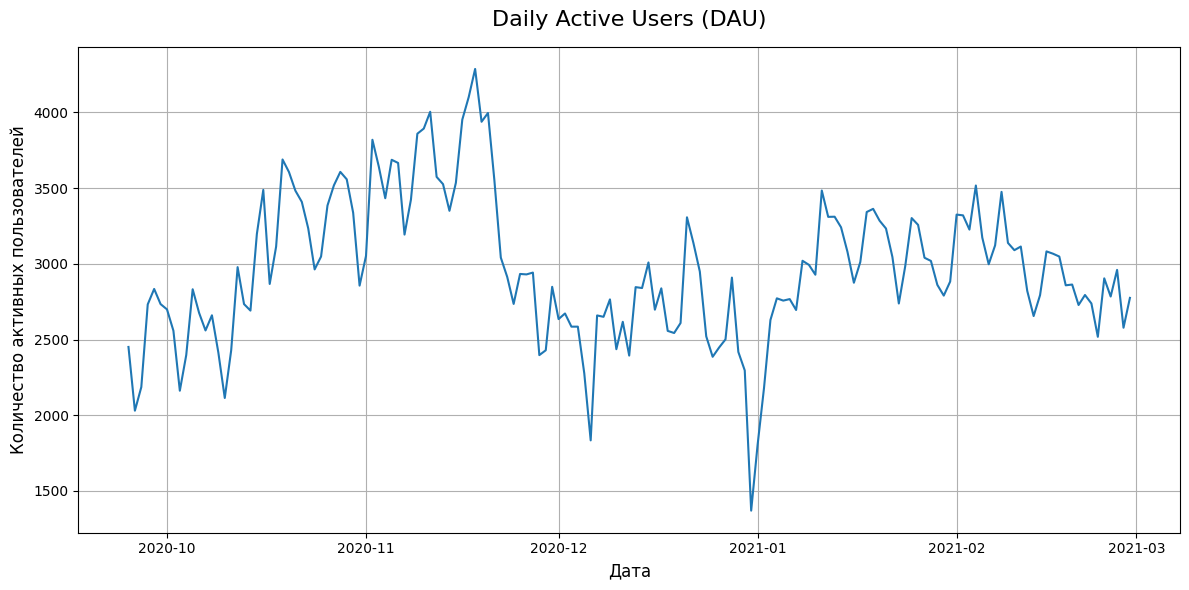

In [82]:
# Импорт данных
dau_df = pd.read_csv('exports/DAU.csv')

# Преобразование даты
dau_df['date_day'] = pd.to_datetime(dau_df['date_day'])

# Построение графика
plt.figure(figsize=(12, 6))

plt.plot(dau_df['date_day'], dau_df['count_users'])

plt.title('Daily Active Users (DAU)', fontsize=16, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество активных пользователей', fontsize=12)

plt.grid()

plt.tight_layout()

plt.show()

**WAU**

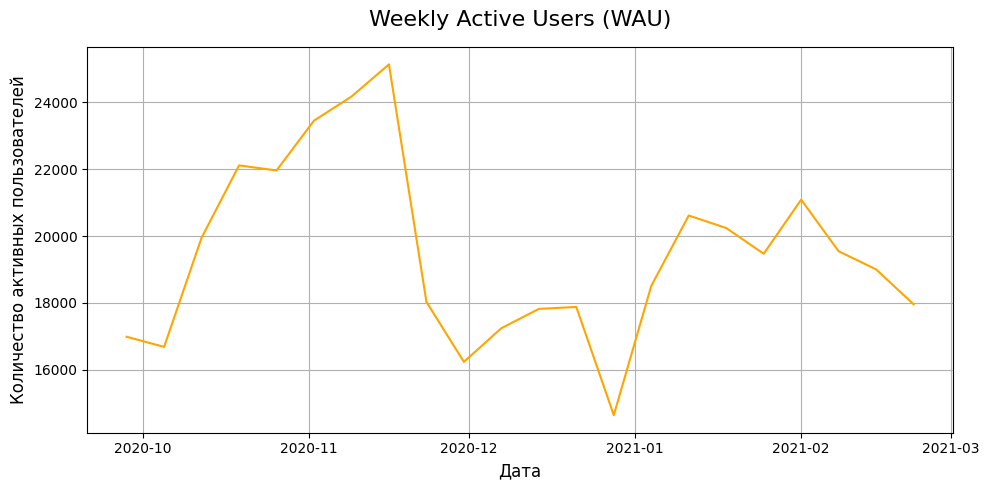

In [83]:
# Импорт данных
wau_df = pd.read_csv('exports/WAU.csv')

# Преобразование даты
wau_df['date_week'] = pd.to_datetime(wau_df['date_week'])

# Построение графика
plt.figure(figsize=(10, 5))

plt.plot(wau_df['date_week'], wau_df['count_users'], color='orange')

plt.title('Weekly Active Users (WAU)', fontsize=16, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество активных пользователей', fontsize=12)

plt.grid()

plt.tight_layout()

plt.show()

**MAU**

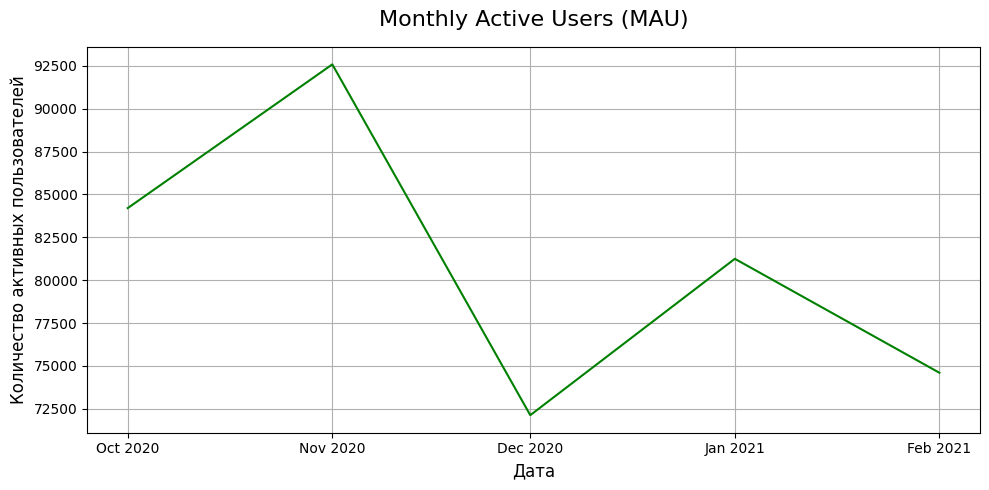

In [84]:
# Импорт данных
mau_df = pd.read_csv('exports/MAU.csv')

# Преобразование даты
mau_df['date_month'] = pd.to_datetime(mau_df['date_month'])

# Построение графика
plt.figure(figsize=(10, 5))

plt.plot(mau_df['date_month'], mau_df['count_users'], color='green')

plt.title('Monthly Active Users (MAU)', fontsize=16, pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество активных пользователей', fontsize=12)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.grid()

plt.tight_layout()

plt.show()

**Stickiness**

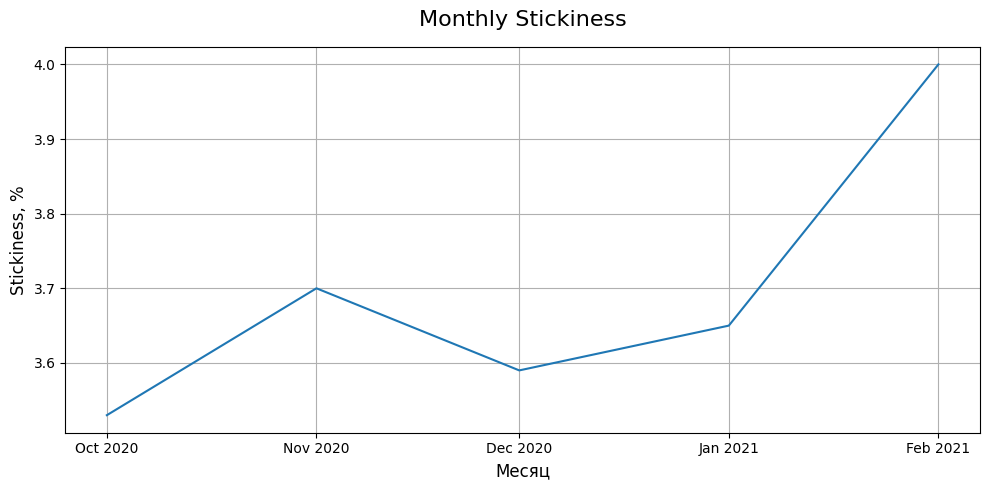

In [85]:
# Импорт данных
stickiness_df = pd.read_csv('exports/Stickiness.csv')

# Преобразование даты
stickiness_df['date_month'] = pd.to_datetime(stickiness_df['date_month'])

# Построение графика
plt.figure(figsize=(10, 5))

plt.plot(stickiness_df['date_month'], stickiness_df['stickiness'])

plt.title('Monthly Stickiness', fontsize=16, pad=15)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Stickiness, %', fontsize=12)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.grid()

plt.tight_layout()
plt.show()

### Основные результаты анализа активности аудитории

- Динамика **DAU практически повторяет динамику общего количества событий**, что позволяет сделать вывод, что основные изменения активности продукта связаны преимущественно с изменением количества активных пользователей, а не с изменением поведения существующей аудитории.

- **В ноябре наблюдается максимальный уровень** пользовательской активности: **MAU достигает около 92 тыс. пользователей**. Однако уже в декабре количество активных пользователей существенно снижается и в дальнейшем остается ниже ноябрьского уровня. Причины изменения размера аудитории невозможно определить на основе доступных данных.

- **WAU** и **MAU** демонстрируют аналогичную динамику с **DAU** и подтверждают наличие временных колебаний пользовательской базы, но не выявляют дополнительных закономерностей.

- **Stickiness** остается стабильным в диапазоне **3.5 – 4%** на протяжении всего исследуемого периода, что соответствует примерно **1–1.2 дням активности** пользователя в месяц. Это указывает на низкую частоту возвращения пользователей и отсутствие устойчивого регулярного взаимодействия с продуктом. <br><br>

### 3.2 Анализ продуктовой воронки

**Общий анализ воронки**

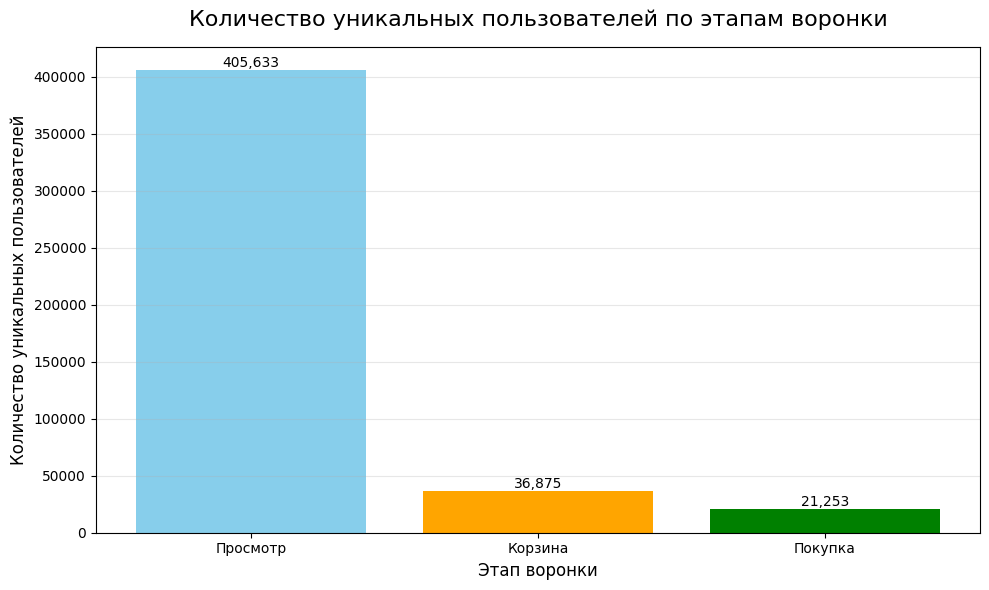

Конверсия View → Cart: 9.09%
Конверсия Cart → Purchase: 57.64%
Общая конверсия View → Purchase: 5.24%


In [86]:
# Импорт данных
conversion_df = pd.read_csv('exports/General_conversion.csv')

# Данные
event_types = ['Просмотр', 'Корзина', 'Покупка']
user_counts = [conversion_df['uniq_count_view'].iloc[0], conversion_df['uniq_count_cart'].iloc[0], conversion_df['uniq_count_purchase'].iloc[0]]

general_conversion = conversion_df['general_conversion'].iloc[0]
conversion_to_cart = conversion_df['conversion_to_cart'].iloc[0]
conversion_to_purchase = conversion_df['conversion_to_purchase'].iloc[0]

# График
plt.figure(figsize=(10, 6))

bars = plt.bar(event_types, user_counts, color=['skyblue', 'orange', 'green'])

plt.title('Количество уникальных пользователей по этапам воронки', fontsize=16, pad=15)
plt.xlabel('Этап воронки', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)

for bar, value in zip(bars, user_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:,}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Конверсия View → Cart: {conversion_to_cart:.2f}%')
print(f'Конверсия Cart → Purchase: {conversion_to_purchase:.2f}%')
print(f'Общая конверсия View → Purchase: {general_conversion:.2f}%')

**Основная проблема воронки находится на этапе формирования намерения к покупке.**   
Большинство пользователей, заинтересовавшихся товаром и открывших его страницу, не переходят к добавлению товара в корзину. При этом после добавления в корзину вероятность завершения покупки существенно выше, что указывает на то, что основной потенциал роста конверсии находится не на этапе оформления заказа, а раньше — в превращении интереса к товару в намерение его приобрести.

**Анализ потерь пользователей**

После общего анализа продуктовой воронки было установлено, что наибольшая потеря пользователей происходит на этапе **«просмотр → добавление в корзину»**. Поэтому дальнейший анализ сосредоточен на поиске факторов, которые могут быть связаны с низкой конверсией именно на этом этапе.

Для этого выбраны несколько разрезов, позволяющих рассмотреть проблему с разных сторон:

* **Категории 1-го уровня — топ-6**: позволяют определить, насколько проблема характерна для наиболее востребованных направлений магазина и не скрывается ли основная потеря пользователей в отдельных крупных категориях.

* **Конечные категории — 6 наиболее показательных**: отобраны по совокупности результатов EDA — пользовательскому интересу, количеству просмотров и широте ассортимента. Это категории-флагманы, которые в наибольшей степени характеризуют основные направления спроса в магазине.

* **Бренды — `Samsung` и `Asus`**: два наиболее заметных бренда по результатам предыдущего анализа, позволяющие проверить, отличается ли поведение пользователей в зависимости от бренда товара.

* **Ценовые сегменты**: позволяют проверить, зависит ли переход от просмотра к корзине от стоимости товара — иными словами, не является ли цена одним из факторов, влияющих на решение пользователя продолжить покупку.

* **Сегменты по количеству сессий**: разделение пользователей на «одноразовых» (1 сессия за весь период) и «повторных» (2 и более сессий) позволяет проверить, отличается ли поведение более вовлечённых пользователей от тех, кто взаимодействовал с магазином однократно.

**Категории 1-го уровня**

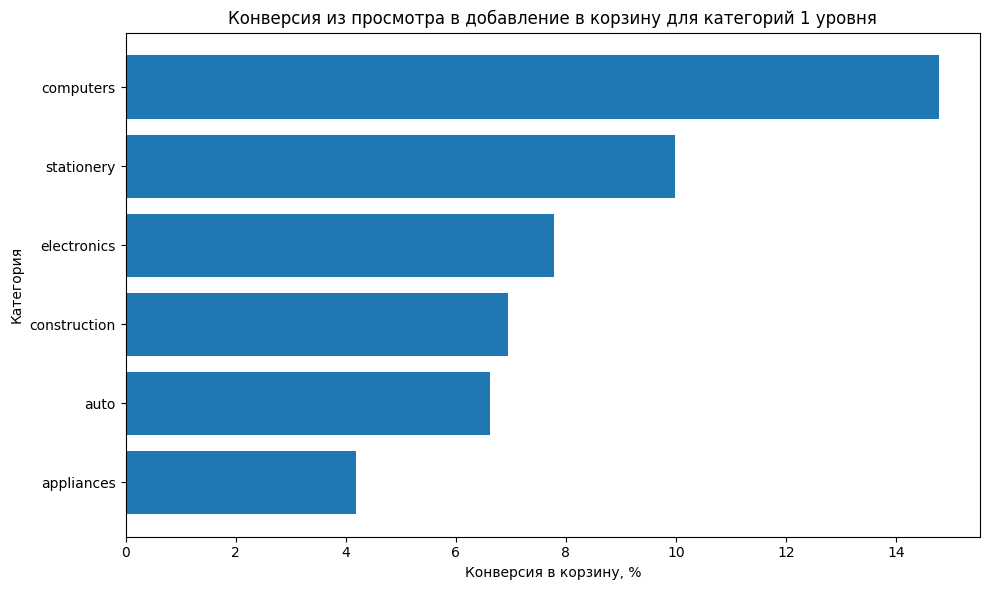

In [87]:
category_conversion = pd.read_csv('exports/Category_lvl_1_conversion_to_cart.csv')

category_conversion = category_conversion.sort_values('conversion_to_cart', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(category_conversion['category_lvl_1'], category_conversion['conversion_to_cart'])

plt.xlabel('Конверсия в корзину, %')
plt.ylabel('Категория')
plt.title('Конверсия из просмотра в добавление в корзину для категорий 1 уровня')

plt.tight_layout()
plt.show()

Конверсия из просмотра в добавление в корзину существенно различается между категориями 1-го уровня — **от 4,19%** в `appliances` **до 14,79%** в `computers`.

**Конечные категории**

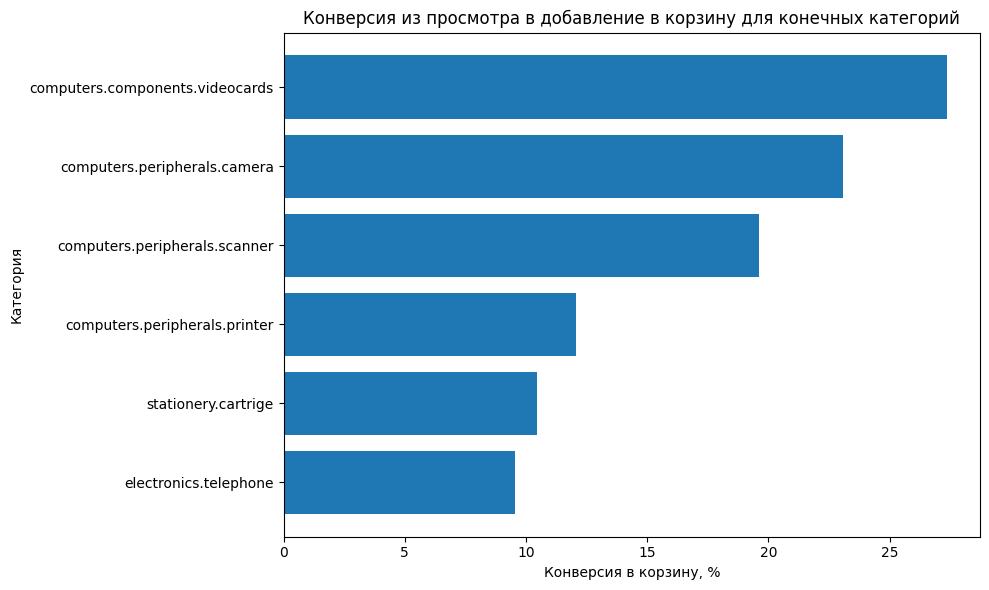

In [88]:
cat_conversion = pd.read_csv('exports/Category_code_conversion_to_cart.csv')

cat_conversion = cat_conversion.sort_values('conversion_to_cart', ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(cat_conversion['category_code'], cat_conversion['conversion_to_cart'])

plt.xlabel('Конверсия в корзину, %')
plt.ylabel('Категория')
plt.title('Конверсия из просмотра в добавление в корзину для конечных категорий')

plt.tight_layout()
plt.show()

В отобранных конечных категориях наблюдается ещё более выраженный разброс конверсии — **от 9,56%** в `electronics.telephone` **до 27,36%** в `computers.components.videocards`.

**Бренды**

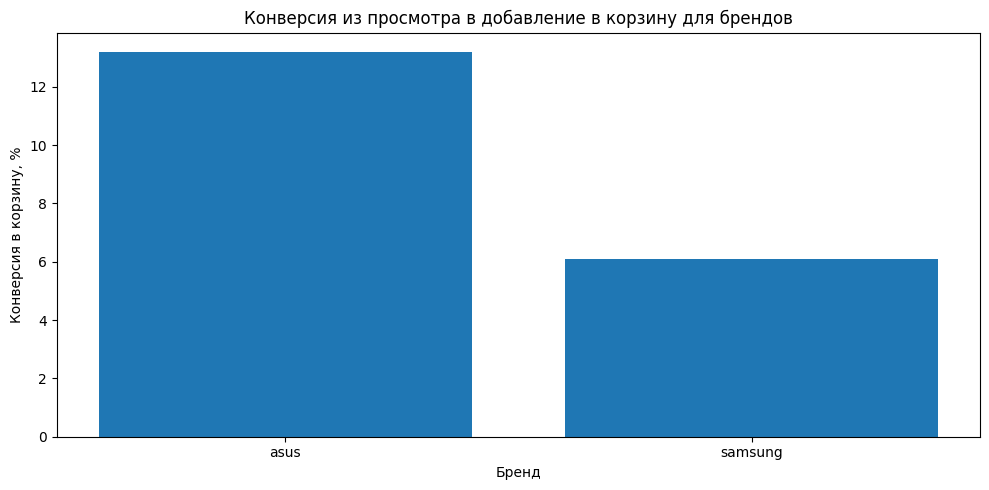

In [89]:
brand_conversion = pd.read_csv('exports/Brand_conversion_to_cart.csv')

plt.figure(figsize=(10, 5))

plt.bar(brand_conversion['brand'], brand_conversion['conversion_to_cart'])

plt.xlabel('Бренд')
plt.ylabel('Конверсия в корзину, %')
plt.title('Конверсия из просмотра в добавление в корзину для брендов')

plt.tight_layout()
plt.show()

Конверсия в добавление в корзину у `Asus` **(13,20%)** более чем в два раза выше, чем у `Samsung` **(6,10%)**, при сопоставимом объёме пользовательского интереса. Это указывает на заметные различия в поведении пользователей между двумя флагманскими брендами.

**Ценовые сегменты**

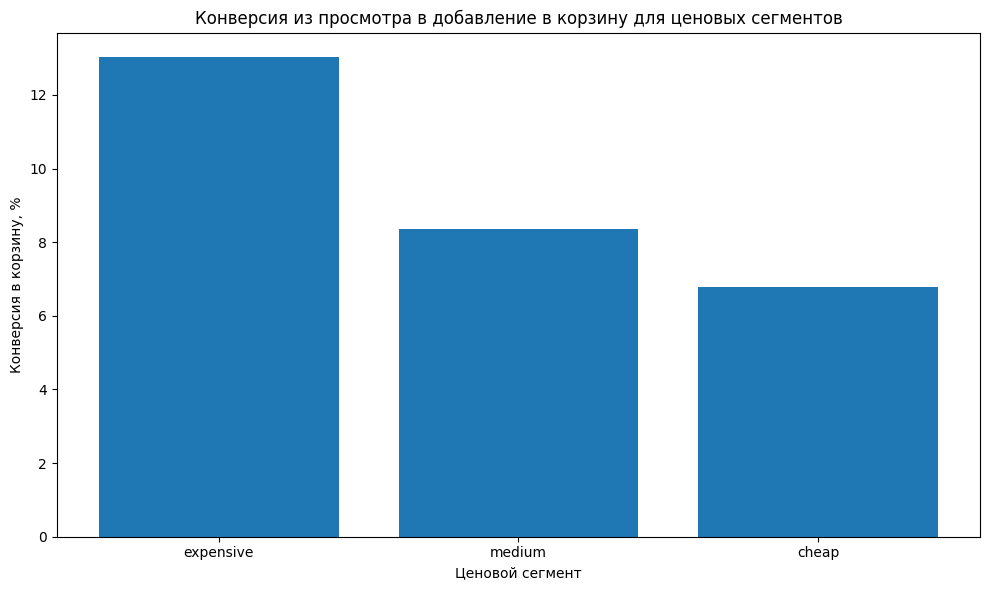

In [90]:
price_conversion = pd.read_csv('exports/Price_segment_conversion_to_cart.csv')

plt.figure(figsize=(10, 6))

plt.bar(price_conversion['price_segment'], price_conversion['conversion_to_cart'])

plt.xlabel('Ценовой сегмент')
plt.ylabel('Конверсия в корзину, %')
plt.title('Конверсия из просмотра в добавление в корзину для ценовых сегментов')

plt.tight_layout()
plt.show()

Конверсия из просмотра в корзину последовательно увеличивается с ростом ценового сегмента: **от 6,79%** для дешёвых товаров **до 13,04%** для дорогих.
Таким образом, более дорогие товары демонстрируют значительно более высокую готовность пользователей к добавлению в корзину.

**Сегменты по количеству сессий**

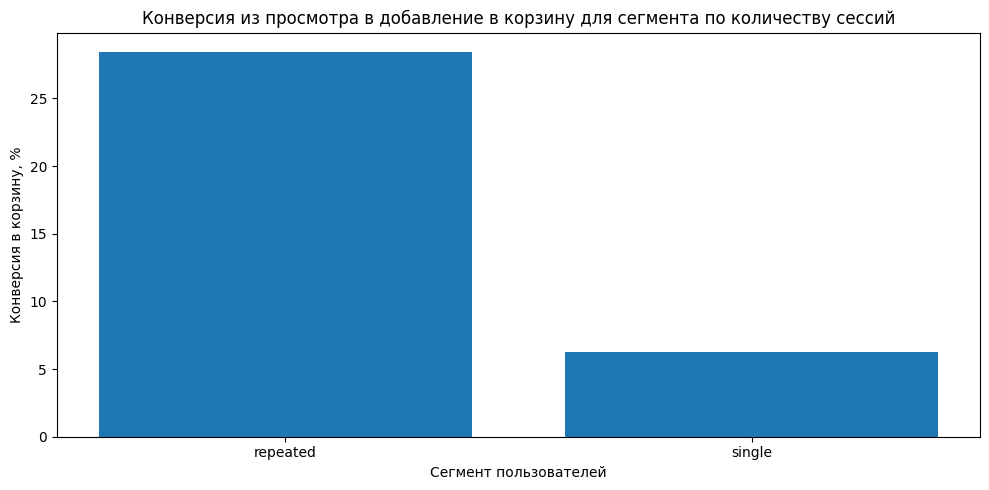

In [91]:
session_conversion = pd.read_csv('exports/Session_segment_conversion_to_cart.csv')

plt.figure(figsize=(10, 5))

plt.bar(session_conversion['session_segment'], session_conversion['conversion_to_cart'])

plt.xlabel('Сегмент пользователей')
plt.ylabel('Конверсия в корзину, %')
plt.title('Конверсия из просмотра в добавление в корзину для сегмента по количеству сессий')

plt.tight_layout()
plt.show()

Между сегментами пользователей наблюдается наиболее существенный разрыв в конверсии: у повторных пользователей она составляет **28,44%**, что в 4,6 раза выше показателя одноразовых пользователей **(6,23%)**. При этом одноразовые пользователи значительно преобладают по численности, поэтому их низкая конверсия оказывает существенное влияние на общий показатель перехода от просмотра к корзине.

**Конверсия в корзину по типу пользователя и ценовому сегменту**

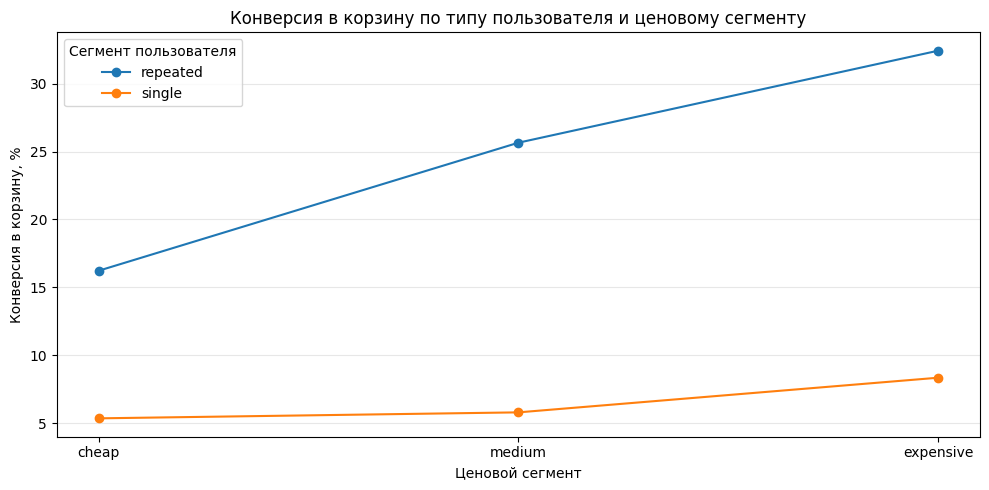

In [92]:
data = pd.read_csv('exports/Session_segment_per_Price_segment_conversion_to_cart.csv')

data['price_segment'] = pd.Categorical(data['price_segment'], categories=['cheap', 'medium', 'expensive'], ordered=True)

data = data.sort_values('price_segment')

plt.figure(figsize=(10, 5))

for segment, group in data.groupby('session_segment'):
    plt.plot(group['price_segment'], group['conversion_to_cart'], marker='o', label=segment)

plt.xlabel('Ценовой сегмент')
plt.ylabel('Конверсия в корзину, %')
plt.title('Конверсия в корзину по типу пользователя и ценовому сегменту')
plt.legend(title='Сегмент пользователя')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Низкая конверсия одноразовых пользователей не объясняется только ценовым сегментом товаров**. Даже при одинаковом уровне цен "repeated-пользователи" значительно чаще переходят от просмотра к добавлению в корзину. При этом влияние цены также сохраняется: **у обоих типов пользователей конверсия выше для более дорогих товаров**.

**Конверсия в корзину по категориям Appliances**

`appliances` входит в топ-6 категорий первого уровня по пользовательскому интересу и представляет третье по значимости место после двух явных лидеров — `computers` и `electronics`.   
В связи с этим дополнительно рассмотрим структуру `appliances`, чтобы определить, какие её конечные категории формируют основной вклад в низкую конверсию. Фокусируемся на категориях с более чем 1 000 уникальных пользователей, поскольку они сочетают существенный пользовательский охват с достаточным объёмом данных для интерпретации результатов.

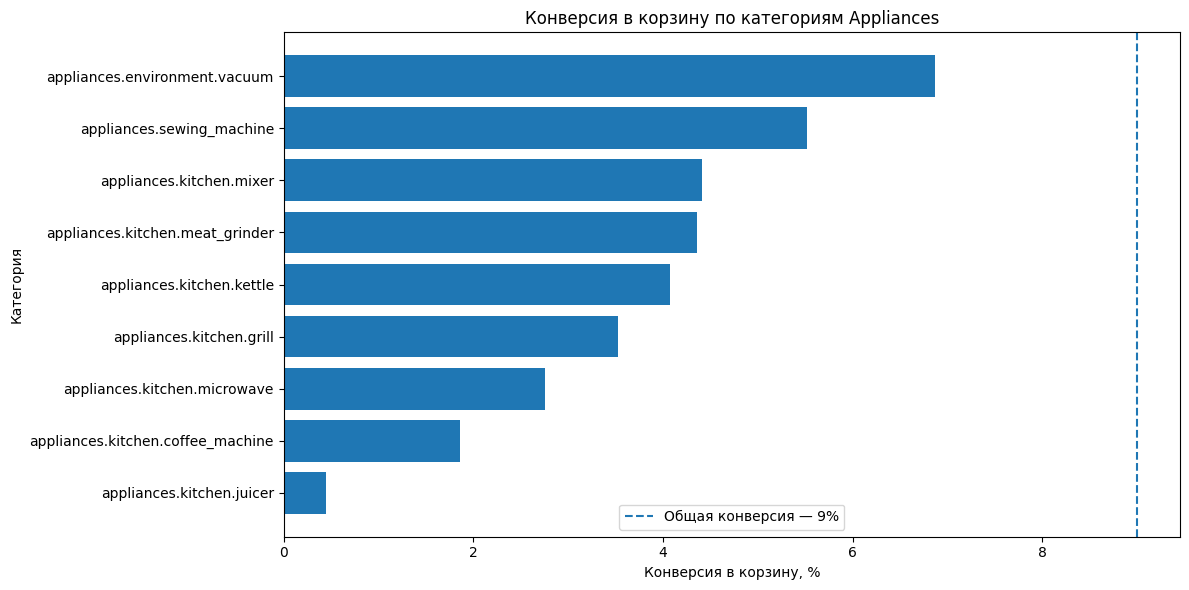

In [93]:
appliances = pd.read_csv('exports/Appliances_conversion_to_cart.csv')

appliances = appliances.sort_values('conversion_to_cart')

plt.figure(figsize=(12, 6))

plt.barh(appliances['category_code'], appliances['conversion_to_cart'])

plt.axvline(x=9, linestyle='--', label='Общая конверсия — 9%')

plt.xlabel('Конверсия в корзину, %')
plt.ylabel('Категория')
plt.title('Конверсия в корзину по категориям Appliances')

plt.legend()

plt.tight_layout()
plt.show()

Результаты показывают, что ни одна из рассматриваемых категорий **не достигает общей конверсии view → cart на уровне около 9%**.    
При этом ряд категорий сочетает значительный пользовательский интерес с особенно низкой конверсией:   
**`juicer` — 0.45%, `coffee_machine` — 1.86%, `microwave` — 2.76%, `grill` — 3.52%, `kettle` — 4.07%, `meat_grinder` — 4.36% и `mixer` - 4.41%**.

Таким образом, низкая конверсия `appliances` не является следствием отдельных малочисленных ниш: среди категорий с существенным пользовательским охватом также наблюдается систематическое отставание от общего уровня конверсии. Пользователи активно взаимодействуют с товарами данного направления, однако этот интерес значительно реже переходит в добавление товара в корзину. Это позволяет выделить отдельные категории `appliances` как потенциальные проблемные зоны, требующие дальнейшего анализа причин низкой конверсии.

**Сравнение категорий "телефоны" и "видеокарты"**

До анализа конверсии `electronics.telephone` и `computers.components.videocards` демонстрировали схожий уровень пользовательского интереса и занимали ведущие позиции по ключевым показателям активности. Кроме того, `electronics.telephone` обладала крупнейшим ассортиментом среди всех конечных категорий, что дополнительно выделяло её как одно из ключевых направлений магазина.

Однако при анализе **view → cart** обнаружился существенный разрыв: **видеокарты показали** максимальную среди отобранных категорий конверсию — **27.36%**, тогда как **телефоны** оказались практически в нижней части списка — **9.56%**. При сопоставимом уровне пользовательского интереса различие оказалось слишком значительным, чтобы его игнорировать.

Поэтому данные категории были выбраны для дополнительного сравнения с целью определить, сохраняется ли разрыв в конверсии при учёте других факторов, прежде всего ценового сегмента.

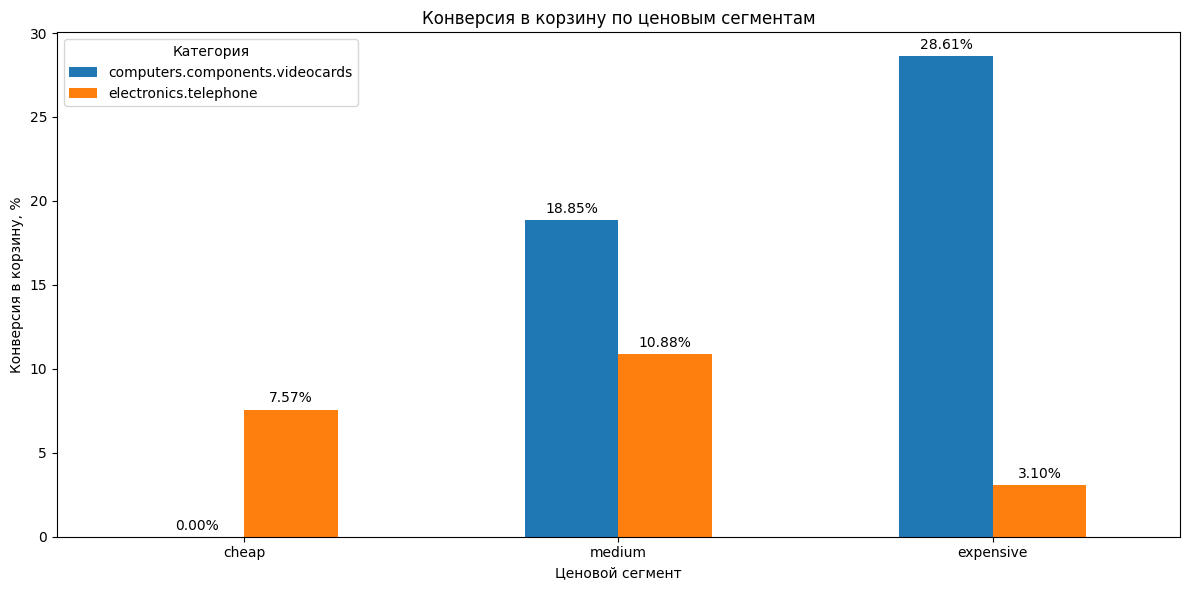

In [94]:
telephone_videocards = pd.read_csv('exports/Telephone_Videocards_conversion_to_cart.csv')

telephone_videocards['price_segment'] = pd.Categorical(
    telephone_videocards['price_segment'],
    categories=['cheap', 'medium', 'expensive'],
    ordered=True
)

ax = telephone_videocards.pivot(index='price_segment', columns='category_code', values='conversion_to_cart').plot(kind='bar', figsize=(12, 6))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.xlabel('Ценовой сегмент')
plt.ylabel('Конверсия в корзину, %')
plt.title('Конверсия в корзину по ценовым сегментам')
plt.legend(title='Категория')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Сравнение категорий внутри ценовых сегментов подтвердило существенный разрыв в конверсии **view → cart**. **В среднем ценовом сегменте** видеокарты конвертируются в корзину значительно чаще телефонов — **18.85% против 10.88%**. **В дорогом сегменте** разрыв становится ещё более выраженным: **28.61% против 3.10%**. При этом дешёвый ценовой сегмент у видеокарт полностью отсутствует, поэтому сравнение категорий в этой части невозможно.

Для видеокарт наблюдается последовательный рост конверсии с увеличением ценового сегмента: с 18.85% в среднем сегменте до 28.61% в дорогом. Это дополнительно подтверждает ранее обнаруженный паттерн: **с увеличением ценового сегмента конверсия в корзину также увеличивается**.

Телефоны демонстрируют принципиально иную динамику. После роста конверсии с 7.57% до 10.88% при переходе от дешёвого к среднему сегменту, в дорогом сегменте она резко снижается до 3.10%. **Именно дорогие телефоны формируют наиболее существенное отставание от видеокарт**.

Для телефонов выявлена потенциально проблемная зона: дорогие товары при значительном пользовательском интересе демонстрируют крайне низкую конверсию в корзину. **Поэтому следующим шагом необходимо изучить структуру дорогого сегмента телефонов**, в первую очередь распределение товаров по брендам, чтобы определить, какие из них формируют данное снижение конверсии.

**Конверсия в корзину дорогих товаров брендов смартфонов**

В выборку включены только бренды, набравшие более 100 уникальных просмотров пользователей.

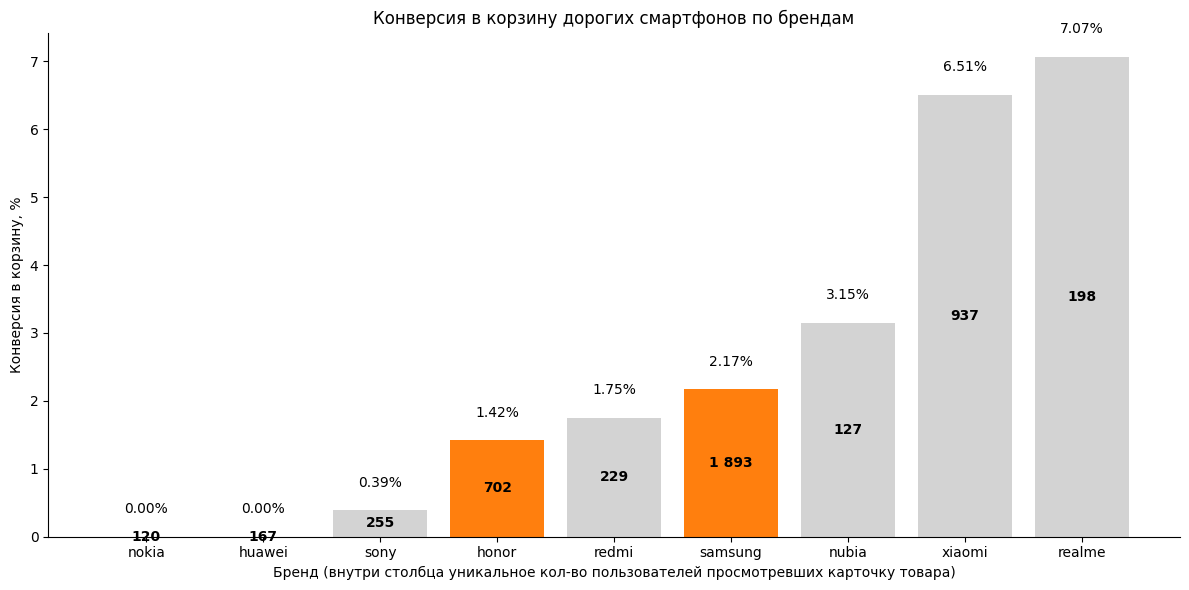

In [95]:
telephone_brand = pd.read_csv('exports/Telephone_per_brand_conversion_to_cart.csv')

telephone_brand = telephone_brand.sort_values('conversion_to_cart')

highlight = ['samsung', 'honor']

colors = ['tab:orange' if brand in highlight else 'lightgray' for brand in telephone_brand['brand']]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(telephone_brand['brand'], telephone_brand['conversion_to_cart'], color=colors)

for bar, views, conversion in zip(bars, telephone_brand['uniq_count_view'], telephone_brand['conversion_to_cart']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{views:,}'.replace(',', ' '),
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{conversion:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax.set_xlabel('Бренд (внутри столбца уникальное кол-во пользователей просмотревших карточку товара)')
ax.set_ylabel('Конверсия в корзину, %')
ax.set_title('Конверсия в корзину дорогих смартфонов по брендам')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Анализ дорогого сегмента показал низкую конверсию в корзину у большинства брендов**. Наиболее слабые результаты наблюдаются у `Nokia` и `Huawei` — **конверсия составляет 0%**, у `Sony` — **менее 0,5%**. Однако эти бренды имеют относительно небольшой объем пользовательского интереса и поэтому в меньшей степени определяют общий результат сегмента.

**Наибольшую значимость представляют `Honor` и `Samsung`**: при высоком объеме просмотров их дорогие товары конвертируются в корзину крайне слабо. Особенно важен `Samsung`, который одновременно является одним из ключевых флагманских брендов магазина и лидирует по числу уникальных пользователей, просматривающих дорогие смартфоны. **Следовательно, низкая конверсия `Samsung` потенциально формирует значимую часть потерь на данном этапе воронки**.

Поэтому далее необходимо оценить конверсию `Samsung` по ценовым сегментам, чтобы определить, локализована ли проблема в дорогом ассортименте или имеет системный характер для бренда.

**Конверсия в корзину товаров Samsung по ценовым сегментам**

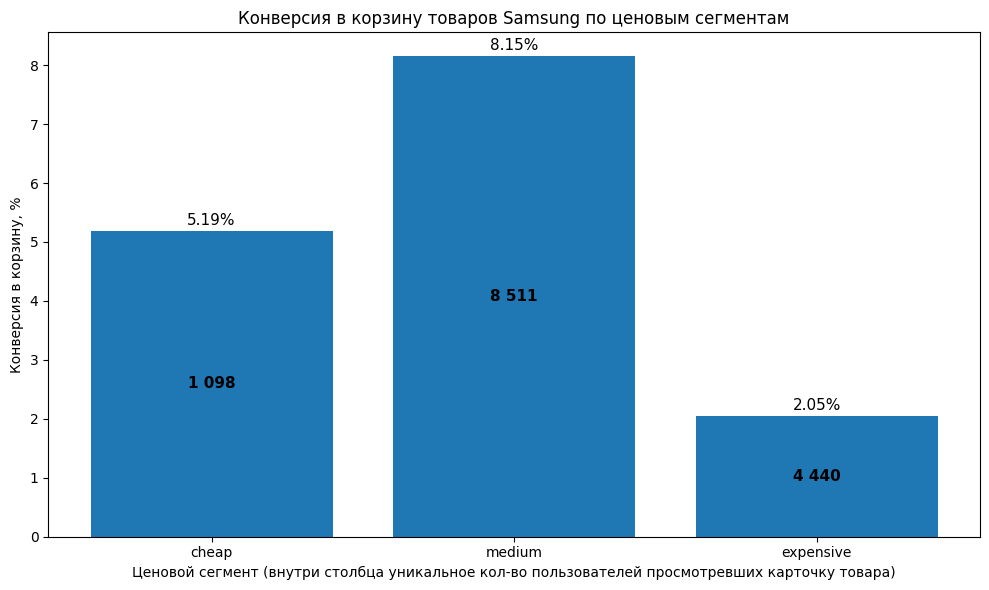

In [96]:
samsung_price = pd.read_csv('exports/Samsung_per_price_segment_conversion_to_cart.csv')

price_order = ['cheap', 'medium', 'expensive']

samsung_price['price_segment'] = pd.Categorical(samsung_price['price_segment'], categories=price_order, ordered=True)

samsung_price = samsung_price.sort_values('price_segment')

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(samsung_price['price_segment'], samsung_price['conversion_to_cart'])

for bar, views, conversion in zip(bars, samsung_price['uniq_count_view'], samsung_price['conversion_to_cart']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{views:,}'.replace(',', ' '),
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{conversion:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.set_xlabel('Ценовой сегмент (внутри столбца уникальное кол-во пользователей просмотревших карточку товара)')
ax.set_ylabel('Конверсия в корзину, %')
ax.set_title('Конверсия в корзину товаров Samsung по ценовым сегментам')


plt.tight_layout()
plt.show()

**Низкая конверсия не является системной характеристикой бренда `Samsung` и преимущественно локализована в его дорогом ассортименте**. При высоком пользовательском интересе товары данного сегмента конвертируются в корзину значительно хуже, чем товары в других ценовых сегментах. Для определения факторов, формирующих такое отклонение, требуется дополнительный анализ ассортимента дорогих товаров `Samsung`.

**Конверсия в корзину дорогих товаров `Samsung` по категориям**

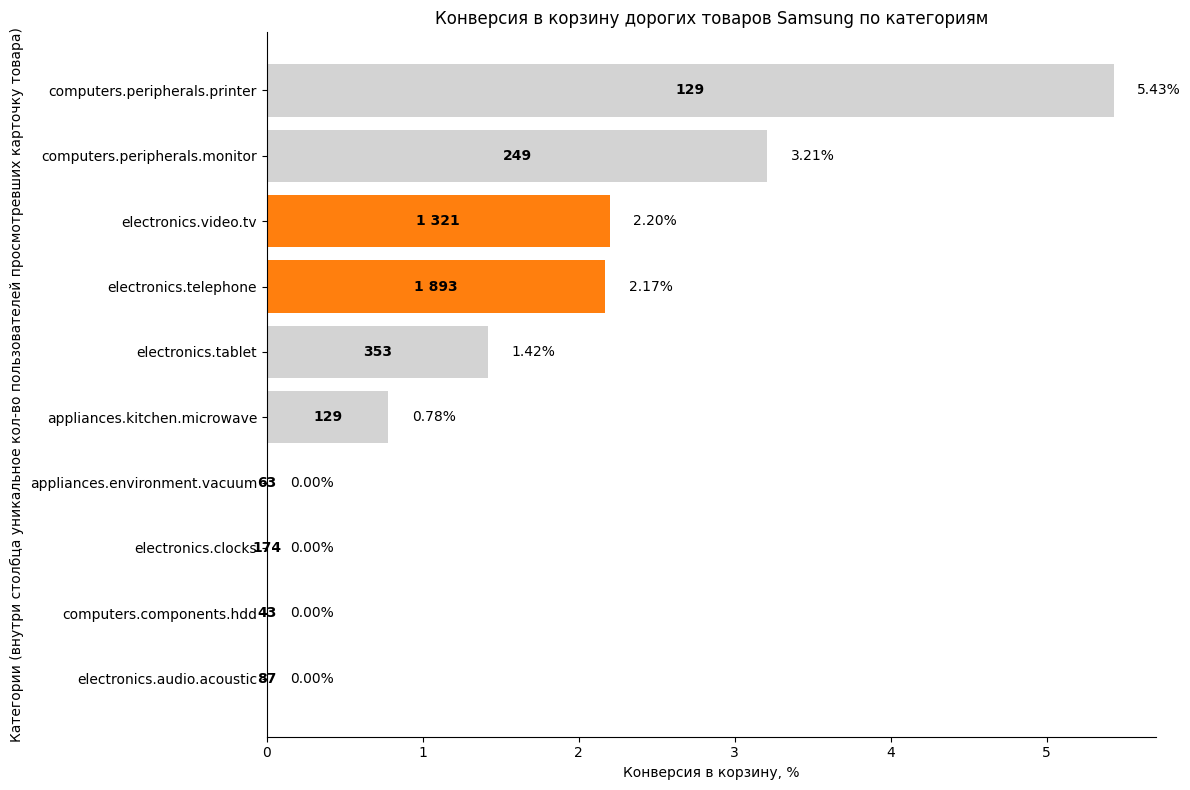

In [97]:
samsung_category = pd.read_csv('exports/Samsung_per_category_conversion_to_cart.csv')

samsung_category = samsung_category.sort_values('conversion_to_cart')

highlight = ['electronics.telephone', 'electronics.video.tv']

colors = ['tab:orange' if category in highlight else 'lightgray' for category in samsung_category['category_code']]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(samsung_category['category_code'], samsung_category['conversion_to_cart'], color=colors)

for bar, views, conversion in zip(bars, samsung_category['uniq_count_view'], samsung_category['conversion_to_cart']):
    ax.text(
        bar.get_width() / 2,
        bar.get_y() + bar.get_height() / 2,
        f'{views:,}'.replace(',', ' '),
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f'{conversion:.2f}%',
        ha='left',
        va='center',
        fontsize=10
    )

ax.set_xlabel('Конверсия в корзину, %')
ax.set_ylabel('Категории (внутри столбца уникальное кол-во пользователей просмотревших карточку товара)')
ax.set_title('Конверсия в корзину дорогих товаров Samsung по категориям')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Анализ дорогого ассортимента `Samsung` показывает низкую конверсию в корзину во всех представленных категориях, что указывает на системную проблему с конвертацией дорогих товаров бренда**.    
При этом наибольшего внимания требуют **телефоны** и **телевизоры**: именно эти категории сочетают низкую конверсию с высоким пользовательским интересом и, следовательно, формируют наиболее значимую потенциальную зону потерь. Высокий объем просмотров при слабом переходе в корзину указывает на то, что представленный ассортимент не в полной мере соответствует ожиданиям пользователей. <br><br>

### Основные результаты анализа продуктовой воронки

Анализ продуктовой воронки показал, что основная потеря пользователей происходит на этапе перехода от просмотра товара к добавлению в корзину: **конверсия View → Cart составляет 9,09%**, тогда как после добавления товара в корзину **вероятность завершения покупки значительно выше — 57,64%**. **Таким образом, основная зона потенциального роста находится не на этапе оформления покупки, а на более раннем этапе формирования намерения приобрести товар.**

**Поэтому дальнейший анализ был сфокусирован преимущественно на конверсии View → Cart.** Это было осознанным ограничением исследования: задача состояла не в полном разборе каждого этапа воронки, а в том, чтобы последовательно локализовать наиболее значимое место потери пользователей и определить факторы, с которыми оно связано. <br><br>

**Анализ разрезов показал, что конверсия существенно зависит от характеристик как товара, так и пользователя.** Между категориями первого уровня показатель варьируется от 4,19% до 14,79%, а среди отдельных категорий — от 9,56% до 27,36%. При этом ценовой сегмент демонстрирует выраженную закономерность: конверсия последовательно растет от 6,79% для дешевых товаров до 13,04% для дорогих. **Следовательно, высокая стоимость сама по себе не является очевидным барьером для добавления товара в корзину — напротив, дорогие товары в среднем конвертируются лучше.** <br><br>

**Отдельно выделяется категория `appliances`.** Несмотря на достаточный пользовательский интерес, она имеет одну из самых низких конверсий среди крупных категорий первого уровня — **4,19%**. Более детальный анализ показал, что это не результат отдельных малых ниш: среди категорий с существенным пользовательским охватом также наблюдаются показатели значительно ниже общего уровня. **Таким образом, `appliances` можно выделить как самостоятельную проблемную зону, требующую дальнейшего изучения.** <br><br>

**Наиболее выраженные различия обнаружены между сегментами пользователей.** Повторные пользователи конвертируются из просмотра в корзину в 4,6 раза лучше одноразовых — 28,44% против 6,23%. При этом разница сохраняется внутри каждого ценового сегмента, то есть низкая конверсия одноразовых пользователей не объясняется только стоимостью товаров. Это указывает на наличие отдельного поведенческого фактора, связанного с готовностью пользователя возвращаться и продолжать взаимодействие с магазином. **Данный аспект требует дальнейшего изучения — в частности, анализа того, что именно заставляет пользователя возвращаться и как повторное взаимодействие связано с последующей покупкой.** <br><br>

**На уровне категорий особенно заметен контраст между `electronics.telephone` и `computers.components.videocards`.** При сопоставимом пользовательском интересе видеокарты конвертируются значительно лучше телефонов: 27,36% против 9,56%. При контроле ценового сегмента различие сохраняется и становится особенно выраженным в дорогом сегменте — 28,61% против 3,10%. При этом телефоны нарушают общую закономерность роста конверсии с увеличением цены: после роста показателя в среднем сегменте до 10,88% конверсия дорогих товаров резко снижается до 3,10%. **Это позволило локализовать одну из наиболее выраженных проблем воронки именно в дорогом ассортименте смартфонов.** <br><br>

**Дальнейший анализ показал, что значительная часть этой проблемы связана с отдельными брендами.** Особенно выделяется `Samsung` — один из ключевых брендов магазина, входящий в топ-3 по просмотрам карточек товаров, занимающий первое место по широте ассортимента и лидирующий по количеству уникальных пользователей, просматривающих его товары. **При таком масштабе пользовательского взаимодействия его низкая конверсия представляет значительно больший интерес, чем аналогичные показатели небольших брендов.** <br><br>

**При этом проблема `Samsung` не является системной для бренда в целом.** Его конверсия составляет 5,19% в дешевом, 8,15% в среднем и лишь 2,05% в дорогом сегменте, что позволяет локализовать проблему преимущественно в дорогом ассортименте. Дополнительный анализ показал, что низкая конверсия характерна для всех крупных категорий дорогих товаров `Samsung`, **однако наиболее значимыми являются телефоны и телевизоры**: именно они сочетают высокий пользовательский интерес **с конверсией около 2%**. **Таким образом, дальнейшее углубление анализа следует направлять не на бренд `Samsung` в целом, а на состав и характеристики его дорогого ассортимента в наиболее востребованных категориях.** <br><br>

**В результате анализ потерь пользователей позволил перейти от общей проблемы низкой конверсии к нескольким конкретным зонам для дальнейшего исследования: категория `appliances`, поведение одноразовых и повторных пользователей, а также дорогой ассортимент `Samsung`, прежде всего телефоны и телевизоры.** При этом полученные результаты следует рассматривать как локализацию проблемных зон, а не как доказательство их причин. Для перехода от выявленных закономерностей к продуктовым гипотезам потребуется более глубокий анализ доступных характеристик товаров и пользовательского поведения. Ограниченность данных на уровне отдельных товаров также не позволяет провести полноценный ассортиментный анализ, поэтому дальнейшие выводы должны опираться на те признаки, которые действительно присутствуют в датасете. <br><br>

### 3.3 Анализ монетизации продукта и когортный анализ

**`Revenue`**

**Динамика выручки по месяцам**

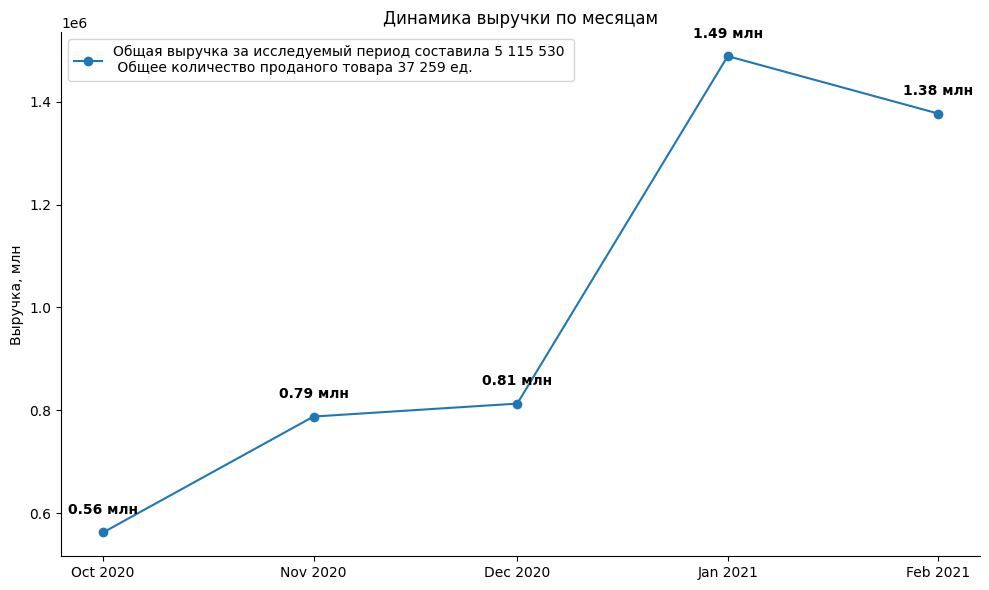

In [98]:
revenue = pd.read_csv('exports/Revenue.csv')

revenue['month_'] = pd.to_datetime(revenue['month_'])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(revenue['month_'], revenue['revenue'], marker='o', 
        label='Общая выручка за исследуемый период составила 5 115 530 \n Общее количество проданого товара 37 259 ед.')

for x, y in zip(revenue['month_'], revenue['revenue']):
    ax.text(
        x,
        y + revenue['revenue'].max() * 0.02,
        f'{y / 1_000_000:.2f} млн',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

ax.set_xlabel('')
ax.set_ylabel('Выручка, млн')
ax.set_title('Динамика выручки по месяцам')

ax.set_xticks(revenue['month_'])
ax.set_xticklabels(revenue['month_'].dt.strftime('%b %Y'))

plt.legend(loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Динамика выручки существенно отличается от динамики MAU**

Несмотря на максимальный уровень пользовательской активности в ноябре, наибольшее значение выручки достигает значительно позже — в январе. При этом с октября по декабрь выручка последовательно увеличивается, а в январе происходит резкий скачок с **562,6 тыс. до 1,49 млн**, то есть более чем в 2,6 раза. В феврале наблюдается небольшое снижение относительно январского пика, однако выручка сохраняется на существенно более высоком уровне, чем в начале исследуемого периода.

Таким образом, рост выручки не объясняется исключительно увеличением числа активных пользователей или сезонным всплеском активности в период новогодних праздников. При сопоставимом размере пользовательской базы январская выручка оказалась более чем в **2,6 раза выше**, что указывает на существенные изменения в покупательском поведении и требует дальнейшего анализа факторов.

**Для оценки причин такого расхождения сравним октябрь и январь** — месяцы с сопоставимым количеством активных пользователей (**84 204 и 81 248 соответственно**), но существенно различающейся выручкой (**562,6 тыс. и 1,49 млн**). Такое сравнение позволяет исключить простое увеличение размера активной пользовательской базы как основное объяснение роста выручки и сосредоточиться на изменениях в структуре покупок и денежной ценности пользователей.

**Выручка по категориям 1 уровня: `октябрь` vs `январь`**

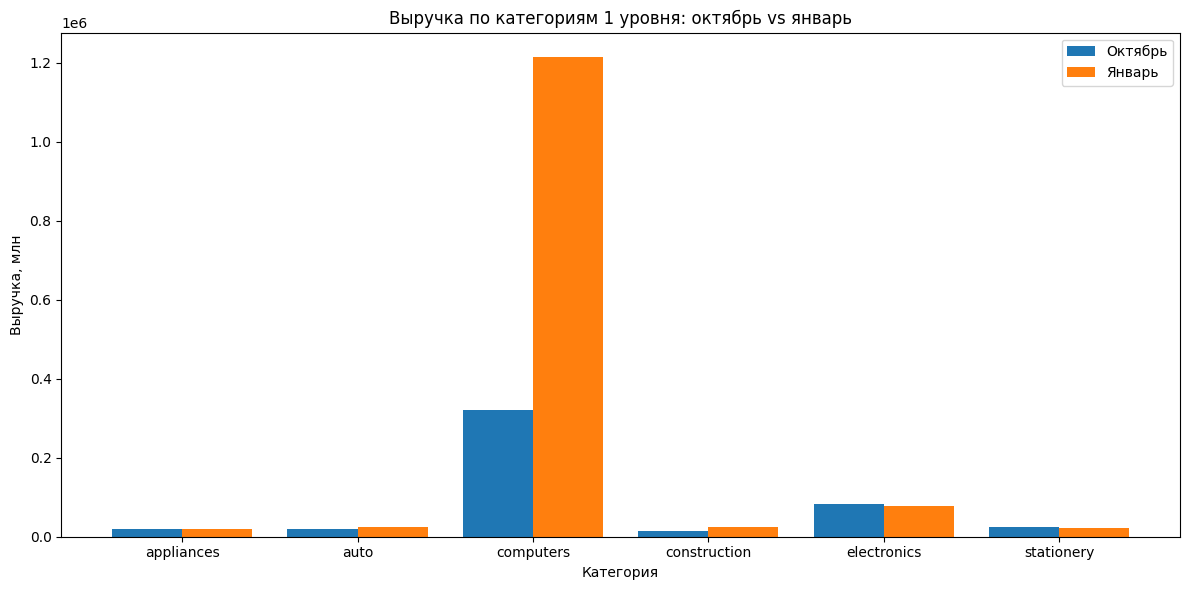

In [99]:
revenue_df = pd.read_csv('exports/Revenue_per_category_lvl_1.csv')

revenue_df['month_'] = pd.to_datetime(revenue_df['month_'])

revenue_pivot = revenue_df.pivot(index='category_lvl_1', columns='month_', values='revenue')

x = np.arange(len(revenue_pivot))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    revenue_pivot[pd.Timestamp('2020-10-01')],
    width,
    label='Октябрь'
)

plt.bar(
    x + width / 2,
    revenue_pivot[pd.Timestamp('2021-01-01')],
    width,
    label='Январь'
)

plt.xticks(x, revenue_pivot.index, rotation=0)
plt.xlabel('Категория')
plt.ylabel('Выручка, млн')
plt.title('Выручка по категориям 1 уровня: октябрь vs январь')
plt.legend()

plt.tight_layout()
plt.show()

**В январе `компьютеры` стали ключевым драйвером роста выручки**: выручка категории значительно превысила октябрьский уровень и обеспечила резкий рост общей выручки.

**Выручка по категории `computers.components.videocards`: `октябрь` vs `январь`**

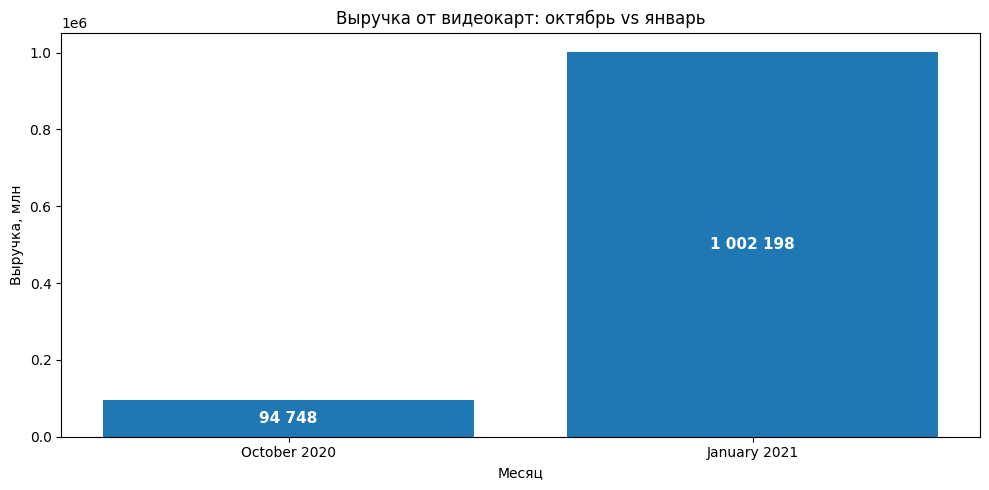

In [100]:
revenue_df = pd.read_csv('exports/Revenue_videocards.csv')

revenue_df['month_'] = pd.to_datetime(revenue_df['month_'])

revenue_df['month_label'] = revenue_df['month_'].dt.strftime('%B %Y')


plt.figure(figsize=(10, 5))

bars = plt.bar(revenue_df['month_label'], revenue_df['revenue'])

labels = [f'{x:,.0f}'.replace(',', ' ') for x in revenue_df['revenue']]

plt.bar_label(
    bars,
    labels=labels,
    label_type='center',
    color='white',
    fontsize=11,
    fontweight='bold'
)

plt.title('Выручка от видеокарт: октябрь vs январь')
plt.xlabel('Месяц')
plt.ylabel('Выручка, млн')

plt.tight_layout()
plt.show()

**В январе основной вклад в выручку категории компьютеров обеспечили видеокарты**: их выручка выросла более чем в 10 раз по сравнению с октябрём. Поэтому следующим шагом стоит изучить бренды видеокарт, чтобы определить, какие из них сформировали этот рост.

**Выручка брендов видеокарт: `октябрь` vs `январь`**

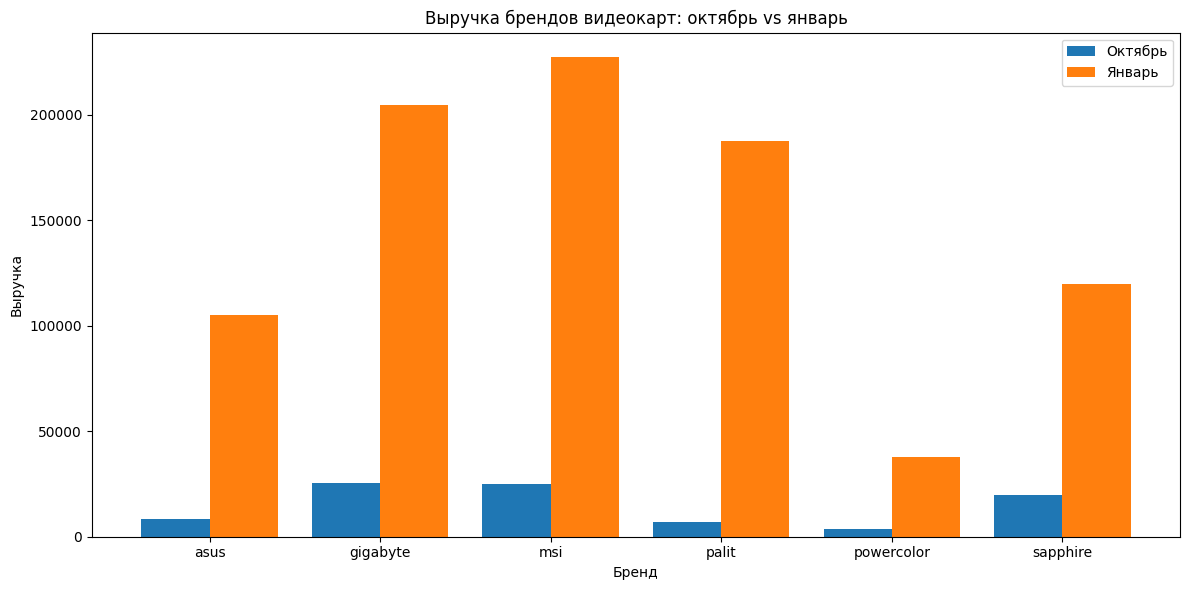

In [101]:
revenue_df = pd.read_csv('exports/Revenue_videocards_brands.csv')

revenue_df['month_'] = pd.to_datetime(revenue_df['month_'])

revenue_pivot = revenue_df.pivot(index='brand', columns='month_', values='revenue')

x = np.arange(len(revenue_pivot))
width = 0.4

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    revenue_pivot[pd.Timestamp('2020-10-01')],
    width,
    label='Октябрь'
)

plt.bar(
    x + width / 2,
    revenue_pivot[pd.Timestamp('2021-01-01')],
    width,
    label='Январь'
)

plt.xticks(x, revenue_pivot.index, rotation=0)
plt.xlabel('Бренд')
plt.ylabel('Выручка')
plt.title('Выручка брендов видеокарт: октябрь vs январь')
plt.legend()

plt.tight_layout()
plt.show()

**Январский рост выручки видеокарт не связан с одним доминирующим брендом: все представленные бренды заметно нарастили выручку, что указывает на общий рост спроса на категорию.**
* `Palit` показал самый резкий относительный рост — с 7,1 тыс. до 187,3 тыс. (+2 534%)
* `MSI` обеспечил наибольший абсолютный прирост выручки — +202,5 тыс., достигнув 227,5 тыс. в январе.

**Распределение пользователей по количеству покупок видеокарт в январе**

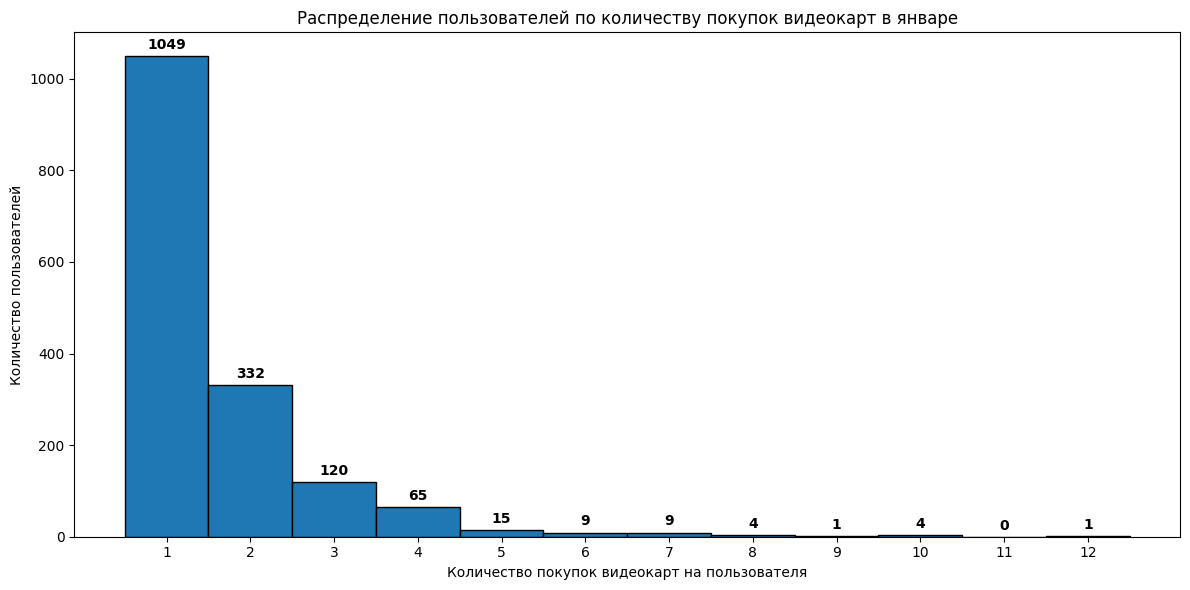

In [102]:
buy_df = pd.read_csv('exports/Hist_of_users_buy_viedocart_jan.csv')

plt.figure(figsize=(12, 6))

counts, bins, bars = plt.hist(buy_df['count_buy_per_users'],
    bins=range(buy_df['count_buy_per_users'].min(), buy_df['count_buy_per_users'].max() + 2),
    edgecolor='black', align='left')

plt.bar_label(bars, labels=[f'{int(count)}' for count in counts], padding=3, fontweight='bold')

plt.xlabel('Количество покупок видеокарт на пользователя')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по количеству покупок видеокарт в январе')

plt.xticks(range(buy_df['count_buy_per_users'].min(), buy_df['count_buy_per_users'].max() + 1))

plt.tight_layout()
plt.show()

**В январе видеокарты стали массово востребованы среди покупателей: основной объём покупок сформировали пользователи с небольшим количеством приобретений, а не отдельные крупные заказы.** При этом встречались и покупатели, приобретавшие сразу по несколько видеокарт, что может быть связано с оптовыми закупками. Таким образом, магазин столкнулся не с единичным крупным заказом, а с резким ростом общего спроса на категорию. Такой всплеск может стать отдельной точкой для более глубокого анализа и поиска возможностей для дальнейшего роста продаж.

**Выручка по типу активности пользователей**

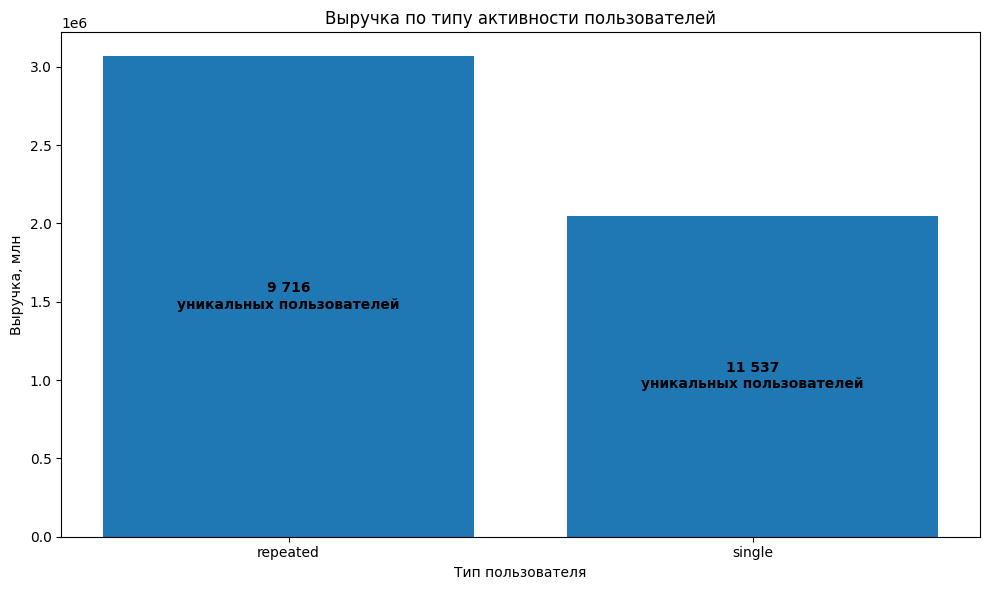

In [103]:
revenue_df = pd.read_csv('exports/Revenue_per_session_segment.csv')

plt.figure(figsize=(10, 6))

bars = plt.bar(revenue_df['activ_users'], revenue_df['revenue'])

plt.xlabel('Тип пользователя')
plt.ylabel('Выручка, млн')
plt.title('Выручка по типу активности пользователей')

for bar, users in zip(bars, revenue_df['count_users']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{int(users):,}'.replace(',', ' ') + '\nуникальных пользователей',
        ha='center',
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Несмотря на меньшее количество уникальных пользователей, повторные клиенты генерируют более высокую выручку, чем одноразовые.**   
За исследуемый период разница в выручке составила около 1 млн в пользу повторных клиентов, что подтверждает их более высокую коммерческую ценность для магазина.

**Выручка по ценовым сегментам**

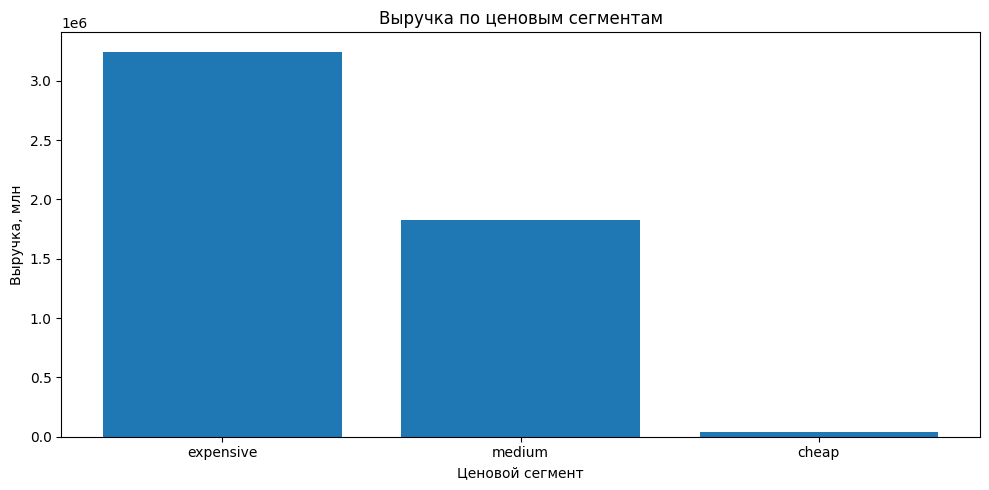

In [104]:
revenue_df = pd.read_csv('exports/Revenue_per_price_segment.csv')

plt.figure(figsize=(10, 5))

bars = plt.bar(revenue_df['price_segment'], revenue_df['revenue'])

plt.xlabel('Ценовой сегмент')
plt.ylabel('Выручка, млн')
plt.title('Выручка по ценовым сегментам')

plt.tight_layout()
plt.show()

Основную выручку магазину приносят **дорогие товары — 3,25 млн**, тогда как **средний ценовой сегмент сформировал 1,83 млн**. **Дешёвые товары** практически не влияют на итоговую выручку — **всего 40 тыс.** за исследуемый период.    
**Таким образом, рост выручки в первую очередь связан с продажами товаров среднего и высокого ценового сегмента.**

**Вклад категорий 1 уровня в общую выручку за исследуемый период**

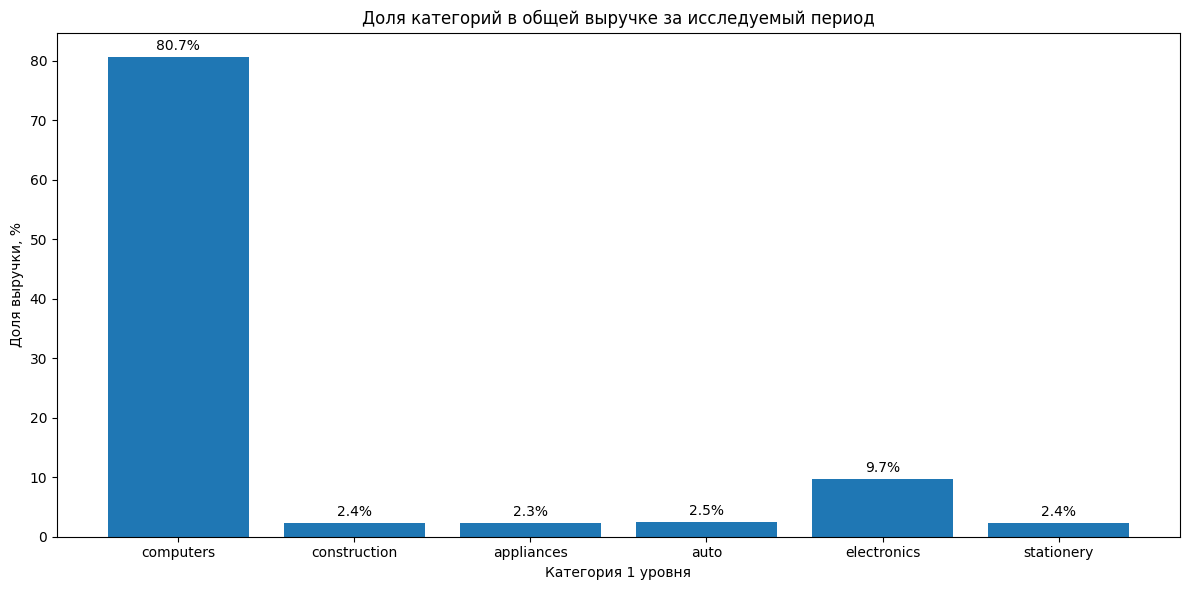

In [105]:
revenue_df = pd.read_csv('exports/Items_and_arppu_per_category.csv')

revenue_df['revenue_share'] = (revenue_df['revenue'] / revenue_df['revenue'].sum() * 100)

plt.figure(figsize=(12, 6))

bars = plt.bar(revenue_df['category_lvl_1'], revenue_df['revenue_share'])

for bar in bars:
    y = bar.get_height()
    plt.annotate(
        f'{y:.1f}%',
        (bar.get_x() + bar.get_width() / 2, y),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center'
    )

plt.title('Доля категорий в общей выручке за исследуемый период')
plt.xlabel('Категория 1 уровня')
plt.ylabel('Доля выручки, %')

plt.tight_layout()
plt.show()

Большую часть выручки **(80.7%)** магазину приносит категория `computers`, которая в большей степени состоит из выручки от конечной внутренней категории `computers.components.videocards`.

**`ARPU` / `ARPPU`**

**Динамика ARPU/ARPPU и доли покупателей**

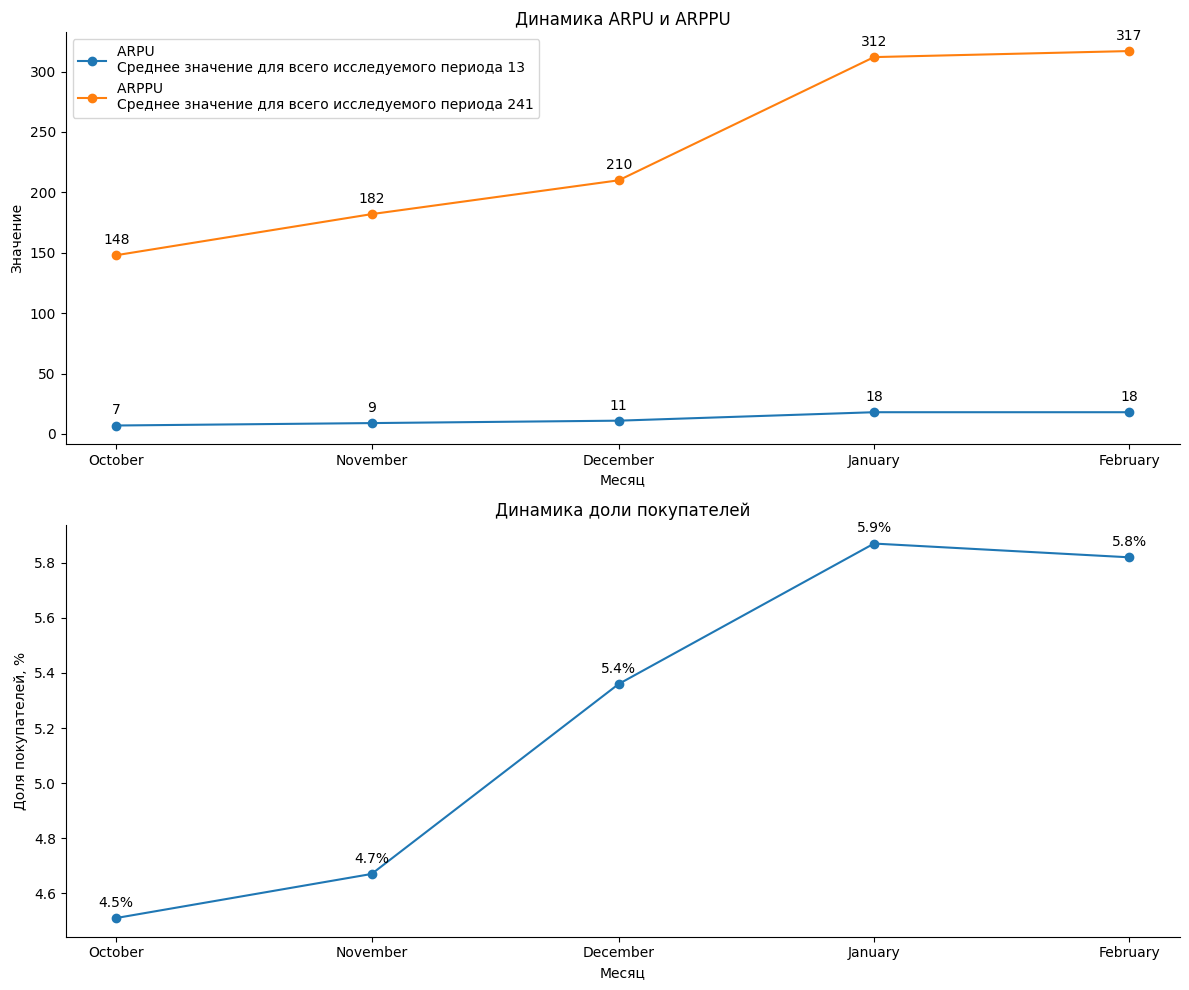

In [106]:
arpu_df = pd.read_csv('exports/ARPU_ARPPU_per_month.csv')

arpu_df['month_'] = pd.to_datetime(arpu_df['month_'])

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# ARPU и ARPPU

axes[0].plot(arpu_df['month_'], arpu_df['arpu'], marker='o', label='ARPU \nСреднее значение для всего исследуемого периода 13')

axes[0].plot(arpu_df['month_'], arpu_df['arppu'], marker='o', label='ARPPU \nСреднее значение для всего исследуемого периода 241')

for x, y in zip(arpu_df['month_'], arpu_df['arpu']):
    axes[0].annotate(
        f'{y:.0f}',
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center'
    )

for x, y in zip(arpu_df['month_'], arpu_df['arppu']):
    axes[0].annotate(
        f'{y:.0f}',
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center'
    )

axes[0].set_title('Динамика ARPU и ARPPU')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Значение')
axes[0].legend()

months = arpu_df['month_'].dt.strftime('%B')
axes[0].set_xticks(arpu_df['month_'])
axes[0].set_xticklabels(months, rotation=0)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Доля покупателей

axes[1].plot(arpu_df['month_'], arpu_df['share_users'], marker='o')

for x, y in zip(arpu_df['month_'], arpu_df['share_users']):
    axes[1].annotate(
        f'{y:.1f}%',
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
    )

axes[1].set_title('Динамика доли покупателей')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Доля покупателей, %')

axes[1].set_xticks(arpu_df['month_'])
axes[1].set_xticklabels(months, rotation=0)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Особенно показательно сравнение ноября–декабря и декабря–января: при сопоставимом приросте доли покупателей выручка в январе выросла почти вдвое, тогда как в декабре практически не изменилась. При этом ноябрь характеризовался максимальным уровнем пользовательской активности за весь период, однако это не привело к сопоставимому росту ни доли покупателей, ни выручки.    
**Таким образом, сама по себе высокая активность пользователей не гарантирует рост монетизации — ключевую роль играет то, сколько и какие товары они покупают.** В январе существенный вклад в рост выручки внесла высокая активность в категории видеокарт.

**Среднее количество товаров и средння выручка на одного покупателя категории**

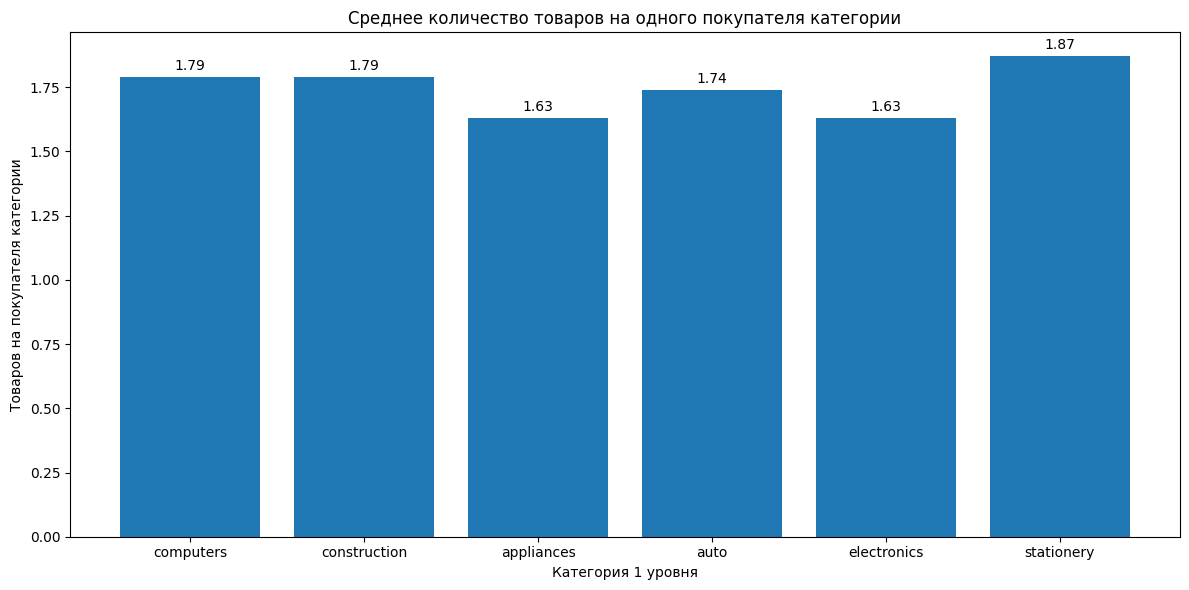

In [107]:
items_df = pd.read_csv('exports/Items_and_arppu_per_category.csv')

plt.figure(figsize=(12, 6))

bars = plt.bar(items_df['category_lvl_1'], items_df['items_per_user'])

for bar in bars:
    y = bar.get_height()
    plt.annotate(
        f'{y:.2f}',
        (bar.get_x() + bar.get_width() / 2, y),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center'
    )

plt.title('Среднее количество товаров на одного покупателя категории')
plt.xlabel('Категория 1 уровня')
plt.ylabel('Товаров на покупателя категории')

plt.tight_layout()
plt.show()

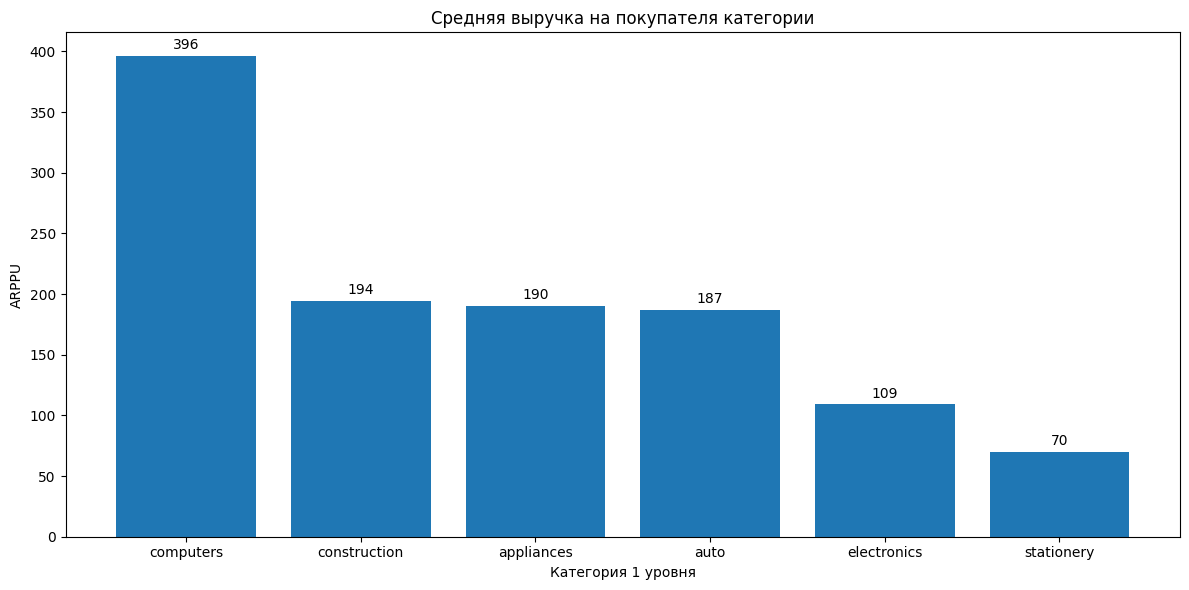

In [108]:
arppu_df = pd.read_csv('exports/Items_and_arppu_per_category.csv')

plt.figure(figsize=(12, 6))

bars = plt.bar(arppu_df['category_lvl_1'], arppu_df['arppu'])

for bar in bars:
    y = bar.get_height()
    plt.annotate(
        f'{y:.0f}',
        (bar.get_x() + bar.get_width() / 2, y),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center'
    )

plt.title('Средняя выручка на покупателя категории')
plt.xlabel('Категория 1 уровня')
plt.ylabel('ARPPU')

plt.tight_layout()
plt.show()

Количество покупаемых товаров на одного покупателя слабо различается между категориями — от 1,63 до 1,87 товара.    
При этом ARPPU варьируется значительно сильнее: от 70 в `stationery` до 396 в `computers`.    
**Это показывает, что при сопоставимом количестве приобретаемых товаров на одного покупателя различия в выручке на одного покупателя определяются прежде всего стоимостью товаров в категории и общим количеством проданных единиц.**

**Количество проданных единиц товара по категориям**

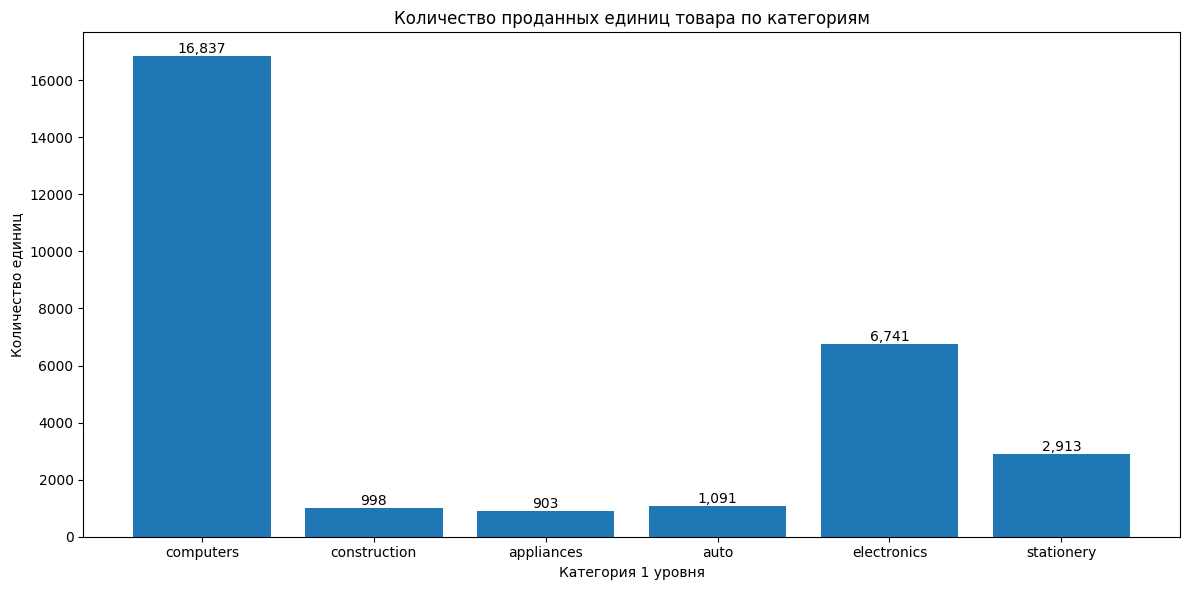

In [109]:
category_items_df = pd.read_csv('exports/Items_and_arppu_per_category.csv')

plt.figure(figsize=(12, 6))

bars = plt.bar(category_items_df['category_lvl_1'], category_items_df['count_items'])

plt.title('Количество проданных единиц товара по категориям')
plt.xlabel('Категория 1 уровня')
plt.ylabel('Количество единиц')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

`Computers` существенно доминирует по количеству проданных единиц — 16,8 тыс. товаров против 6,7 тыс. у второй по объёму категории `electronics`. Остальные категории формируют значительно меньший объём продаж, что подчёркивает ключевую роль `computers` в общем количестве покупок.

**Структура продаж и выручки по ценовым сегментам**

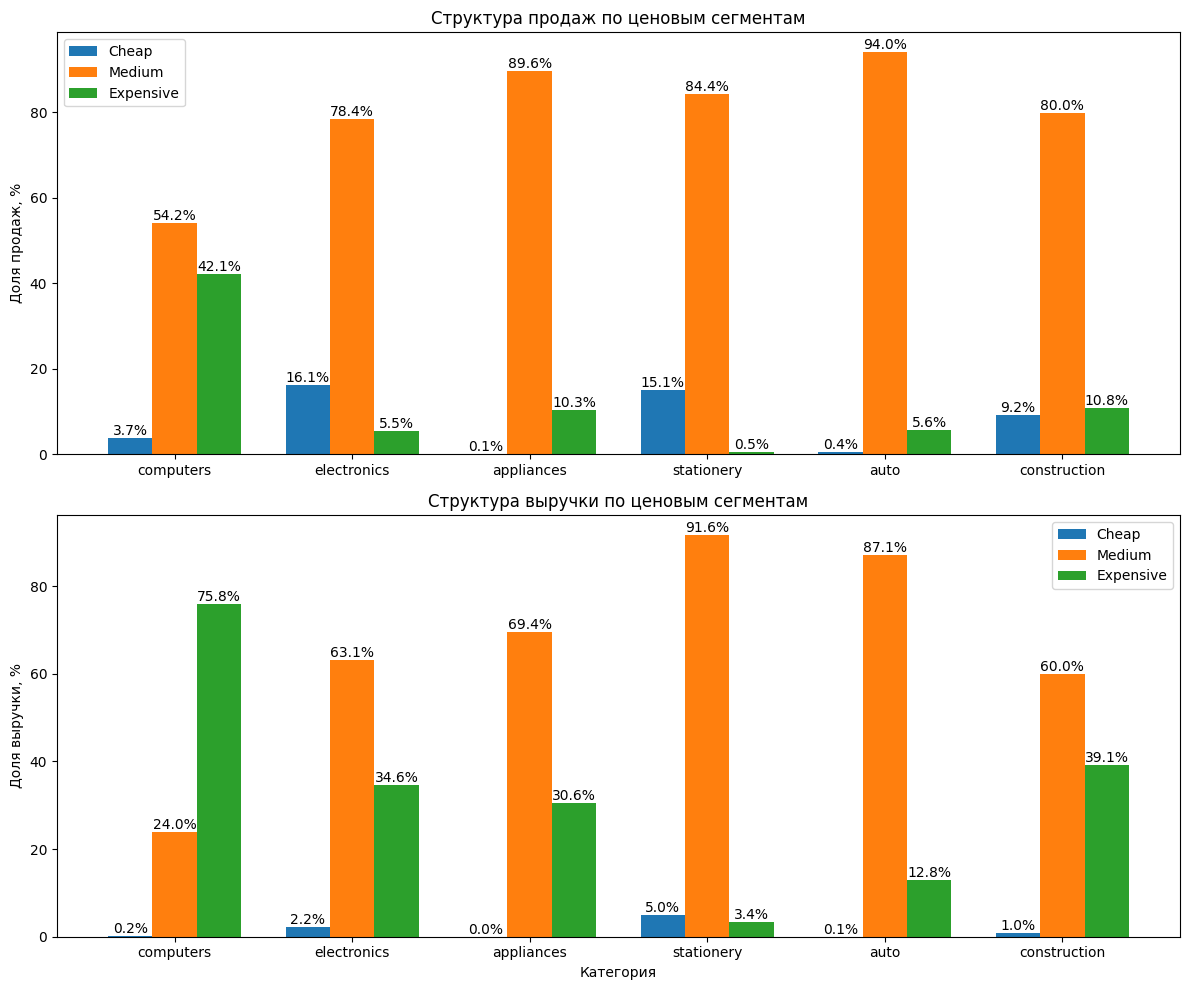

In [110]:
category_price_df = pd.read_csv('exports/Category_vs_price_segment.csv')

# Порядок ценовых сегментов
segment_order = ['cheap', 'medium', 'expensive']

# Порядок категорий
category_order = ['computers', 'electronics', 'appliances', 'stationery', 'auto', 'construction']

share_sell_pivot = category_price_df.pivot(
    index='category_lvl_1',
    columns='price_segment',
    values='share_sell'
).reindex(category_order)[segment_order]

share_revenue_pivot = category_price_df.pivot(
    index='category_lvl_1',
    columns='price_segment',
    values='share_revenue'
).reindex(category_order)[segment_order]

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

x = np.arange(len(category_order))
width = 0.25

# Один и тот же цвет для каждого сегмента на обоих графиках
colors = {
    'cheap': 'tab:blue',
    'medium': 'tab:orange',
    'expensive': 'tab:green'
}

# Доля продаж

for i, segment in enumerate(segment_order):
    bars = axes[0].bar(
        x + (i - 1) * width,
        share_sell_pivot[segment],
        width,
        label=segment.capitalize(),
        color=colors[segment]
    )

    for bar in bars:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{bar.get_height():.1f}%',
            ha='center',
            va='bottom'
        )

axes[0].set_title('Структура продаж по ценовым сегментам')
axes[0].set_ylabel('Доля продаж, %')
axes[0].set_xticks(x)
axes[0].set_xticklabels(category_order)
axes[0].legend()

# Доля выручки

for i, segment in enumerate(segment_order):
    bars = axes[1].bar(
        x + (i - 1) * width,
        share_revenue_pivot[segment],
        width,
        label=segment.capitalize(),
        color=colors[segment]
    )

    for bar in bars:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{bar.get_height():.1f}%',
            ha='center',
            va='bottom'
        )

axes[1].set_title('Структура выручки по ценовым сегментам')
axes[1].set_xlabel('Категория')
axes[1].set_ylabel('Доля выручки, %')
axes[1].set_xticks(x)
axes[1].set_xticklabels(category_order)
axes[1].legend()

plt.tight_layout()
plt.show()

Средний ценовой сегмент формирует основную долю продаж во всех категориях, тогда как доли дешёвых и дорогих товаров существенно различаются: в одних категориях они сопоставимы, в других один из сегментов практически отсутствует. При этом структура выручки заметно отличается от структуры продаж: дорогой сегмент во всех категориях формирует большую долю выручки, чем его доля в количестве проданных товаров — от 1,8 раза в `computers` до 6,6 раза в `stationery`.

**Таким образом, несмотря на то что средний ценовой сегмент является основой объёма продаж, именно дорогие товары оказывают непропорционально сильное влияние на денежный результат категорий. Это наблюдение особенно показательно с учётом асимметричного разбиения ценовых сегментов `(25% / 65% / 10%)`, где дорогие товары составляют лишь верхние `10%` ценового распределения.**

**`AOV`**

**Динамика AOV по месяцам**

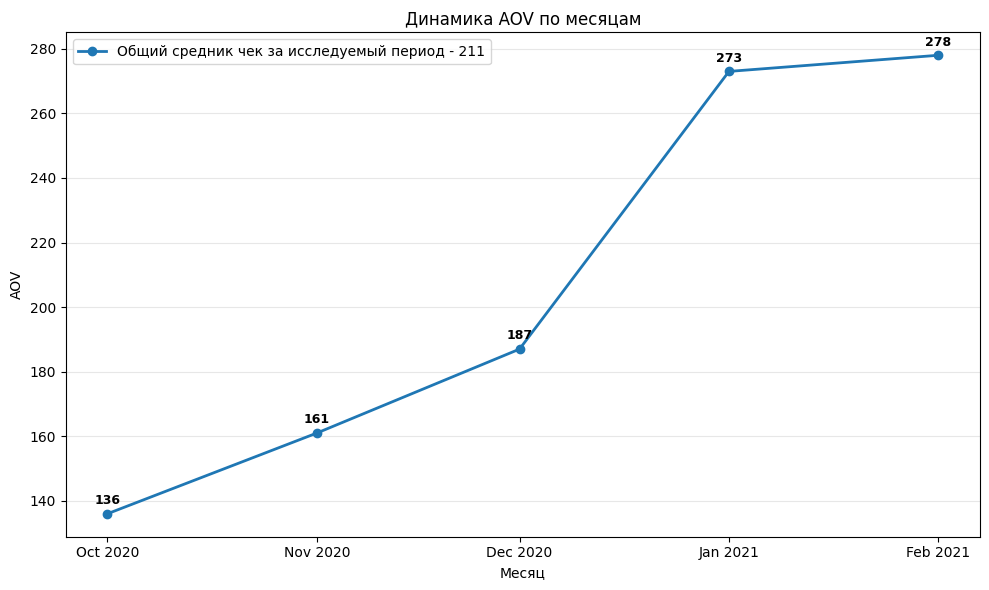

In [111]:
aov_df = pd.read_csv('exports/AOV.csv')

aov_df['month_'] = pd.to_datetime(aov_df['month_'])

plt.figure(figsize=(10, 6))

plt.plot(aov_df['month_'], aov_df['aov'], marker='o', linewidth=2, label='Общий средник чек за исследуемый период - 211')

for x, y in zip(aov_df['month_'], aov_df['aov']):
    plt.annotate(
        f'{y:,.0f}',
        (x, y),
        xytext=(0, 7),
        textcoords='offset points',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Динамика AOV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('AOV')

plt.xticks(aov_df['month_'], aov_df['month_'].dt.strftime('%b %Y'), rotation=0)

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Динамика AOV практически повторяет динамику общей выручки**: показатель последовательно растёт с октября по февраль — с 136 до 278. При этом наиболее заметное ускорение приходится на январь, когда AOV увеличивается с 187 до 273. Это указывает на то, что рост выручки в этот период был связан не только с объёмом продаж, но и с увеличением средней стоимости заказа.

**AOV по категориям 1 уровня**

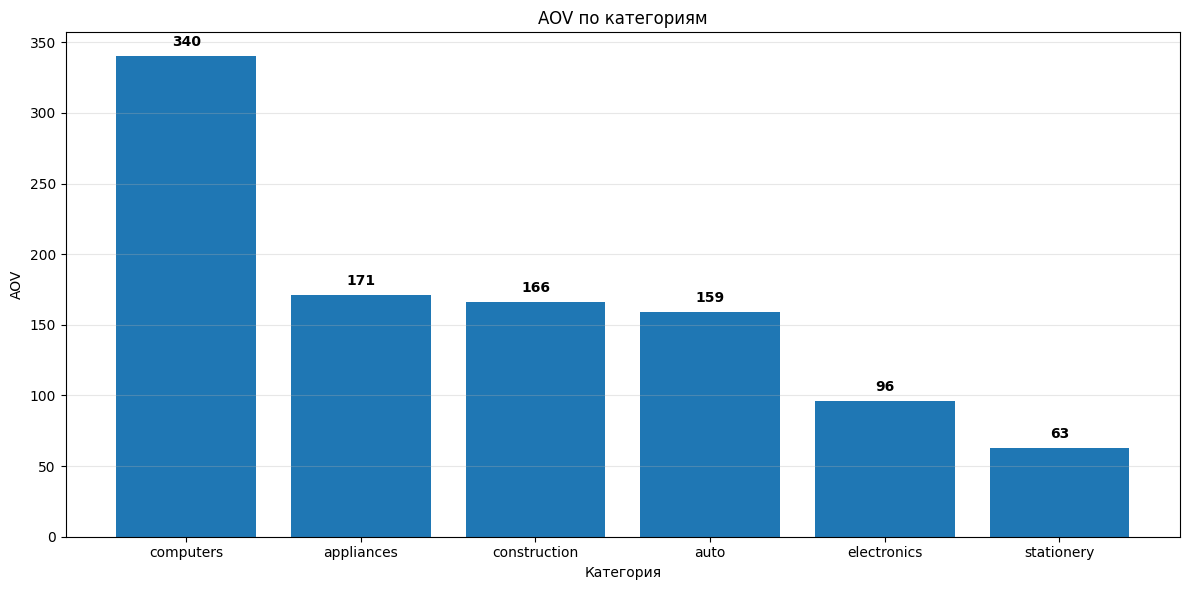

In [112]:
aov_category_df = pd.read_csv('exports/AOV_per_category.csv')

aov_category_df = aov_category_df.sort_values('aov', ascending=False)

plt.figure(figsize=(12, 6))

bars = plt.bar(aov_category_df['category_lvl_1'], aov_category_df['aov'])

for bar, value in zip(bars, aov_category_df['aov']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('AOV по категориям')
plt.xlabel('Категория')
plt.ylabel('AOV')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Распределение AOV по категориям практически полностью совпадает с ARPPU**: `computer` имеют максимальный показатель (340), а `stationery` — минимальный (63). При этом AOV во всех категориях немного ниже ARPPU, что ожидаемо, поскольку ARPPU рассчитывается на одного покупателя, а AOV — на одну покупательскую сессию.

**AOV по типу активности пользователя**

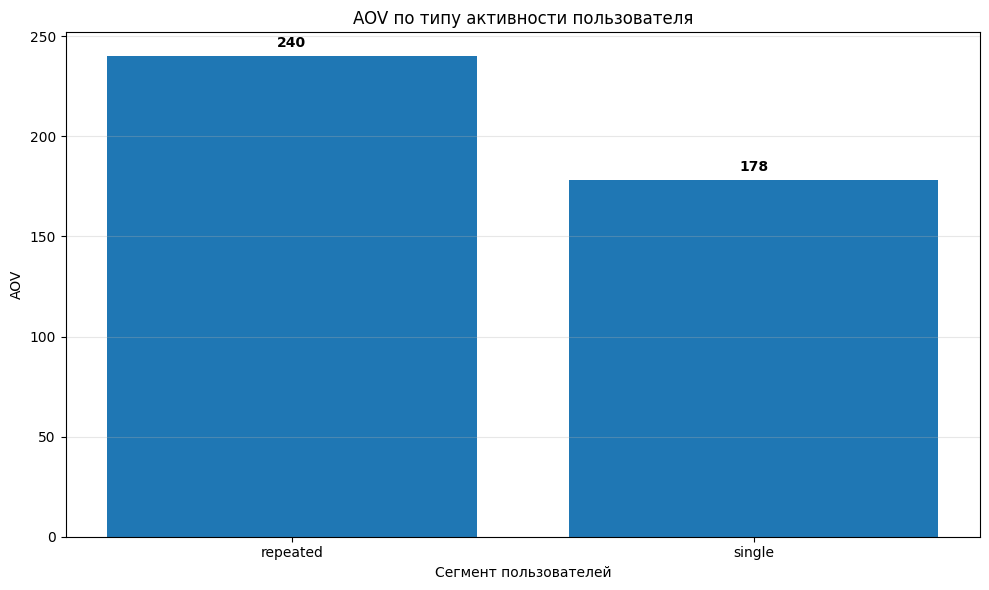

In [113]:
aov_segment_df = pd.read_csv('exports/AOV_per_user_segment.csv')

plt.figure(figsize=(10, 6))

bars = plt.bar(aov_segment_df['user_segment'], aov_segment_df['aov'])

for bar, value in zip(bars, aov_segment_df['aov']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 3,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('AOV по типу активности пользователя')
plt.xlabel('Сегмент пользователей')
plt.ylabel('AOV')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Повторные пользователи выглядят наиболее ценным сегментом с точки зрения монетизации**: несмотря на меньшую численность, они лучше конвертируются в корзину и совершают более дорогие покупки, что в итоге позволяет им генерировать больше выручки, чем более многочисленному сегменту одноразовых пользователей. **Это указывает на то, что сам факт возврата пользователя связан с существенно более высокой покупательской ценностью.**  

**Поэтому важно понять механизм формирования повторных покупок**: возвращаются ли пользователи после предыдущего целевого действия или их возвращает интерес к конкретным товарам, категориям или брендам. **Ответ на этот вопрос позволит понять, за счёт чего формируется наиболее ценный сегмент и какие факторы можно использовать для его масштабирования.**

**Анализ последнего события в первой сессии**

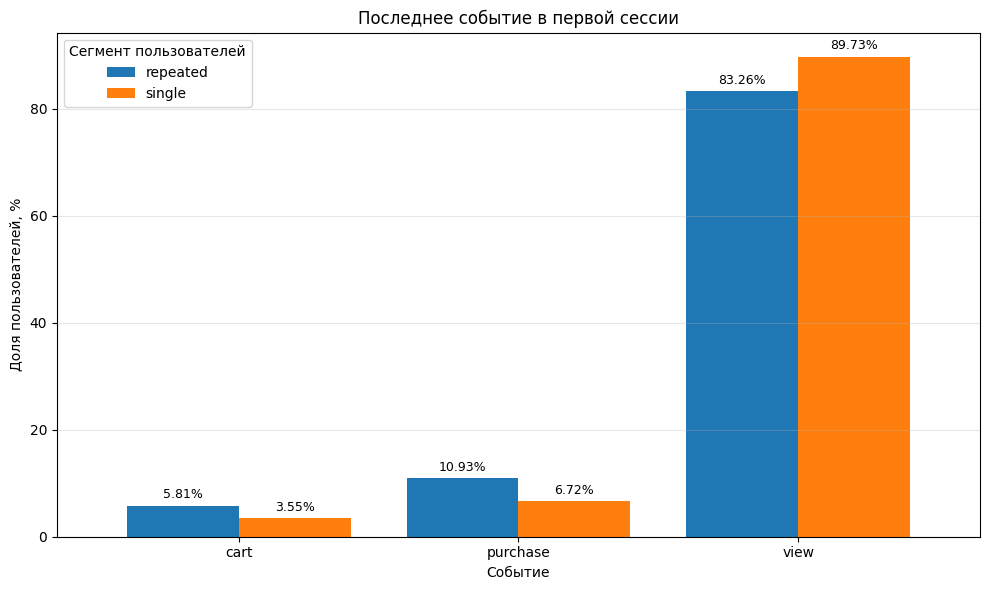

In [114]:
last_action_df = pd.read_csv('exports/Last_action_of_user_segment.csv')

pivot_df = last_action_df.pivot(index='last_action', columns='user_segment', values='share')

ax = pivot_df.plot(kind='bar', figsize=(10, 6), width=0.8)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.title('Последнее событие в первой сессии')
plt.xlabel('Событие')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Сегмент пользователей')

plt.tight_layout()
plt.show()

**У будущих повторных пользователей первая сессия чаще заканчивается целевым действием: добавлением товара в корзину или покупкой**.    
Такие события встречаются примерно **в 1,6 раза чаще**, чем у пользователей, которые больше не возвращаются. Это указывает на связь между глубиной взаимодействия в первой сессии и последующим возвратом, однако не позволяет утверждать, что именно совершение целевого действия приводит к повторному визиту.    
**Чтобы понять, что формирует мотивацию вернуться, необходимо дополнительно исследовать, с какими товарами, категориями и брендами пользователи взаимодействовали в первой сессии.**

**Анализ взаимодействия пользователей с категориями 1 уровня в первой сессии**

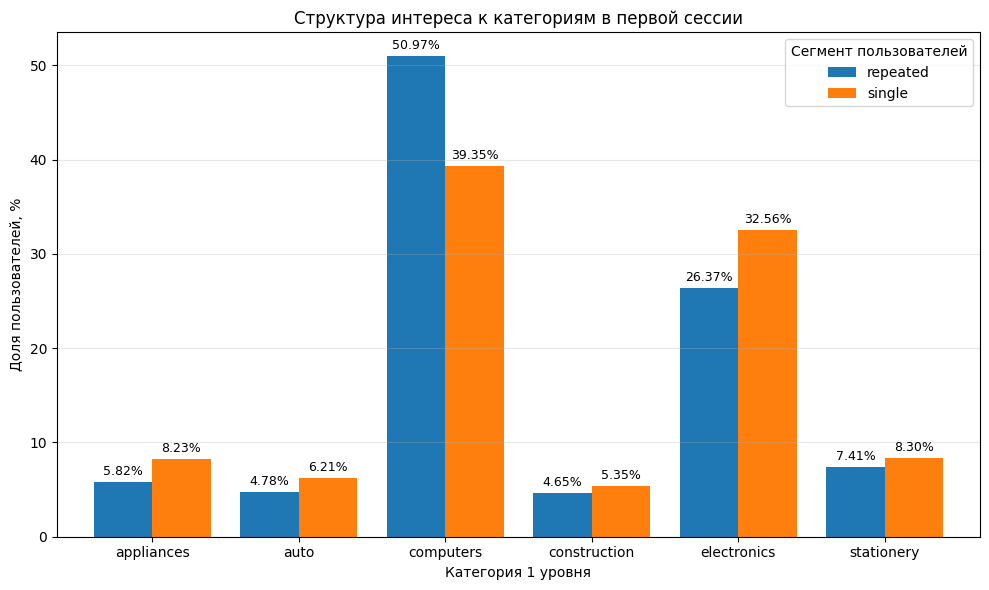

In [115]:
category_segment_df = pd.read_csv('exports/Category_lvl_1_of_user_segment.csv')

pivot_df = category_segment_df.pivot(index='category_lvl_1', columns='user_segment', values='share')

ax = pivot_df.plot(kind='bar', figsize=(10, 6), width=0.8)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.title('Структура интереса к категориям в первой сессии')
plt.xlabel('Категория 1 уровня')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Сегмент пользователей')

plt.tight_layout()
plt.show()

**Структура товарного интереса в первой сессии заметно различается между сегментами.** У будущих повторных пользователей почти половина взаимодействий приходится на категорию `computers` — 50,97% против 39,35% у одноразовых, тогда как доля `electronics`, наоборот, ниже на 6,19 п.п. По остальным категориям различия значительно меньше.

Это показывает, что возврат пользователя может быть связан не только с глубиной его взаимодействия, но и с характером товарного интереса в первой сессии. Это важно, поскольку понимание категорий, которые чаще встречаются у пользователей с последующим возвратом, может помочь точнее формировать рекомендации и коммуникации для новых пользователей.

**Наиболее перспективным направлением для дальнейшего анализа выглядит категория `computers`: внутри неё стоит определить конкретные подкатегории и бренды, которые формируют повышенный интерес будущих повторных пользователей.**

**Анализ топ-10 подкатегорий по товарному интересу в первой сессии**

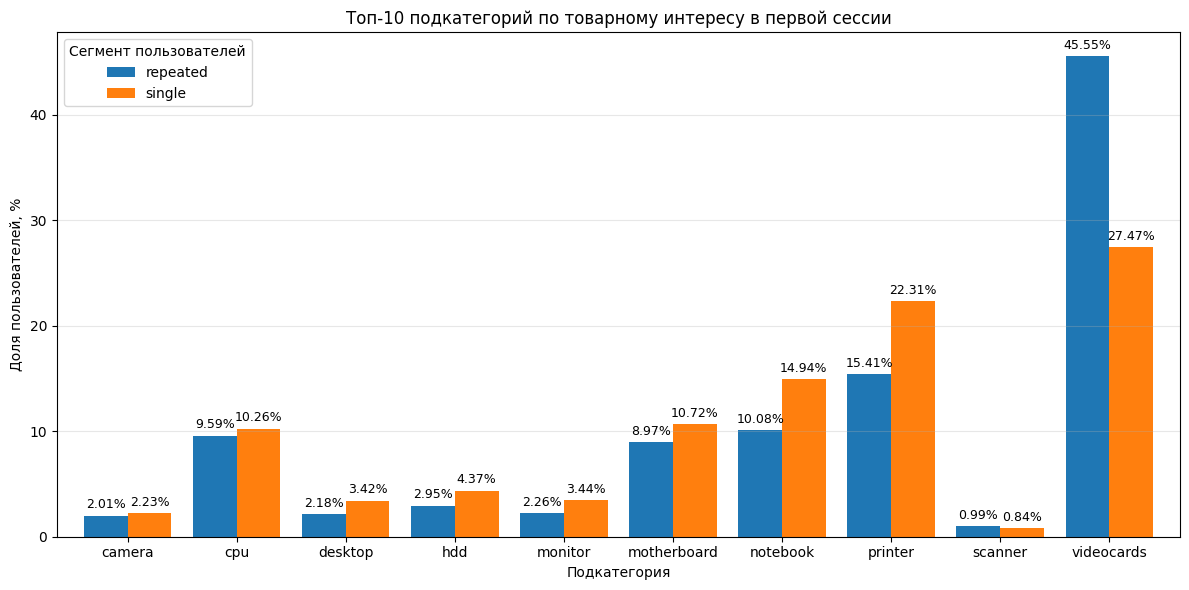

In [116]:
category_computers_df = pd.read_csv('exports/Category_of_computers_user_segment.csv')

category_computers_df['category'] = (category_computers_df['category_code'].str.split('.').str[-1])

pivot_df = category_computers_df.pivot(index='category', columns='user_segment', values='share')

ax = pivot_df.plot(kind='bar', figsize=(12, 6), width=0.8)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.title('Топ-10 подкатегорий по товарному интересу в первой сессии')
plt.xlabel('Подкатегория')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Сегмент пользователей')

plt.tight_layout()
plt.show()

Различия в товарном интересе внутри категории `computers` становятся значительно заметнее на уровне подкатегорий.   
**Наиболее сильный разрыв приходится на видеокарты**: их доля среди взаимодействий будущих повторных пользователей составляет 45,55% против 27,47% у одноразовых — **разница 18,08 п.п.** При этом остальные подкатегории дают значительно меньший вклад в различия между сегментами.

**Таким образом, видеокарты являются ключевым товарным направлением, отличающим интерес будущих повторных пользователей уже в первой сессии.**   
Это делает категорию перспективной для дальнейшего изучения пользовательского поведения и персонализации коммуникаций.    **Следующий шаг — определить, какие бренды видеокарт наиболее характерны для повторных пользователей, чтобы понять, формируется ли наблюдаемый эффект интересом к самой категории или преимущественно отдельными брендами.**

**Анализ взаимодействия пользователей с брендами в первой сессии**

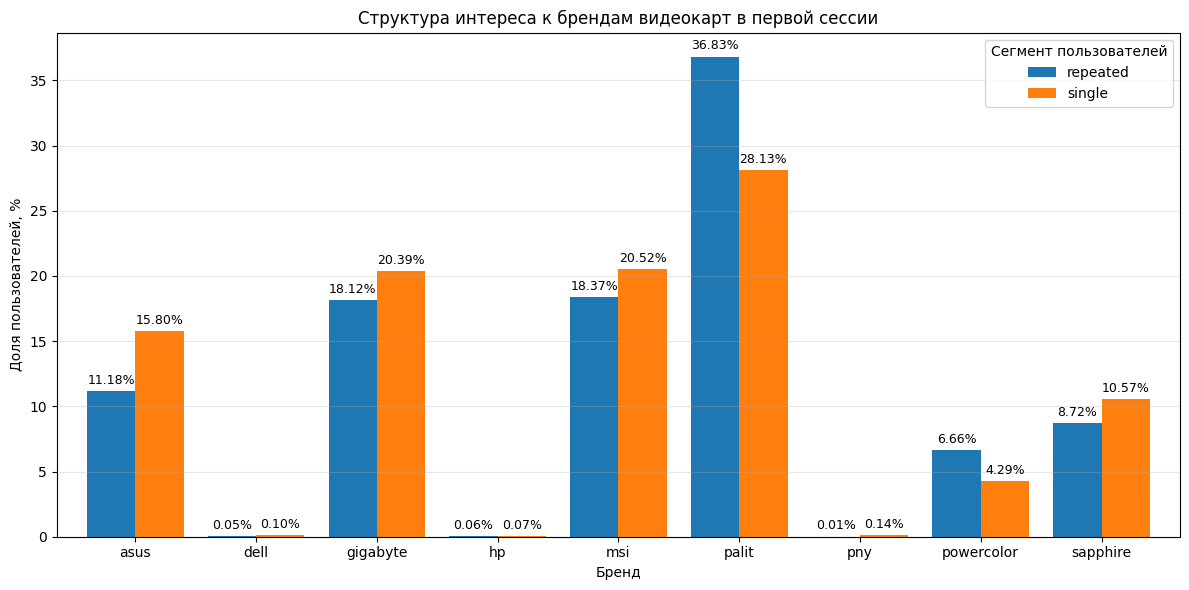

In [117]:
brand_segment_df = pd.read_csv('exports/Brand_of_user_segment.csv')

pivot_df = brand_segment_df.pivot(index='brand', columns='user_segment', values='share')

ax = pivot_df.plot(kind='bar', figsize=(12, 6), width=0.8)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f%%',
        padding=3,
        fontsize=9
    )

plt.title('Структура интереса к брендам видеокарт в первой сессии')
plt.xlabel('Бренд')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.legend(title='Сегмент пользователей')

plt.tight_layout()
plt.show()

На уровне брендов различия внутри видеокарт сохраняются и становятся более конкретными.    
**Наиболее заметно выделяется `Palit`**: на него приходится 36,83% пользовательского интереса среди будущих повторных пользователей против 28,13% у одноразовых — **разница 8,7 п.п.**

Таким образом, повышенный интерес будущих повторных пользователей к видеокартам в значительной степени связан с отдельными брендами, прежде всего `Palit`.     
**При работе с привлечением и удержанием пользователей стоит отдельно рассмотреть товарные сценарии и коммуникации вокруг видеокарт, особенно бренда `Palit`, поскольку именно здесь наблюдается наиболее выраженное отличие между сегментами.**

**Анализ возврата пользователей по времени возвращения**

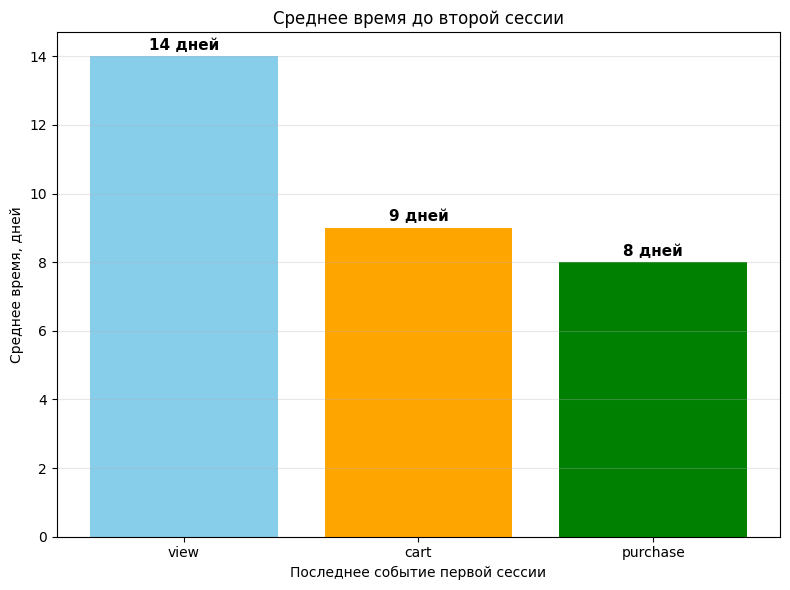

In [118]:
time_back_df = pd.read_csv('exports/Time_back_per_last_action.csv')

order = ['view', 'cart', 'purchase']

time_back_df['last_action'] = pd.Categorical(time_back_df['last_action'], categories=order, ordered=True)

time_back_df = time_back_df.sort_values('last_action')

colors = {
    'view': 'skyblue',
    'cart': 'orange',
    'purchase': 'green'
}

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    time_back_df['last_action'],
    time_back_df['avg_time_back'].str.extract(r'(\d+)')[0].astype(float),
    color=[colors[action] for action in time_back_df['last_action']]
)

for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f'{value:.0f} дней',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

ax.set_title('Среднее время до второй сессии')
ax.set_xlabel('Последнее событие первой сессии')
ax.set_ylabel('Среднее время, дней')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Скорость возврата заметно связана с глубиной взаимодействия пользователя в первой сессии.**    
Пользователи, завершившие первую сессию покупкой, в среднем возвращаются через 8 дней, добавившие товар в корзину — через 9 дней, а ограничившиеся просмотром — через 14 дней. 

**Таким образом, чем дальше пользователь продвигается по воронке, тем быстрее в среднем происходит его повторный визит.**   
Это делает глубину первого взаимодействия важным ориентиром для оценки качества вовлечения и поиска механик, способных ускорить переход пользователя к повторному визиту.

**Анализ перехода от первой ко второй сессии у повторных пользователей**

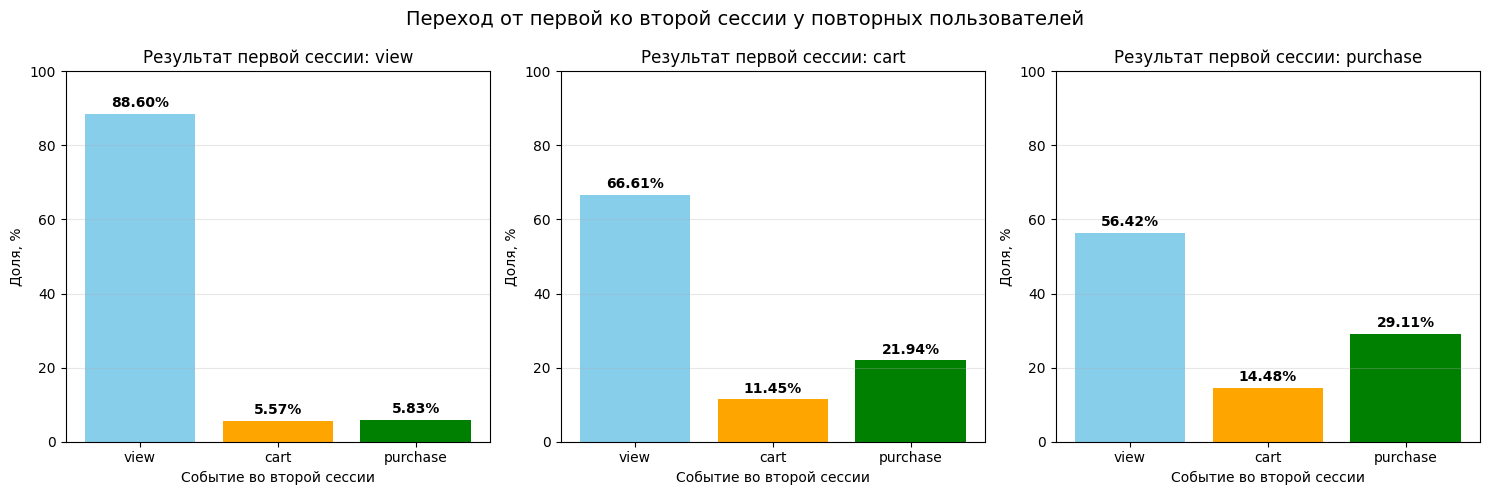

In [119]:
session_df = pd.read_csv('exports/First_to_Second_session_for_repeated.csv')

first_sessions = ['view', 'cart', 'purchase']
second_sessions = ['view', 'cart', 'purchase']

colors = {
    'view': 'skyblue',
    'cart': 'orange',
    'purchase': 'green'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, first_session in zip(axes, first_sessions):
    plot_df = session_df[session_df['firsts_session'] == first_session].copy()

    plot_df['seconds_session'] = pd.Categorical(plot_df['seconds_session'], categories=second_sessions, ordered=True)

    plot_df = plot_df.sort_values('seconds_session')

    bars = ax.bar(plot_df['seconds_session'], plot_df['share'], color=[colors[event] for event in plot_df['seconds_session']])

    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f'{value:.2f}%',
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=10
        )

    ax.set_title(f'Результат первой сессии: {first_session}')
    ax.set_xlabel('Событие во второй сессии')
    ax.set_ylabel('Доля, %')
    ax.set_ylim(0, 100)

    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Переход от первой ко второй сессии у повторных пользователей', fontsize=14)

plt.tight_layout()
plt.show()

**Пользователи, которые уже совершили покупку в первой сессии, во второй сессии значительно чаще продолжают целевое поведение:** почти треть повторно совершают покупку, а ещё 14,48% доходят до корзины.   
У пользователей, завершивших первую сессию корзиной, доля покупок во второй сессии также заметно выше — 21,94%.   
В то же время среди пользователей, ограничившихся просмотром, 88,6% во второй сессии снова остаются на уровне просмотра, и только 5,83% доходят до покупки.

**Глубина первой сессии связана не только со скоростью возврата, но и с качеством последующего визита. Чем глубже пользователь продвинулся по воронке изначально, тем выше вероятность, что после возвращения он продолжит целевое поведение, тогда как пользователи, начавшие с простого просмотра, преимущественно возвращаются к просмотру без дальнейшего продвижения по воронке.**

**`LTV`**

**LTV по когортам первого месяца покупки**

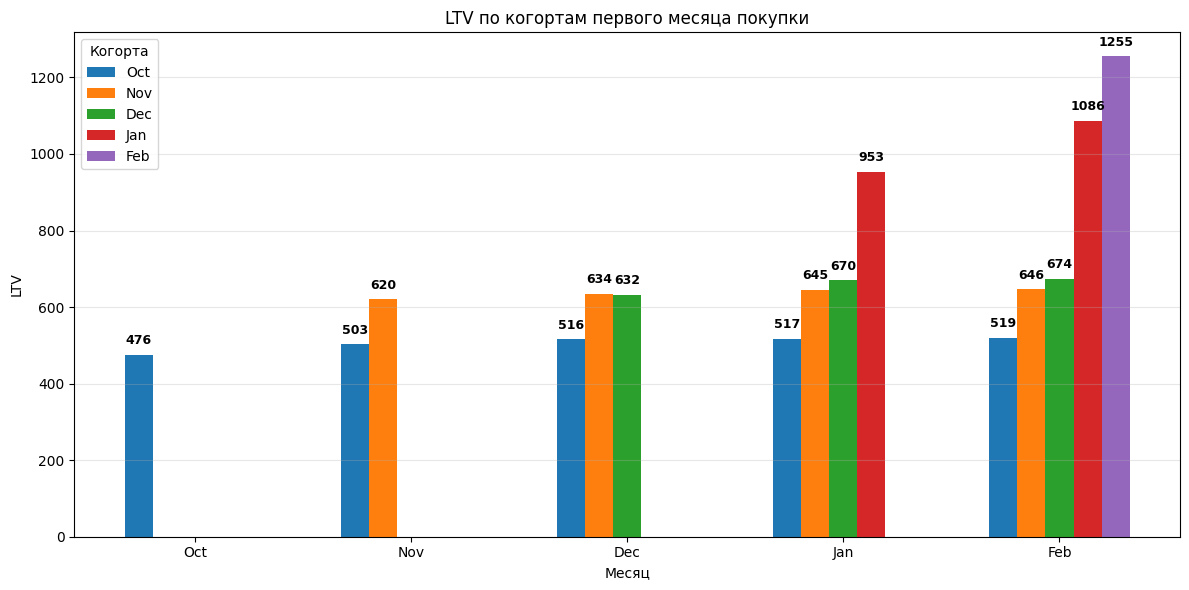

In [120]:
ltv_df = pd.read_csv('exports/LTV.csv')

ltv_df['month_'] = pd.to_datetime(ltv_df['month_'])

cohort_order = ['oct', 'nov', 'dec', 'jan', 'feb']

pivot_ltv = ltv_df.pivot(index='month_', columns='cohort_month', values='ltv')

pivot_ltv = pivot_ltv.reindex(columns=cohort_order)

x = np.arange(len(pivot_ltv))
width = 0.13

fig, ax = plt.subplots(figsize=(12, 6))

for i, cohort in enumerate(cohort_order):
    values = pivot_ltv[cohort]

    bars = ax.bar(
        x + (i - 2) * width,
        values,
        width=width,
        label=cohort.capitalize()
    )

    for bar in bars:
        if not np.isnan(bar.get_height()):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 20,
                f'{bar.get_height():.0f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

ax.set_title('LTV по когортам первого месяца покупки')
ax.set_xlabel('Месяц')
ax.set_ylabel('LTV')

ax.set_xticks(x)
ax.set_xticklabels(pivot_ltv.index.strftime('%b'))

ax.legend(title='Когорта')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Когорты по первому месяцу покупки демонстрируют последовательный рост стартового LTV: от 476 у октябрьской когорты до 1255 у февральской.**   
При этом наиболее заметный скачок произошёл у январской когорты — с 953 до 1086 уже за второй месяц наблюдения, тогда как предыдущие когорты после первого месяца практически выходят на плато. Показательно, что ни одна более ранняя когорта не смогла впоследствии превысить LTV следующей за ней когорты, несмотря на накопительный характер метрики.

При этом у большинства когорт основная часть LTV формируется уже в месяц первой покупки, а дальнейший прирост остаётся ограниченным. Повторные покупки пока не формируют значительную дополнительную ценность пользователя на горизонте доступных данных. 

**Следовательно, ключевой вопрос — действительно ли пользователи редко возвращаются после первой покупки или проблема заключается в недостаточной конверсии возвращающихся пользователей в повторные покупки. Это проверим через retention-анализ.**

**`Retention Rate`**

**Retention Rate по когортам первого месяца покупки**

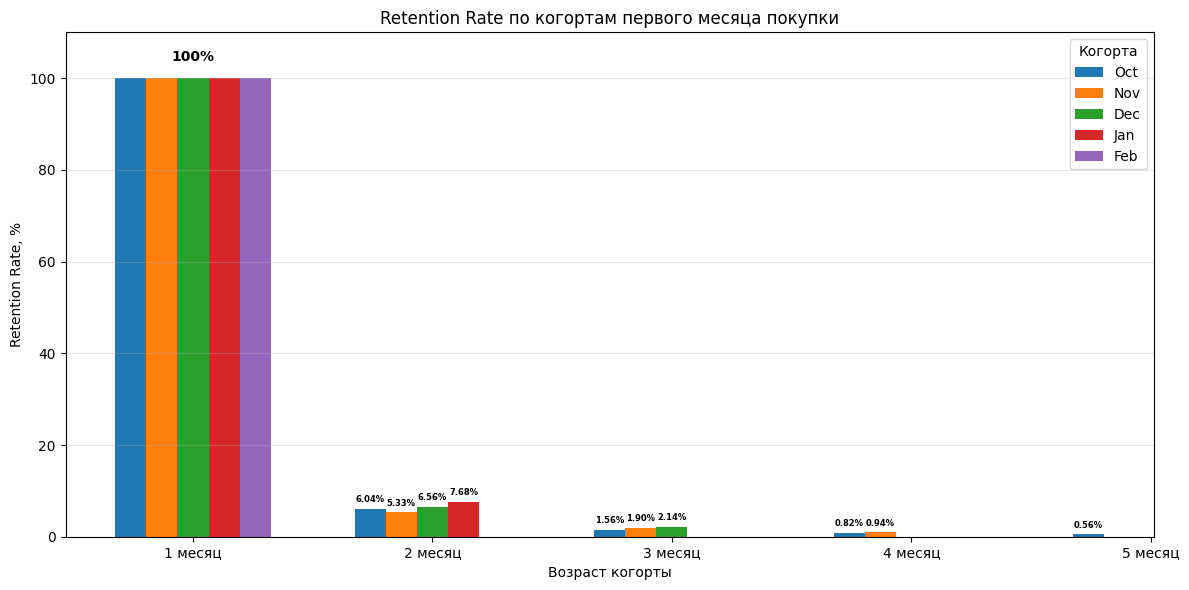

In [121]:
retention_df = pd.read_csv('exports/Retenton_Rate.csv')

retention_df['cohort_month'] = pd.to_datetime(retention_df['cohort_month'])
retention_df['month_'] = pd.to_datetime(retention_df['month_'])

retention_df['cohort_age'] = (
    (retention_df['month_'].dt.year - retention_df['cohort_month'].dt.year) * 12
    + (retention_df['month_'].dt.month - retention_df['cohort_month'].dt.month)
    + 1
)

cohort_order = sorted(retention_df['cohort_month'].unique())

x = np.arange(1, 6)
width = 0.13

fig, ax = plt.subplots(figsize=(12, 6))

for i, cohort in enumerate(cohort_order):
    plot_df = retention_df[retention_df['cohort_month'] == cohort].sort_values('cohort_age')

    bars = ax.bar(
        plot_df['cohort_age'] + (i - 2) * width,
        plot_df['share'],
        width=width,
        label=cohort.strftime('%b')
    )

    for bar in bars:
        height = bar.get_height()

        if height != 100:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 1,
                f'{height:.2f}%',
                ha='center',
                va='bottom',
                fontsize=6,
                fontweight='bold'
            )

ax.text(
    1,
    103,
    '100%',
    ha='center',
    va='bottom',
    fontsize=10,
    fontweight='bold'
)

ax.set_title('Retention Rate по когортам первого месяца покупки')
ax.set_xlabel('Возраст когорты')
ax.set_ylabel('Retention Rate, %')

ax.set_xticks(x)
ax.set_xticklabels(['1 месяц', '2 месяц', '3 месяц', '4 месяц', '5 месяц'])

ax.set_ylim(0, 110)

ax.legend(title='Когорта')

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Когорты сформированы по месяцу первой покупки, а retention в последующие месяцы отражает возвращение пользователя с любым действием — просмотром, добавлением в корзину или покупкой.**

Даже при таком широком определении retention остаётся очень низким: в первый месяц после покупки возвращается только 5,33–7,68% пользователей, а через два месяца показатель снижается примерно до 2% и ниже.   
**Это объясняет, почему накопительный LTV большинства когорт быстро выходит на плато**: основная ценность пользователя формируется в момент первого месяца покупки, а повторные визиты большинства пользователей практически отсутствуют. 

**Это указывает на слабое удержание покупателей и ограниченный потенциал дополнительной выручки за счёт повторных покупок без специальных механик возврата и повторного вовлечения.** <br><br>

### Основные результаты анализа монетизации продукта и когортного анализа

Анализ монетизации показывает, что **основной источник финансового результата магазина — не массовая пользовательская активность сама по себе, а качество поведения пользователей и структура совершаемых покупок.** За исследуемый период магазин получил 5,12 млн выручки и продал 37,3 тыс. единиц товара. <br><br>

**Наиболее ярко это проявилось в январе:** при сопоставимом с октябрём размере активной аудитории **выручка выросла с 562,6 тыс. до 1,49 млн.** **Следовательно, рост монетизации был обусловлен не увеличением числа активных пользователей, а изменением их покупательского поведения.** При этом средний чек вырос с 187 до 273, что подтверждает увеличение стоимости совершаемых покупок.

**Главным драйвером этого роста стала категория `computers`, на которую приходится 80,7% всей выручки магазина.** **Внутри неё ключевую роль играют видеокарты: в январе их выручка выросла более чем в 10 раз** относительно октября. Рост оказался массовым и не был связан с одним отдельным брендом — выручка увеличилась сразу по нескольким производителям. Это указывает скорее на общий всплеск спроса на категорию, чем на единичный эффект конкретного товара или бренда. При этом среди пользователей, которые впоследствии возвращались, видеокарты уже в первой сессии занимали 45,55% товарного интереса против 27,47% у одноразовых пользователей, а внутри категории особенно выделялся бренд `Palit` — 36,83% против 28,13%. <br><br>

**Отдельно выделяется влияние ценового сегмента. Дорогие товары составляют только верхние 10% ценового распределения, но формируют 3,25 млн выручки против 1,83 млн у среднего сегмента и всего 40 тыс. у дешёвого.** При этом дорогие товары не только сильнее влияют на выручку, но и лучше конвертируются из просмотра в корзину. Таким образом, средний сегмент обеспечивает основной объём продаж в штуках, но именно дорогие товары имеют непропорционально высокий вклад в денежный результат. <br><br>

**Однако наиболее важный результат анализа связан не с отдельными товарами, а с повторными пользователями.** Несмотря на меньшую численность, они генерируют больше выручки, имеют более высокий AOV (240 против 178) и чаще совершают целевые действия. При этом различия между сегментами начинают проявляться уже в первой сессии: **у будущих повторных пользователей она чаще заканчивается корзиной или покупкой**.

**Более того, глубина первой сессии связана с последующим поведением пользователя.** Пользователи, завершившие первую сессию покупкой, возвращаются в среднем через 8 дней, после корзины — через 9 дней, после просмотра — через 14 дней. После возврата различия сохраняются: среди пользователей с покупкой в первой сессии 29,11% совершают покупку и во второй, тогда как среди завершивших первую сессию просмотром до покупки во второй доходят только 5,83%. **Это показывает, что пользователи, которые уже сформировали высокий уровень интереса к товару, не просто чаще возвращаются — их последующие визиты также имеют более высокую коммерческую ценность.**

При этом нельзя трактовать это как доказательство того, что покупка или корзина сами по себе вызывают возврат. Анализ показывает устойчивую связь между глубиной взаимодействия и последующим поведением, но не устанавливает причинность. **Одновременно мы видим, что будущие повторные пользователи уже в первой сессии чаще интересуются определёнными товарными направлениями — прежде всего `computers` и внутри неё видеокартами.** Это позволяет предположить, что важную роль играет не только стадия воронки, но и сам характер товарного интереса пользователя. <br><br>

**Главная проблема становится очевидной при переходе к когортному анализу.** Магазин способен получать прибыль от пользователей, которые уже дошли до глубокого взаимодействия, **но плохо удерживает пользовательскую базу в целом.** Когорты формировались по месяцу первой покупки, а retention измерял любое возвращение пользователя — просмотр, корзину или покупку. **Даже при таком широком определении в следующий месяц возвращалось лишь 5,33–7,68% пользователей, а ещё через месяц показатель опускался примерно до 2% и ниже.**

**Это напрямую отражается на LTV: основная часть накопительной ценности формируется уже в месяц первой покупки, после чего у большинства когорт происходит резкое замедление роста.** При этом более новые когорты демонстрируют более высокий стартовый LTV — от 476 у октябрьской до 1255 у февральской, а ни одна более ранняя когорта впоследствии не смогла превысить следующую за ней. Наиболее сильный прирост наблюдается у январской когорты. <br><br>

**Таким образом, ключевой вывод монетизационного и когортного анализа — магазин имеет высокий потенциал повторной ценности пользователя, но не умеет системно доводить до неё основную массу аудитории.** Пользователи, которые находят релевантный товар, глубже проходят воронку и формируют высокий интерес, становятся наиболее ценным сегментом: они быстрее возвращаются, чаще совершают целевые действия и приносят больше выручки. Одновременно низкий retention показывает, что большая часть пользователей отсеивается после первого взаимодействия или покупки. <br><br>

**Это означает, что точка роста находится не в простом привлечении ещё большего количества пользователей, сколько в увеличении доли пользователей, которые переходят от первого интереса к глубокому взаимодействию и последующему возвращению.** Особенно перспективными направлениями для этого выглядят категории и товарные сценарии, уже связанные с высокой ценностью пользователей — прежде всего `computers`, `видеокарты` и `дорогой ценовой сегмент товаров`. Именно здесь стоит искать механики рекомендаций, персонализации и повторного вовлечения, которые смогут масштабировать поведение наиболее ценных пользователей на более широкую аудиторию. <br><br><br><br>

## Выводы по разделу «Анализ ключевых продуктовых метрик»

Анализ ключевых продуктовых метрик показывает, что **основная проблема магазина заключается не в отсутствии спроса или способности монетизировать пользователей, а в низкой способности переводить широкий поток первоначального интереса в устойчивое и повторное взаимодействие**. Активная аудитория существенно меняется во времени, при этом Stickiness остается на уровне всего 3,5–4%, что указывает на низкую регулярность использования продукта. Одновременно основная потеря воронки происходит уже на этапе **View → Cart**, где конверсия составляет 9,09%, тогда как более половины пользователей, уже добавивших товар в корзину, завершают покупку. <br><br>

При этом анализ показывает, что глубокое взаимодействие с магазином тесно связано с последующей коммерческой ценностью пользователя. Повторные пользователи конвертируются в корзину в 4,6 раза лучше одноразовых (28,44% против 6,23%), имеют более высокий AOV (240 против 178), а пользователи, совершившие покупку в первой сессии, значительно чаще покупают и во второй. **Наиболее ценный пользовательский сценарий уже существует внутри продукта: пользователь находит релевантный товар, глубже проходит воронку, возвращается и в дальнейшем приносит больше выручки.** <br><br>

**Однако этот сценарий пока не масштабируется на основную аудиторию.** Низкий retention — всего 5,33–7,68% возврата в следующий месяц и около 2% и ниже ещё через месяц — приводит к тому, что основная часть накопительной ценности формируется уже в первый месяц. При этом рост выручки может происходить даже без сопоставимого роста аудитории: например, с октября по январь выручка выросла с 562,6 тыс. до 1,49 млн, а средний чек — со 187 до 273. Значительную роль в этом играют дорогие товары и прежде всего категория `computers`, формирующая 80,7% всей выручки, что показывает наличие сильного потенциала монетизации даже при относительно небольшой глубине удержания. <br><br>

**Таким образом, ключевая точка роста магазина находится в увеличении доли пользователей, которые проходят путь от первоначального интереса к глубокому взаимодействию и последующему возвращению.** При этом анализ уже позволяет локализовать, где искать такие возможности: в наиболее ценных товарных сценариях — прежде всего `computers`, видеокартах и дорогом ассортименте — и в проблемных сегментах, таких как `appliances`, одноразовые пользователи и дорогие товары `Samsung`. **Дальнейшее развитие продукта целесообразно связывать не просто с привлечением большего количества пользователей, а с масштабированием поведения наиболее ценных пользователей на более широкую аудиторию и устранением барьеров, которые мешают пользователям переходить к более глубокому взаимодействию и возвращаться в магазин.** <br><br><br><br>

## 4. Итоговые выводы и бизнес-рекомендации

### 4.1 Ключевые закономерности

Проведённый анализ позволяет выделить несколько устойчивых закономерностей, характеризующих пользовательское поведение, структуру спроса и формирование выручки интернет-магазина.


#### 1. Основная аудитория взаимодействует с магазином эпизодически

**Большая часть пользователей имеет очень низкую глубину взаимодействия с продуктом**: 65,43% пользователей совершают только одно событие, 81% — не более двух, а 87,14% ограничиваются одной сессией. При этом `Stickiness` на протяжении всего периода остаётся в диапазоне 3,5–4%, что соответствует примерно 1–1,2 дням активности пользователя в месяц.

**Эта закономерность сохраняется и при переходе к когортному анализу**: в следующий месяц возвращается только 5,33–7,68% польззователей, а ещё через месяц `retention` снижается примерно до 2% и ниже. Таким образом, магазин взаимодействует с большой аудиторией, но значительная её часть не формирует регулярной связи с продуктом. <br><br>


#### 2. Пользовательская активность имеет выраженную временную закономерность

**Активность пользователей распределена по времени неравномерно.** Наибольшее количество пользователей взаимодействует с магазином в будние дни, особенно в начале рабочей недели, тогда как в выходные активность снижается. В течение суток наиболее высокий уровень активности наблюдается примерно с 10:00 до 18:00.

При этом динамика DAU практически повторяет динамику общего количества событий, а максимальный уровень месячной аудитории наблюдается в ноябре — около 92 тыс. активных пользователей. Последующее снижение активности связано преимущественно с уменьшением количества активных пользователей, а не с изменением интенсивности их взаимодействия.

**Таким образом, магазин имеет выраженные периоды повышенного пользовательского трафика, которые могут быть важны при планировании маркетинговых и продуктовых активностей.** <br><br>


#### 3. Основная потеря пользователей происходит до формирования намерения покупки

**Общая конверсия View → Cart составляет 9,09%, тогда как после добавления в корзину 57,64% пользователей совершают покупку.**   
Следовательно, проблема магазина находится преимущественно не на этапе завершения покупки, а раньше — на этапе превращения первоначального интереса к товару в намерение приобрести его.

**При этом покупательский путь в большинстве случаев достаточно короткий**: более половины покупательских сессий содержат всего 3–5 событий, а медианное время между просмотром и добавлением товара в корзину составляет около минуты, между корзиной и покупкой — около двух минут. Это может указывать на то, что значительная часть пользователей приходит на сайт уже с относительно сформированным представлением о том, какой товар они хотят приобрести. <br><br>


#### 4. Глубокое взаимодействие с магазином связано с существенно большей коммерческой ценностью пользователя

**Повторные пользователи демонстрируют принципиально другое поведение по сравнению с одноразовыми.** Их конверсия `View → Cart` составляет 28,44% против 6,23% у одноразовых пользователей, то есть различается в 4,6 раза. Они также имеют более высокий средний чек — 240 против 178.

**Различия проявляются уже в первой сессии.** Пользователи, которые впоследствии возвращаются, чаще заканчивают первую сессию корзиной или покупкой и чаще интересуются определёнными товарными направлениями, прежде всего `computers`, а внутри этой категории видеокартами.

**Связь сохраняется и после возвращения**: пользователи, совершившие покупку в первой сессии, возвращаются в среднем через 8 дней, а среди них 29,11% совершают покупку и во второй сессии. Для пользователей, завершивших первую сессию только просмотром, соответствующая доля составляет всего 5,83%, а время возвращения составляет 14 дней.

**Таким образом, наиболее ценное поведение уже существует внутри продукта, однако его демонстрирует меньшая часть аудитории.** <br><br>


#### 5. Высокая стоимость товара не является барьером для формирования покупательского намерения

**Конверсия View → Cart последовательно увеличивается вместе с ценовым сегментом**:

Дешёвые товары — 6,79%;   
Средние — 8,37%;   
Дорогие — 13,04%.   

То есть дорогие товары в среднем почти в два раза чаще переходят из просмотра в корзину, чем дешёвые.

**Эта закономерность особенно важна с точки зрения монетизации**: дорогие товары составляют только верхние 10% ценового распределения, но формируют большую часть выручки за исселдуемый период - **3,25 млн (63,5%)** против **1,83 млн (35,8%)** у среднего сегмента и **около 40 тыс. (0.7%)** у дешёвого.

**При этом средний ценовой сегмент обеспечивает основной объём продаж в штуках, а дорогой ассортимент имеет непропорционально высокий вклад именно в денежный результат.** <br><br>


#### 6. Пользовательский интерес и способность конвертировать этот интерес — не одно и то же

Высокая популярность товарного направления не гарантирует высокой эффективности воронки.

**Наиболее показательный пример — `electronics.telephone` и `computers.components.videocards`.** Обе категории относятся к наиболее востребованным направлениям, однако их конверсия View → Cart составляет 9,56% и 27,36% соответственно.

После учёта ценового сегмента различие сохраняется и становится особенно выраженным среди дорогих товаров:

Дорогие видеокарты — 28,61%;   
Дорогие телефоны — 3,10%.   

Отдельно выделяется категория `appliances`, где конверсия в корзину составляет всего 4,19% несмотря на достаточный пользовательский интерес.

**Таким образом, объём спроса и способность магазина превращать этот спрос в покупательское намерение — две разные характеристики, которые необходимо рассматривать отдельно.** <br><br>


#### 7. Основной финансовый результат магазина сосредоточен в отдельных товарных направлениях

**Категория `computers` формирует 80,7% всей выручки магазина, что говорит о крайне высокой концентрации денежного результата.**

**Особенно заметную роль играют видеокарты**: в январе их выручка выросла более чем в 10 раз относительно октября. Рост наблюдался сразу у нескольких производителей, поэтому он не сводится к результату одного отдельного бренда и скорее отражает общий всплеск спроса на категорию.

**При этом видеокарты имеют не только высокую коммерческую ценность, но и связь с наиболее ценным типом пользователей**: среди будущих повторных пользователей они занимают 45,55% товарного интереса в первой сессии против 27,47% у одноразовых пользователей.

**Это связывает между собой три наблюдения: товарный интерес → глубина взаимодействия → последующая коммерческая ценность.** <br><br>


#### 8. Внутри популярных товарных направлений существуют локальные проблемы конверсии

Проблема низкой конверсии не является общей для всего магазина и не может быть объяснена только ценой товара или популярностью категории.

**Особенно заметен дорогой ассортимент Samsung.** Сам бренд является одним из наиболее значимых для магазина по пользовательскому интересу: он входит в топ-3 по просмотрам, имеет крупнейший ассортимент и лидирует по количеству уникальных пользователей, просматривающих его товары.

Однако его конверсия View → Cart составляет:

Дешёвый сегмент — 5,19%;   
Средний — 8,15%;   
Дорогой — всего 2,05%.   

Низкая конверсия дорогих товаров `Samsung` наблюдается сразу в нескольких крупных категориях, особенно в телефонах и телевизорах, где она находится примерно на уровне 2%.

**Это показывает, что внутри наиболее востребованного ассортимента могут одновременно существовать сильные и слабые пользовательские сценарии.** <br><br>


#### 9. Магазин способен существенно увеличивать выручку без сопоставимого роста аудитории

**Динамика монетизации показывает, что изменение выручки не обязательно связано с увеличением количества активных пользователей.**

Например, с октября по январь месячная выручка выросла с 562,6 тыс. до 1,49 млн, тогда как размер активной аудитории был сопоставим. Одновременно `AOV` увеличился со 187 до 273.

Следовательно, рост финансового результата в отдельные периоды может происходить за счёт изменения структуры спроса, стоимости приобретаемых товаров и поведения покупателей, а не только за счёт привлечения новых пользователей.

Январский рост, в частности, был во многом связан с компьютерами и видеокартами. <br><br>


#### 10. У магазина есть потенциал увеличения ценности уже существующих покупок

**Большинство пользователей совершают ограниченное количество покупок**: 63,82% покупателей приобретают не более одного товара, 83,97% — не более двух. При этом среди пользователей с несколькими покупками наиболее распространён сценарий повторной покупки одного и того же товара.

**Одновременно анализ совместных покупок выявил устойчивую двустороннюю связь между процессорами и материнскими платами**: в 23,5% случаев после покупки процессора в рамках той же покупательской сессии также приобретается материнская плата, также это работает и в обратную сторону. `Lift` = 5,13 означает, что совместная покупка этих категорий происходит более чем в пять раз чаще ожидаемого при независимом выборе.

**Таким образом, внутри существующего спроса уже присутствуют естественные товарные связи, которые могут быть использованы для увеличения среднего чека.** <br><br>


#### Общая картина

**В совокупности результаты показывают достаточно характерную для `e-Commerce` картину**: широкий пользовательский поток не превращается в столь же широкую базу постоянных и глубоко вовлечённых клиентов. Большинство пользователей взаимодействуют с продуктом поверхностно и редко возвращаются, однако те, кто формирует более высокий уровень интереса, значительно лучше конвертируются, чаще возвращаются и приносят больше выручки.

**При этом магазин уже обладает сильными сторонами**: способностью монетизировать сформированный спрос, значительным вкладом дорогого ассортимента, сильными товарными направлениями в `computers` и видеокартах, а также выраженными возможностями для кросс-продаж. **Одновременно существуют локальные зоны неэффективности** — прежде всего низкая конверсия отдельных категорий, одноразовых пользователей и дорогого ассортимента отдельных брендов.

**Таким образом, данные показывают не отсутствие спроса, а разрыв между существующим пользовательским интересом и способностью магазина масштабировать наиболее ценные сценарии поведения на основную аудиторию. Именно этот разрыв является главным результатом проведённого анализа и основой для формирования дальнейших продуктовых гипотез и бизнес-рекомендаций.** <br><br><br><br>

### 4.2 Продуктовые гипотезы

На основании выявленных закономерностей были сформулированы продуктовые гипотезы, направленные на повышение конверсии, увеличение ценности заказа и повторное вовлечение пользователей. Для каждой гипотезы заранее определены предполагаемое изменение продукта, ключевые метрики и критерии успешности эксперимента.

#### Гипотеза 1. Помощь пользователю перейти от просмотра товара к добавлению в корзину

**Причина формирования гипотезы / наблюдаемая проблема**

Основная потеря пользователей происходит на этапе View → Cart: конверсия в корзину составляет всего 9,09%, тогда как после добавления товара в корзину вероятность покупки уже достигает 57,64%.    
Таким образом, значительная часть пользователей проявляет интерес к товару, но не переходит к следующему этапу взаимодействия.

**Гипотеза**

Если после просмотра 5 уникальных товаров одной конечной категории в рамках одной сессии, при отсутствии добавления товара в корзину, предложить пользователю инструмент «Помочь с выбором» с подборкой и сравнением наиболее релевантных товаров, то конверсия View → Cart увеличится.

**Что меняем:**

После 5-го уникального просмотра товара показываем блок: «Помочь с выбором».
Который включает в себя:

- 3–5 наиболее релевантных товара;
- сравнение ключевых характеристик;
- цены на товар;
- рейтинг товара;
- возможностью сразу добавить выбранный товар в корзину.

**Метрики:**

`Основная`:     
Конверсия View → Cart.   

`Прокси-метрики`: 
1) переходы в блок «Помочь с выбором»   
2) выбор рекомендованного товара    
3) добавление рекомендованного товара в корзину

`Барьерные`:    
Конверсия Cart → Purchase.   

**Критерий успеха:**

Минимально значимым для бизнеса результатом считаем рост View → Cart не менее чем на 15% относительно контрольной группы.   
При текущем общем baseline 9,09% это соответствует росту примерно до 10,45%. <br><br>


#### Гипотеза 2. Увеличение ценности корзины за счёт сопутствующих товаров

**Причина формирования гипотезы / наблюдаемая проблема**

Дополнительный анализ покупательского поведения также выявил устойчивую двустороннюю связь между категориями `computers.components.cpu` и `computers.components.motherboard`. В 23,5% случаев после покупки процессора в рамках одной покупательской сессии также приобретается материнская плата, также это работает и в обратную сторону, а `Lift` = 5,13 показывает, что совместная покупка этих категорий происходит более чем в пять раз чаще ожидаемого при независимом выборе.   
Это указывает на выраженную комплементарность процессоров и материнских плат и создаёт основу для взаимных рекомендаций.

**Гипотеза**

Если после добавления в корзину процессора или материнской платы показывать пользователю совместный товар из парной категории — материнскую плату для процессора или процессор для материнской платы — с учётом совместимости характеристик, то доля пользователей, добавляющих второй товар в корзину увеличится.

**Что меняем:**

После добавления в корзину процессора или материнской платы показываем блок «Совместимые товары» с 3–5 товарами из парной категории. Для процессора отображаются совместимые материнские платы, для материнской платы — совместимые процессоры. Рекомендации формируются с учётом технической совместимости товаров, а добавить рекомендованный товар в корзину можно непосредственно из блока.

**Метрики:**
  
`Основная`:    
Доля заказов, содержащих товар из второй категории после добавления товара из первой.    

`Прокси-метрики`: 
1) CTR блока «Совместимые товары»   
2) доля пользователей, добавивших рекомендованный товар в корзину    
3) доля заказов, содержащих обе категории

`Барьерные`:    
Конверсия Cart → Purchase первого добавленного товара.   

**Критерий успеха:**

Относительный рост доли заказов, содержащих обе категории (CPU + Motherboard), не менее чем на 10% относительно контрольной группы при статистически значимом результате. <br><br>


#### Гипотеза 3. Снижение барьера выбора для дорогих товаров Samsung

**Причина формирования гипотезы / наблюдаемая проблема**

Анализ показал, что в целом дорогие товары демонстрируют более высокую конверсию View → Cart, чем дешёвые: 13,04% против 6,79%.

Однако дорогой ассортимент `Samsung` является выраженным исключением. Конверсия бренда составляет:

Дешёвый сегмент — 5,19%;   
Средний — 8,15%;   
Дорогой — всего 2,05%.   

При этом `Samsung` является одним из наиболее значимых брендов магазина по пользовательскому интересу и широте ассортимента. Особенно проблемными являются дорогие телефоны и телевизоры, которые одновременно характеризуются высоким пользовательским интересом и конверсией около 2%.    

При этом смартфоны и телевизоры принципиально отличаются от многих других дорогих товаров. Их внешний вид, материалы, конструкция и размеры являются частью потребительской ценности товара: пользователь не только использует устройство, но и постоянно взаимодействует с ним визуально. Поэтому для таких товаров способ их визуального представления на карточке может иметь большее значение, чем для технических компонентов вроде видеокарт.

**Гипотеза**

Если добавить на карточки дорогих смартфонов и телевизоров `Samsung` интерактивные 360°/3D-модели, позволяющие пользователю самостоятельно рассмотреть внешний вид товара со всех сторон, то конверсия View → Cart увеличится.

**Что меняем:**

На карточке товара вместо статического набора изображений добавляем интерактивную 360°/3D-модель:

- пользователь может вращать смартфон или телевизор;
- рассматривать устройство со всех сторон;
- для смартфонов — видеть корпус, камеры, боковые грани и толщину;
- для телевизоров — рассматривать корпус, экран, толщину и расположение портов.

**Метрики:**

`Основная`:    
Конверсия View → Cart для дорогих товаров `Samsung`.    

`Прокси-метрики`:     
Доля пользователей, взаимодействовавших с 3D/360°-моделью.    

`Барьерные`:    
Конверсия Cart → Purchase.    

**Критерий успеха:**

Рост View → Cart не менее чем на 15% относительно контрольной группы при статистически значимом результате.    
При текущем baseline 2% это соответствует росту примерно до 2,3%. <br><br>


#### Гипотеза 4. Стимулирование повторного взаимодействия после первой сессии

**Причина формирования гипотезы / наблюдаемая проблема**

Повторные пользователи являются значительно более ценным сегментом аудитории. Их конверсия View → Cart составляет 28,44% против 6,23% у одноразовых пользователей, а средний чек — 240 против 178.   
Связь проявляется уже после первой сессии: пользователи, завершившие её покупкой, возвращаются в среднем через 8 дней, после корзины — через 9 дней, а после просмотра без покупки — через 13 дней.   
После возврата различия сохраняются: 29,11% пользователей, совершивших покупку в первой сессии, совершают покупку и во второй, тогда как среди пользователей, завершивших первую сессию только просмотром, этот показатель составляет 5,83%.    
Одновременно общий retention остаётся низким: в следующий месяц возвращается лишь 5,33–7,68% пользователей.

**Гипотеза**

Если после просмотра 3 уникальных товаров одной категории предложить пользователю подписаться на уведомления по интересующей его категории, а затем отправлять персональные web-push о новых товарах, изменении цен и других значимых изменениях в этой категории, то доля повторных визитов и последующих покупок увеличится.

**Что меняем:**

После 3 просмотров товаров одной категории показываем пользователю предложение:

"Интересуетесь смартфонами?   
Получайте уведомления о новых моделях и изменении цен на интересующие вас товары.   
Подписаться"  

После согласия пользователь получает web-push только по категории, которая сформировала его интерес.

**Метрики:**

`Основная`:    
14-day Return Rate — доля пользователей, которые вернулись на сайт в течение 14 дней после первой сессии.

`Прокси-метрики`: 
1) CTR push-уведомлений    
2) конверсия View → Cart среди пользователей, вернувшихся после push

`Барьерные`:    
Доля пользователей, которые после показа предложения подписаться на уведомления отказались от него и завершили сессию.     

**Критерий успеха:**

Рост 14-day Return Rate не менее чем на 20% относительно контрольной группы при статистически значимом результате. <br><br><br><br>

### 4.3 Рекомендации для бизнеса

По результатам проведённого анализа можно выделить несколько направлений, которые имеют наибольший потенциал для улучшения пользовательского опыта и коммерческих результатов магазина.

#### 1. Сфокусировать развитие на переводе первоначального интереса в покупку

Основная потеря пользователей происходит ещё до добавления товара в корзину: конверсия **View → Cart составляет 9,09%**, тогда как после добавления товара в корзину более половины пользователей завершают покупку.   

Это означает, что основная точка роста находится не в упрощении самого оформления заказа, а **в помощи пользователю на этапе выбора товара**.

Поэтому бизнесу стоит развивать инструменты, которые помогают перейти от просмотра к действию: сравнение товаров, рекомендации альтернативных и совместимых моделей, дополнительное представление характеристик и другие механики, снижающие сложность выбора.

Особое внимание стоит уделить категориям, где пользовательский интерес уже существует, но конверсия остаётся низкой. Например, `appliances` показывает конверсию View → Cart всего 4,19%, что делает категорию отдельной зоной для дальнейшей диагностики. <br><br>


#### 2. Увеличивать долю пользователей, которые возвращаются в магазин

Большинство пользователей взаимодействуют с магазином эпизодически: **87,14% пользователей совершают не более одной сессии**. При этом повторные пользователи значительно ценнее для бизнеса: их конверсия View → Cart составляет **28,44% против 6,23%** у пользователей, которые больше не возвращалисьа, а средний чек — 240 против 178.

Следовательно, бизнесу стоит создавать дополнительные причины для повторного визита уже после первого взаимодействия с магазином.

В краткосрочной перспективе это могут быть персональные уведомления **об изменении цены, появлении новых товаров и обновлении ассортимента интересующей пользователя категории**. В перспективе стоит развивать более персонализированные сценарии повторного вовлечения, основанные на истории просмотров и покупок.

При этом задача состоит не в увеличении количества коммуникаций как такового, а в создании **релевантной причины вернуться в магазин**. <br><br>


#### 3. Приоритизировать наиболее значимые для выручки товарные направления

Выручка магазина распределена между категориями крайне неравномерно: на `computers` приходится **80,7% всей выручки**. Дополнительный анализ показал, что основной вклад внутри категории обеспечивают видеокарты, выручка которых в январе выросла более чем в 10 раз относительно октября.

Поэтому развитие коммерческих и продуктовых механик целесообразно в первую очередь концентрировать на направлениях, которые уже доказали способность генерировать значительный денежный результат.

При этом речь идёт не только об увеличении продаж этих категорий. Их успешные пользовательские сценарии стоит использовать как основу для поиска решений, которые впоследствии можно масштабировать на другие направления магазина. <br><br>


#### 4. Активнее использовать потенциал дорогого ассортимента

Дорогие товары составляют только верхние **10% ценового распределения**, но формируют около **3,25 млн выручки (63,5%)** за исследуемый период. При этом их конверсия View → Cart также выше средней — **13,04% против 6,79% у дешёвого сегмента**.

Таким образом, высокая стоимость сама по себе не является очевидным препятствием для покупки.

Бизнесу стоит рассматривать дорогой ассортимент как отдельный коммерческий приоритет и уделять внимание качеству его представления, продвижения и рекомендаций. Особенно это актуально для дорогих товаров `Samsung` в категориях телефонов и телевизоров, где наблюдается высокий пользовательский интерес при значительно более низкой конверсии в корзину.

Здесь целесообразно не делать предположение о причине проблемы заранее, а **проверять конкретные варианты улучшения представления товара через продуктовые эксперименты**. <br><br>


#### 5. Развивать cross-sell на основе реальных связей между товарами

Анализ покупательских сессий выявил устойчивую связь между процессорами и материнскими платами: **23,5% покупок процессоров сопровождаются покупкой материнской платы**, а Lift пары составляет **5,13**.

Это показывает, что пользователи действительно воспринимают эти товары как связанные между собой.

Бизнесу стоит использовать подобные связи непосредственно в процессе покупки: предлагать **совместимые материнские платы при выборе процессора и процессоры при выборе материнской платы**, а также формировать готовые комплекты.

В дальнейшем такой подход можно расширять на другие товарные пары, если анализ покупок подтвердит наличие устойчивого совместного спроса. <br><br>


#### 6. Учитывать фактическое время активности аудитории при планировании коммуникаций

Пользовательская активность имеет выраженную временную закономерность: наибольшее количество пользователей взаимодействует с магазином **в будние дни и примерно с 10:00 до 18:00**, тогда как в выходные и ночные часы активность заметно ниже.

Поэтому при планировании маркетинговых коммуникаций, промо-акций и других активностей стоит учитывать периоды максимального присутствия аудитории.

При этом сам по себе факт высокой активности в определённые часы не доказывает, что коммуникация именно в это время будет эффективнее. Поэтому оптимальное время отправки в дальнейшем следует проверять отдельными экспериментами. <br><br>


#### Общий приоритет

Если расставить направления по логике бизнеса, то в первую очередь стоит работать с тем, **что уже приносит деньги, но имеет очевидные точки роста**:

**1. Улучшение перехода от просмотра к корзине.   
2. Удержание и повторное вовлечение пользователей.    
3. Развитие наиболее прибыльных категорий и дорогого ассортимента.    
4. Увеличение заказа через совместимые товары и cross-sell.    
5. Оптимизация маркетинговых коммуникаций с учётом поведения аудитории.** <br><br><br><br>

### 4.4 Ограничения исследования

Проведённый анализ позволяет выявить устойчивые закономерности пользовательского поведения и монетизации, однако полученные результаты имеют ряд ограничений, которые необходимо учитывать при их интерпретации.

#### 1. Ограниченная продолжительность наблюдения
Данные охватывают период с 25 сентября 2020 года по 28 февраля 2021 года, то есть около пяти месяцев. Такой период позволяет анализировать динамику активности, воронку и базовые различия между когортами и сегментами, однако недостаточен для полноценной оценки долгосрочного поведения пользователей и устойчивого retention на более длительных горизонтах. Поэтому выводы о долгосрочной ценности пользователей и динамике LTV следует интерпретировать с осторожностью. <br><br>

#### 2. Отсутствует информация о внешних факторах, влияющих на спрос
В датасете нет данных о маркетинговых кампаниях, рекламных активностях, скидках, сезонных акциях, изменениях ассортимента и других внешних факторах. Поэтому выявленные всплески и снижения пользовательской активности и выручки нельзя однозначно связывать с конкретными причинами. Например, рост активности в октябре–ноябре и резкий рост выручки в январе можно зафиксировать как факт, но определить вклад маркетинга, изменения цен или внешнего спроса на основании имеющихся данных невозможно. <br><br>

#### 3. Неизвестна используемая валюта
В описании исходного датасета не указана валюта цен и выручки. Поэтому абсолютные значения выручки, среднего чека, ARPU, ARPPU и LTV корректно интерпретировать как значения в единицах валюты исходного датасета, но использовать их для внешних сравнений или оценки финансового результата в конкретной валюте без дополнительной информации нельзя. <br><br>

#### 4. Не все пропуски могут быть достоверно интерпретированы
Пропуски в `user_session` были удалены, поскольку их доля составила всего 0,02% и анализ показал признаки MCAR. В то же время пропуски в `brand` и `category_code` являются свойством отдельных товаров и не могут быть надёжно восстановлены на основании имеющихся данных. Поэтому часть товарных характеристик остаётся неизвестной, что ограничивает возможности детального анализа ассортимента. <br><br>

#### 5. Анализ причин пользовательского поведения ограничен доступными признаками
Выявленные зависимости позволяют локализовать проблемные зоны, но не доказывают их причины. Например, низкая конверсия дорогих товаров Samsung показывает устойчивый паттерн, однако имеющиеся данные не позволяют установить, связан ли он с ценой конкретных моделей, характеристиками товаров, конкурентными предложениями, качеством карточек, наличием товара или другими факторами. Аналогично, высокая конверсия видеокарт не означает, что именно характеристики категории являются причиной этого эффекта. <br><br>

#### 6. Часть анализа категорий была ограничена наиболее представленными группами
В датасете присутствуют категории и бренды с крайне небольшим количеством событий. Например, категория `apparel` имеет всего 116 просмотров, 1 добавление в корзину и 0 покупок за весь период. Анализ таких сегментов может давать нестабильные показатели, поэтому для сравнительного анализа использовались преимущественно категории с достаточным пользовательским охватом. Это повышает надёжность сравнения, но одновременно означает, что результаты не распространяются автоматически на весь ассортимент магазина. <br><br>

#### 7. Неполные пользовательские сценарии ограничивают интерпретацию воронки
Как минимум, около 10% покупательских сессий не содержат полного набора этапов воронки. Это может быть связано как с особенностями логики работы магазина, так и с ограничениями регистрации событий в исходном датасете. Поэтому последовательность View → Cart → Purchase следует интерпретировать как наблюдаемую структуру событий, а не как гарантированно полный путь каждого пользователя к покупке. <br><br>

#### 8. Наблюдаемые связи не следует трактовать как причинно-следственные
Анализ показывает статистические и поведенческие закономерности, но не позволяет установить причинно-следственные связи без дополнительных экспериментов или более детальных данных. Все выявленные различия рассчитаны на полной совокупности наблюдений исходного датасета за исследуемый период, а пользователи не распределялись случайным образом по группам. Поэтому в рамках данного анализа статистические тесты и проверка статистической значимости различий не проводились: для сравнения уже сформированных поведенческих сегментов такая проверка не позволяет сделать вывод о причинности и имеет ограниченную практическую ценность. Например, повторные пользователи имеют значительно более высокую конверсию и AOV, однако нельзя утверждать, что само возвращение пользователя приводит к росту конверсии. Аналогично, нельзя считать доказанным, что интерес к видеокартам вызывает более высокую вероятность повторного визита. Выявленные закономерности рассматриваются как основа для формирования продуктовых гипотез, которые требуют последующей проверки в контролируемом эксперименте. <br><br>

#### Итоговое ограничение

В совокупности эти ограничения означают, что результаты исследования следует рассматривать прежде всего как диагностику состояния продукта и основу для формирования гипотез, а не как доказательство причин выявленных проблем. Анализ позволяет достаточно уверенно определить, где сосредоточены основные различия и точки потенциального роста, но для проверки причин и оценки эффективности конкретных изменений потребуются дополнительные данные и экспериментальная проверка.